# Dragon Fruit Plant Image Optimizer Study 

This notebook implements the Dragon Fruit binary classification experiment with VGG19 and EfficientNetB3 active.

Project setup retained:
- Binary classification: `comdoença` / `Comdoenca` = with disease, `semdoença` / `Endoenca` = without disease
- Input size: 256 × 256
- Batch size: 32
- Epochs: 50
- Dense head: 256 → 128 → 64
- Dropout: 0.6 → 0.4 → 0.3
- Optimizers: Adam, Adagrad, Adamax, Adadelta, SGD, RMSprop
- Learning rates: 0.0001, 0.00001, 0.000001


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import unicodedata

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG19, EfficientNetB3, ResNet50, DenseNet121
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
DATASET_DIR = Path("Dataset")
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "validation"
TEST_DIR = DATASET_DIR / "test"

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
EPOCHS = 50

SUMMARY_DIR = Path("outputs_summaries")
SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

def get_output_dirs(model_name):
    output_dir = Path(f"outputs_{model_name}")
    plots_dir = output_dir / "plots"
    reports_dir = output_dir / "reports"
    confusion_dir = output_dir / "confusion_matrices"

    output_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    reports_dir.mkdir(parents=True, exist_ok=True)
    confusion_dir.mkdir(parents=True, exist_ok=True)

    return output_dir, plots_dir, reports_dir, confusion_dir

for required_dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    if not required_dir.exists():
        raise FileNotFoundError(f"Missing directory: {required_dir}")


In [3]:
for dirname, _, filenames in os.walk(DATASET_DIR):
    for filename in filenames[:5]:
        print(os.path.join(dirname, filename))


Dataset\test\comdoença\cd (1).jpg
Dataset\test\comdoença\cd (10).jpg
Dataset\test\comdoença\cd (11).jpg
Dataset\test\comdoença\cd (12).jpg
Dataset\test\comdoença\cd (13).jpg
Dataset\test\semdoença\sd (1).jpg
Dataset\test\semdoença\sd (10).jpg
Dataset\test\semdoença\sd (11).jpg
Dataset\test\semdoença\sd (12).jpg
Dataset\test\semdoença\sd (13).jpg
Dataset\train\comdoença\cd (144).jpg
Dataset\train\comdoença\cd (145).jpg
Dataset\train\comdoença\cd (146).jpg
Dataset\train\comdoença\cd (147).jpg
Dataset\train\comdoença\cd (148).jpg
Dataset\train\semdoença\sd (144).jpg
Dataset\train\semdoença\sd (145).jpg
Dataset\train\semdoença\sd (146).jpg
Dataset\train\semdoença\sd (147).jpg
Dataset\train\semdoença\sd (148).jpg
Dataset\validation\comdoença\cd (100).jpg
Dataset\validation\comdoença\cd (101).jpg
Dataset\validation\comdoença\cd (102).jpg
Dataset\validation\comdoença\cd (103).jpg
Dataset\validation\comdoença\cd (104).jpg
Dataset\validation\semdoença\sd (100).jpg
Dataset\validation\semdoença\s

## Data Generators

Training uses augmentation and normalization. Validation and test use normalization only. Test is set to `shuffle=False` so predictions line up with `test.classes`.


In [4]:
image_generatorFullAugment = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.15,
    shear_range=0.3,
    zoom_range=0.30,
    horizontal_flip=True,
    samplewise_center=True,
    samplewise_std_normalization=True,
)

image_generatorNoAugment = ImageDataGenerator(
    samplewise_center=True,
    samplewise_std_normalization=True,
)


In [5]:
train = image_generatorFullAugment.flow_from_directory(
    TRAIN_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
)

validation = image_generatorNoAugment.flow_from_directory(
    VAL_DIR,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

test = image_generatorNoAugment.flow_from_directory(
    TEST_DIR,
    batch_size=1,
    class_mode="binary",
    target_size=IMG_SIZE,
    shuffle=False,
)

print("Class indices:", train.class_indices)


Found 315 images belonging to 2 classes.


Found 105 images belonging to 2 classes.
Found 180 images belonging to 2 classes.
Class indices: {'comdoença': 0, 'semdoença': 1}


## Experiment Settings


In [6]:
LEARNING_RATES = [0.0001, 0.00001, 0.000001]
OPTIMIZERS = ["adam", "adagrad", "adamax", "adadelta", "sgd", "rmsprop"]

MODELS_TO_RUN = [
    # "vgg19",
    # "efficientnetb3",
    "resnet50",
    "densenet121",
]

POSITIVE_CLASS_NAMES = [
    "Comdoenca",
    "comdoenca",
    "comdoença",
    "With Disease",
    "with disease",
]


def normalize_class_name(name):
    name = name.lower().strip()
    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))
    return name


def get_positive_class_index(generator):
    normalized_positive_names = [
        normalize_class_name(name) for name in POSITIVE_CLASS_NAMES
    ]

    for class_name, class_index in generator.class_indices.items():
        if normalize_class_name(class_name) in normalized_positive_names:
            return class_index

    raise ValueError(
        f"Positive disease class was not found. Available classes: {generator.class_indices}"
    )


def get_disease_scores(raw_prob_class_1, positive_class_index):
    if positive_class_index == 1:
        return raw_prob_class_1

    return 1.0 - raw_prob_class_1


In [7]:
def get_optimizer(optimizer_name, lr):
    optimizer_name = optimizer_name.lower()

    optimizers = {
        "adam": tf.keras.optimizers.Adam,
        "adagrad": tf.keras.optimizers.Adagrad,
        "adamax": tf.keras.optimizers.Adamax,
        "adadelta": tf.keras.optimizers.Adadelta,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop,
    }

    if optimizer_name not in optimizers:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    return optimizers[optimizer_name](learning_rate=lr)


def get_base_model(model_name):
    model_name = model_name.lower()

    if model_name == "vgg19":
        return VGG19(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "efficientnetb3":
        return EfficientNetB3(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "resnet50":
        return ResNet50(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    if model_name == "densenet121":
        return DenseNet121(include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,))

    raise ValueError(f"Unsupported model: {model_name}")


def build_model(model_name, lr, optimizer_name):
    tf.keras.backend.clear_session()

    base_model = get_base_model(model_name)
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.6),
        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=get_optimizer(optimizer_name, lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc"),
        ],
    )

    return model


In [8]:
def safe_divide(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0


def evaluate_predictions(test_generator, raw_prob_class_1, model_name, optimizer_name, lr):
    positive_class_index = get_positive_class_index(test_generator)

    y_true = (test_generator.classes == positive_class_index).astype(int)
    y_score = get_disease_scores(raw_prob_class_1, positive_class_index)
    y_pred = (y_score >= 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "model": model_name,
        "optimizer": optimizer_name,
        "learning_rate": lr,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": safe_divide(tn, tn + fp),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_score),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=[0, 1],
        target_names=["Without Disease", "With Disease"],
        output_dict=True,
        zero_division=0,
    )

    return metrics, pd.DataFrame(report).transpose(), y_true, y_score, y_pred


In [9]:
def plot_training_history(history, run_name, plots_dir):
    history_dict = history.history

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history_dict.get("loss", []), label="Loss")
    axes[0, 0].plot(history_dict.get("val_loss", []), label="Val_Loss")
    axes[0, 0].set_title("Loss Evolution")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history_dict.get("accuracy", []), label="Accuracy")
    axes[0, 1].plot(history_dict.get("val_accuracy", []), label="Val_Accuracy")
    axes[0, 1].set_title("Accuracy Evolution")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()

    axes[1, 0].plot(history_dict.get("auc", []), label="AUC")
    axes[1, 0].plot(history_dict.get("val_auc", []), label="Val_AUC")
    axes[1, 0].set_title("AUC Evolution")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("AUC")
    axes[1, 0].legend()

    axes[1, 1].axis("off")

    fig.suptitle(run_name)
    fig.tight_layout()

    path = plots_dir / f"{run_name}_history.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path

def plot_roc_curve(y_true, y_score, run_name, plots_dir):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_value = roc_auc_score(y_true, y_score)

    fig = plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.title(f"ROC Curve — {run_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()

    path = plots_dir / f"{run_name}_roc.png"
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return path


In [10]:
def run_experiment(model_name, optimizer_name, lr):
    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)

    run_name = f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")
    print()
    print(f"Running: {run_name}")

    model = build_model(model_name, lr, optimizer_name)

    history = model.fit(
        train,
        epochs=EPOCHS,
        validation_data=validation,
        verbose=1,
    )

    test.reset()
    raw_prob_class_1 = model.predict(test, verbose=0).ravel()

    metrics, report_df, y_true, y_score, y_pred = evaluate_predictions(
        test,
        raw_prob_class_1,
        model_name,
        optimizer_name,
        lr,
    )

    history_plot_path = plot_training_history(history, run_name, plots_dir)
    roc_plot_path = plot_roc_curve(y_true, y_score, run_name, plots_dir)

    report_path = reports_dir / f"{run_name}_classification_report.csv"
    report_df.to_csv(report_path)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    confusion_df = pd.DataFrame(
        cm,
        index=["Actual Without Disease", "Actual With Disease"],
        columns=["Predicted Without Disease", "Predicted With Disease"],
    )

    confusion_path = confusion_dir / f"{run_name}_confusion_matrix.csv"
    confusion_df.to_csv(confusion_path)

    metrics["history_plot"] = str(history_plot_path)
    metrics["roc_plot"] = str(roc_plot_path)
    metrics["classification_report"] = str(report_path)
    metrics["confusion_matrix"] = str(confusion_path)

    print("Confusion matrix using With Disease as positive class:")
    display(confusion_df)
    display(pd.DataFrame([metrics]))
    display(report_df)

    return metrics

Incomplete or missing run, will run: resnet50_adam_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_adam_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_adam_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_adam_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adam_lr_0p0001_confusion_matrix.csv

Running: resnet50_adam_lr_0p0001

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5460 - auc: 0.5466 - loss: 0.8564 - precision: 0.5497 - recall: 0.5253 - val_accuracy: 0.6571 - val_auc: 0.6809 - val_loss: 0.6623 - val_precision: 0.6290 - val_recall: 0.7500
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.5365 - auc: 0.5279 - loss: 0.8942 - precision: 0.5385 - recall: 0.5316 - val_accuracy: 0.6286 - val_auc: 0.6611 - val_loss: 0.6677 - val_precision: 0.6000 - val_recall: 0.7500
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5492 - auc: 0.5756 - loss: 0.8278 - precision: 0.5482 

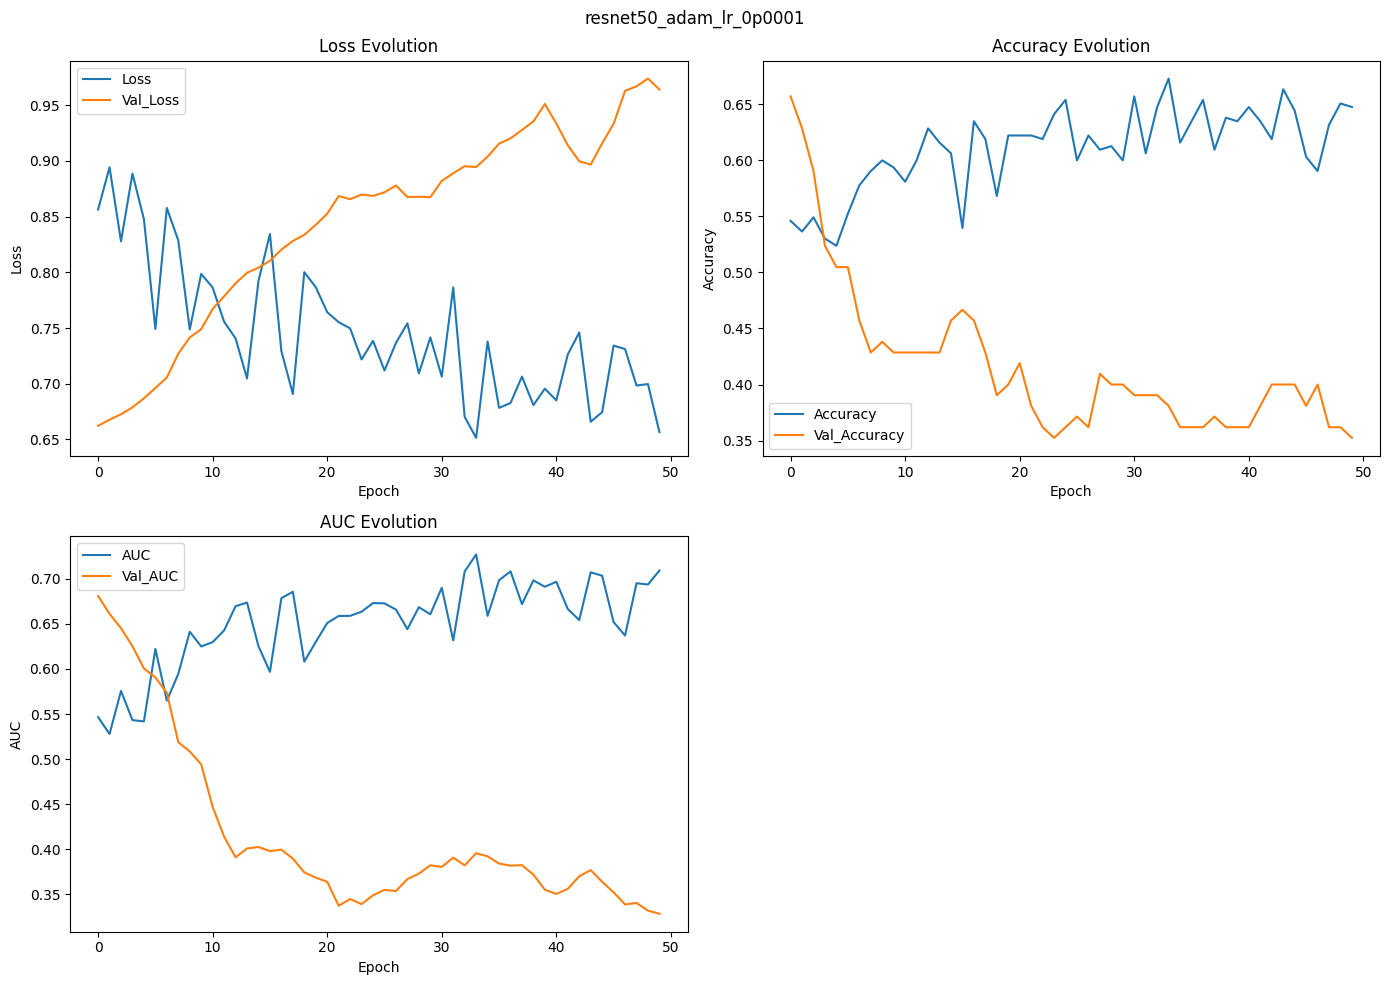

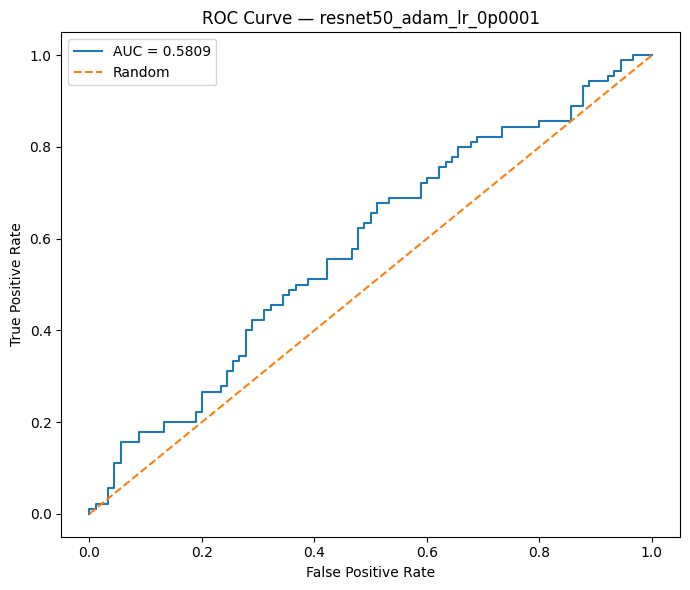

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,42,48
Actual With Disease,29,61


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adam,0.0001,0.572222,0.559633,0.677778,0.466667,0.613065,0.580864,42,48,29,61,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\reports\resnet50_adam_lr_0p00...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.591549,0.466667,0.521739,90.000000
With Disease,0.559633,0.677778,0.613065,90.000000
accuracy,0.572222,0.572222,0.572222,0.572222
macro avg,0.575591,0.572222,0.567402,180.000000
weighted avg,0.575591,0.572222,0.567402,180.000000


Incomplete or missing run, will run: resnet50_adam_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_adam_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_adam_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_adam_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adam_lr_1e-05_confusion_matrix.csv

Running: resnet50_adam_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.4921 - auc: 0.4588 - loss: 1.0773 - precision: 0.4936 - recall: 0.4873 - val_accuracy: 0.4571 - val_auc: 0.4851 - val_loss: 0.7121 - val_precision: 0.4719 - val_recall: 0.8077
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5111 - auc: 0.5201 - loss: 0.9539 - precision: 0.5132 - recall: 0.4937 - val_accuracy: 0.4571 - val_auc: 0.5009 - val_loss: 0.7135 - val_precision: 0.4725 - val_recall: 0.8269
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.4349 - auc: 0.4225 - loss: 1.0940 - precision: 0.4296 - recal

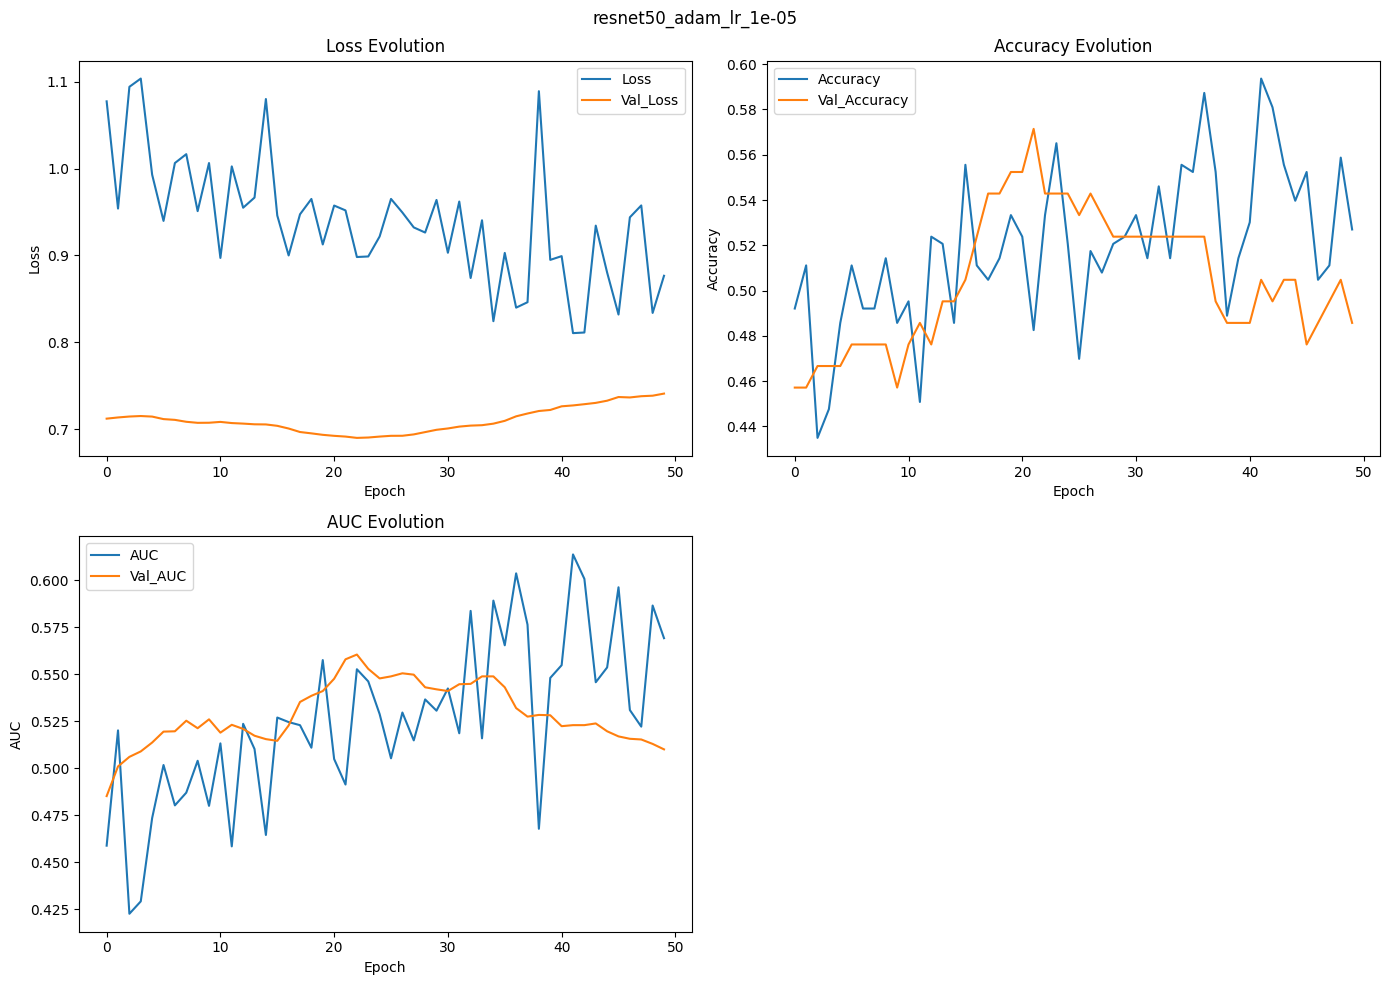

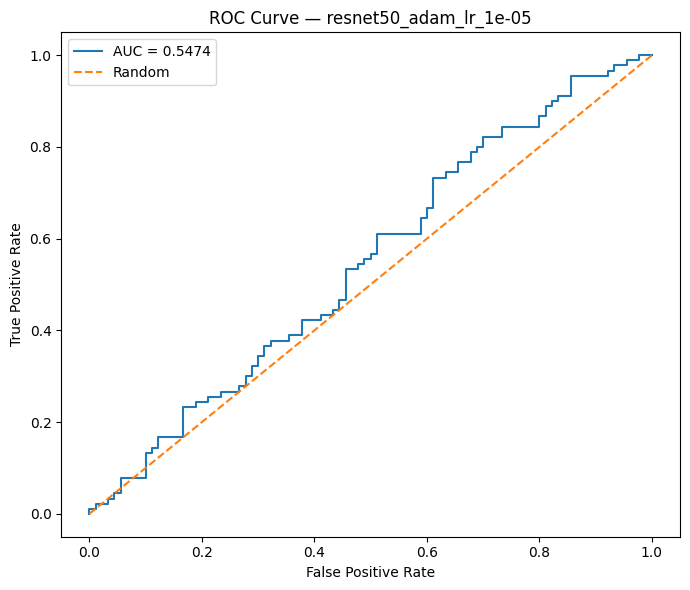

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,52,38
Actual With Disease,51,39


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adam,0.00001,0.505556,0.506494,0.433333,0.577778,0.467066,0.547407,52,38,51,39,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.504854,0.577778,0.538860,90.000000
With Disease,0.506494,0.433333,0.467066,90.000000
accuracy,0.505556,0.505556,0.505556,0.505556
macro avg,0.505674,0.505556,0.502963,180.000000
weighted avg,0.505674,0.505556,0.502963,180.000000


Incomplete or missing run, will run: resnet50_adam_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_adam_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_adam_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_adam_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adam_lr_1e-06_confusion_matrix.csv

Running: resnet50_adam_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4921 - auc: 0.4801 - loss: 0.9325 - precision: 0.4939 - recall: 0.5127 - val_accuracy: 0.5048 - val_auc: 0.5666 - val_loss: 0.6936 - val_precision: 0.5000 - val_recall: 0.0385
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5079 - auc: 0.4913 - loss: 0.9444 - precision: 0.5091 - recall: 0.5316 - val_accuracy: 0.5048 - val_auc: 0.5809 - val_loss: 0.6945 - val_precision: 0.5000 - val_recall: 0.0192
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4730 - auc: 0.4636 - loss: 0.9394 - precision: 0.4750 - recal

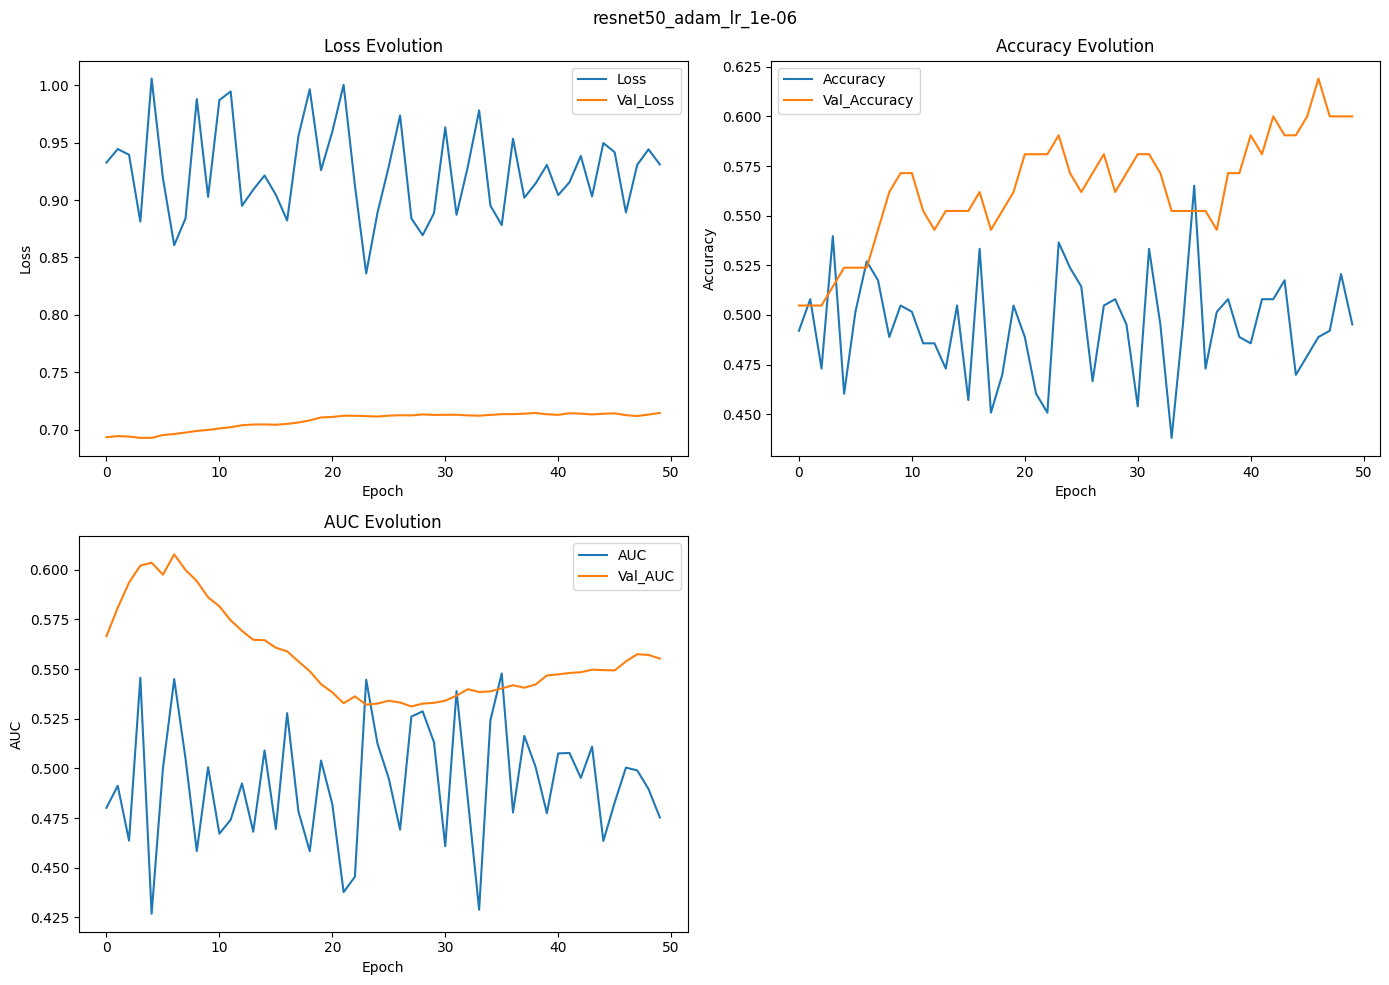

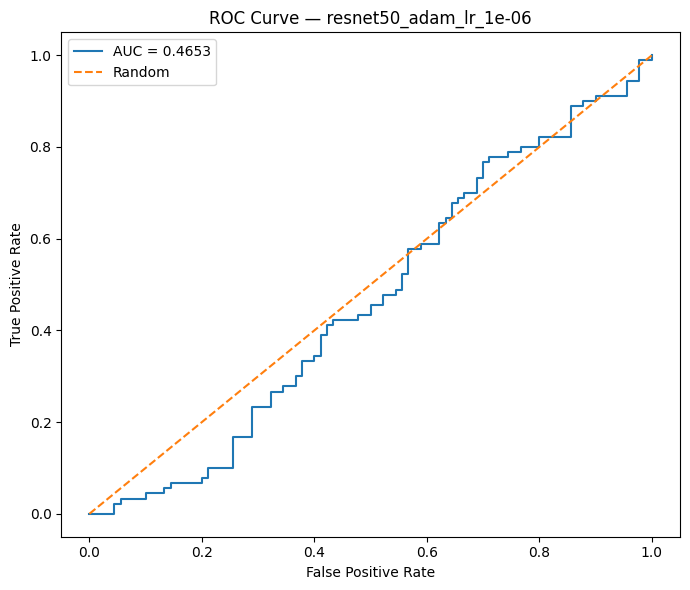

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,23,67
Actual With Disease,20,70


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adam,0.000001,0.516667,0.510949,0.777778,0.255556,0.61674,0.465309,23,67,20,70,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.534884,0.255556,0.345865,90.000000
With Disease,0.510949,0.777778,0.616740,90.000000
accuracy,0.516667,0.516667,0.516667,0.516667
macro avg,0.522916,0.516667,0.481302,180.000000
weighted avg,0.522916,0.516667,0.481302,180.000000


Incomplete or missing run, will run: resnet50_adagrad_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_adagrad_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adagrad_lr_0p0001_confusion_matrix.csv

Running: resnet50_adagrad_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4921 - auc: 0.4876 - loss: 0.9703 - precision: 0.4938 - recall: 0.5063 - val_accuracy: 0.4381 - val_auc: 0.4080 - val_loss: 0.7148 - val_precision: 0.4255 - val_recall: 0.3846
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5746 - auc: 0.5886 - loss: 0.8389 - precision: 0.5741 - recall: 0.5886 - val_accuracy: 0.4286 - val_auc: 0.4165 - val_loss: 0.7148 - val_precision: 0.4375 - val_recall: 0.5385
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5460 - auc: 0.5717 - loss: 0.8500 - p

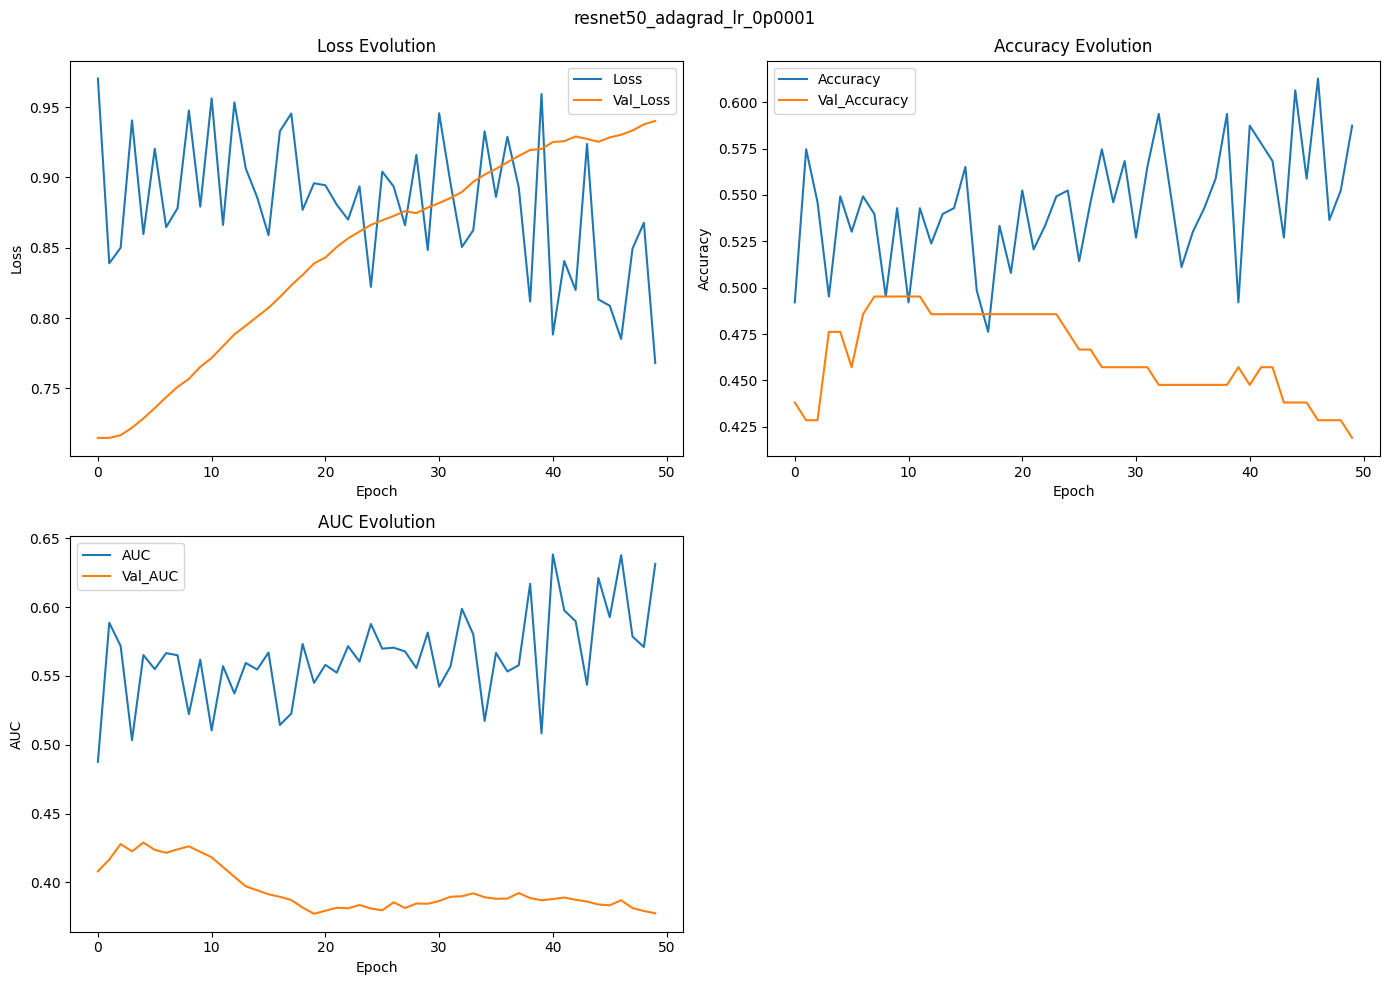

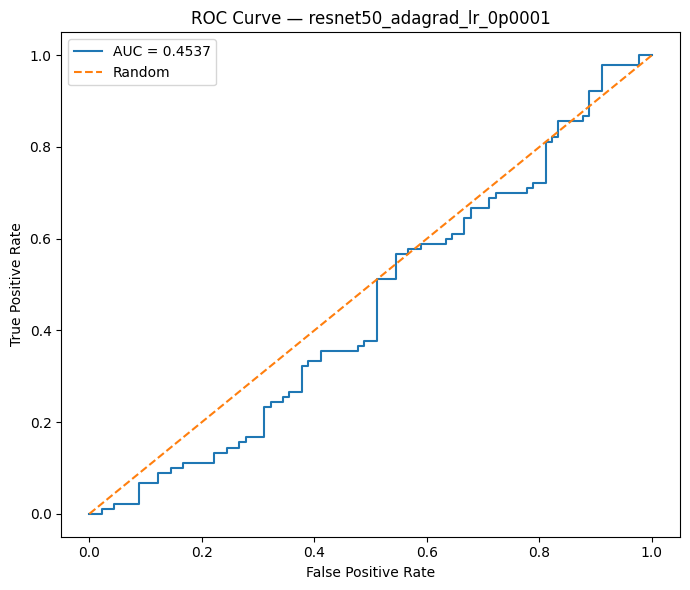

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,67,23
Actual With Disease,77,13


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adagrad,0.0001,0.444444,0.361111,0.144444,0.744444,0.206349,0.453704,67,23,77,13,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\reports\resnet50_adagrad_lr_0...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.465278,0.744444,0.572650,90.000000
With Disease,0.361111,0.144444,0.206349,90.000000
accuracy,0.444444,0.444444,0.444444,0.444444
macro avg,0.413194,0.444444,0.389499,180.000000
weighted avg,0.413194,0.444444,0.389499,180.000000


Incomplete or missing run, will run: resnet50_adagrad_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_adagrad_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adagrad_lr_1e-05_confusion_matrix.csv

Running: resnet50_adagrad_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5111 - auc: 0.5106 - loss: 0.9335 - precision: 0.5123 - recall: 0.5253 - val_accuracy: 0.5143 - val_auc: 0.4331 - val_loss: 0.7137 - val_precision: 0.5556 - val_recall: 0.0962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5175 - auc: 0.5356 - loss: 0.8320 - precision: 0.5190 - recall: 0.5190 - val_accuracy: 0.5333 - val_auc: 0.4563 - val_loss: 0.7091 - val_precision: 0.6154 - val_recall: 0.1538
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5111 - auc: 0.5021 - loss: 0.9183 - precisi

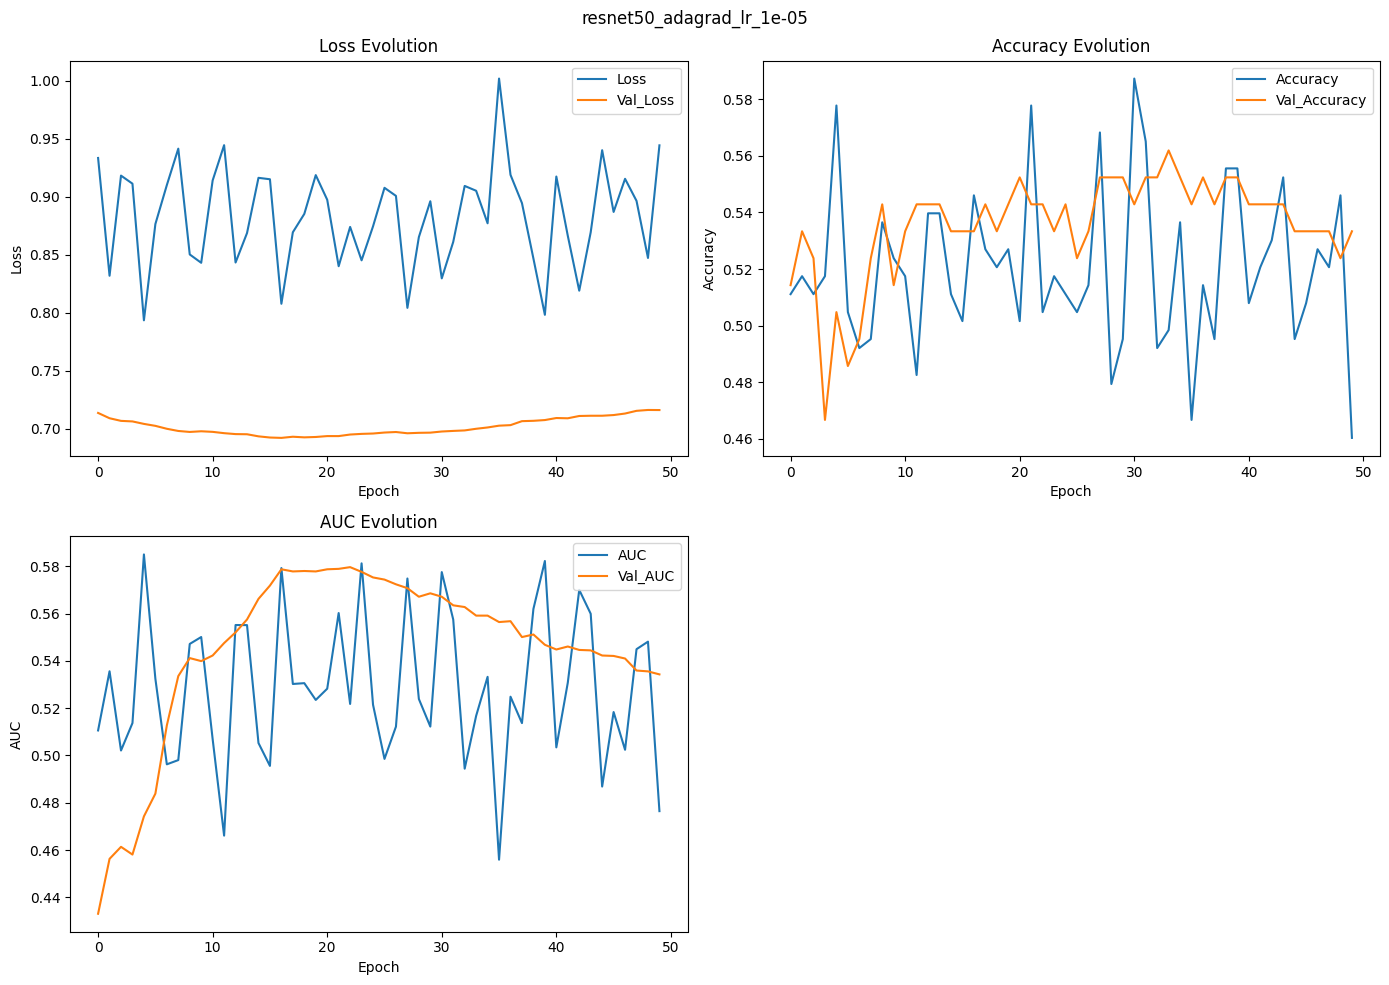

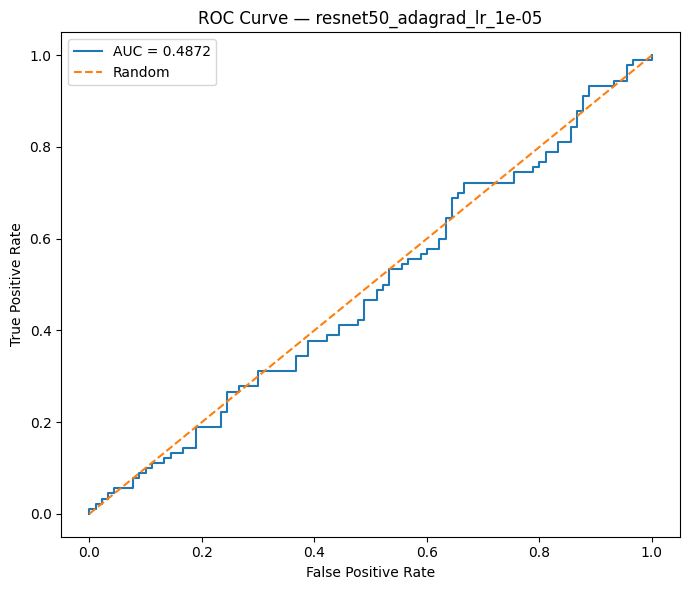

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,42,48
Actual With Disease,45,45


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adagrad,0.00001,0.483333,0.483871,0.5,0.466667,0.491803,0.48716,42,48,45,45,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.482759,0.466667,0.474576,90.000000
With Disease,0.483871,0.500000,0.491803,90.000000
accuracy,0.483333,0.483333,0.483333,0.483333
macro avg,0.483315,0.483333,0.483190,180.000000
weighted avg,0.483315,0.483333,0.483190,180.000000


Incomplete or missing run, will run: resnet50_adagrad_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_adagrad_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_adagrad_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adagrad_lr_1e-06_confusion_matrix.csv

Running: resnet50_adagrad_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5333 - auc: 0.5456 - loss: 0.8646 - precision: 0.5350 - recall: 0.5316 - val_accuracy: 0.6095 - val_auc: 0.6778 - val_loss: 0.6654 - val_precision: 0.7037 - val_recall: 0.3654
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5841 - auc: 0.6071 - loss: 0.8036 - precision: 0.5918 - recall: 0.5506 - val_accuracy: 0.5619 - val_auc: 0.6716 - val_loss: 0.6701 - val_precision: 0.6875 - val_recall: 0.2115
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5365 - auc: 0.5707 - loss: 0.8750 - precisi

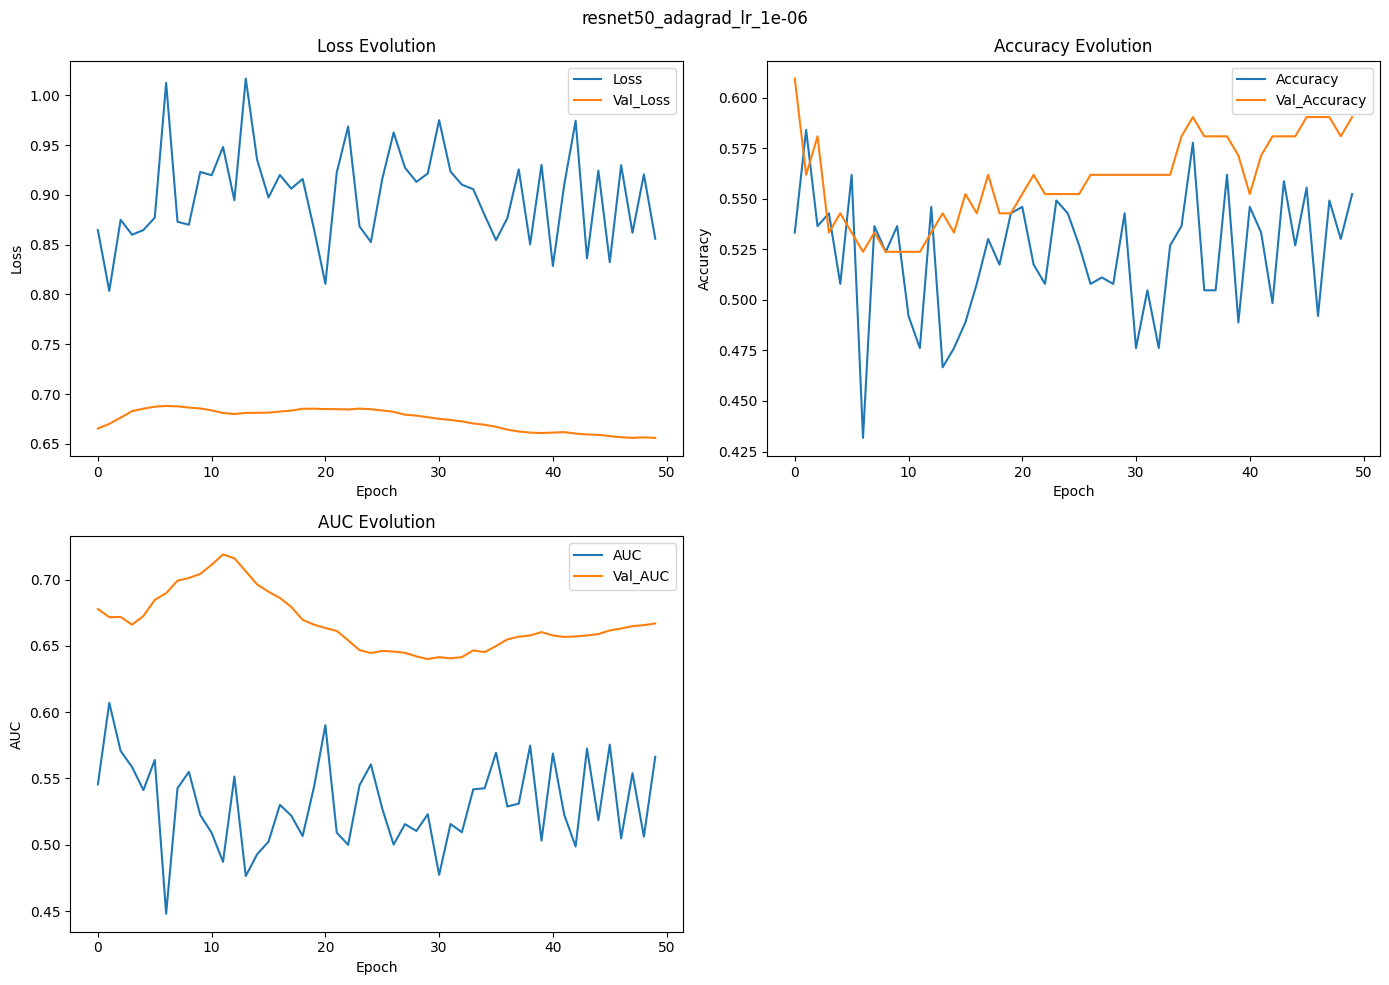

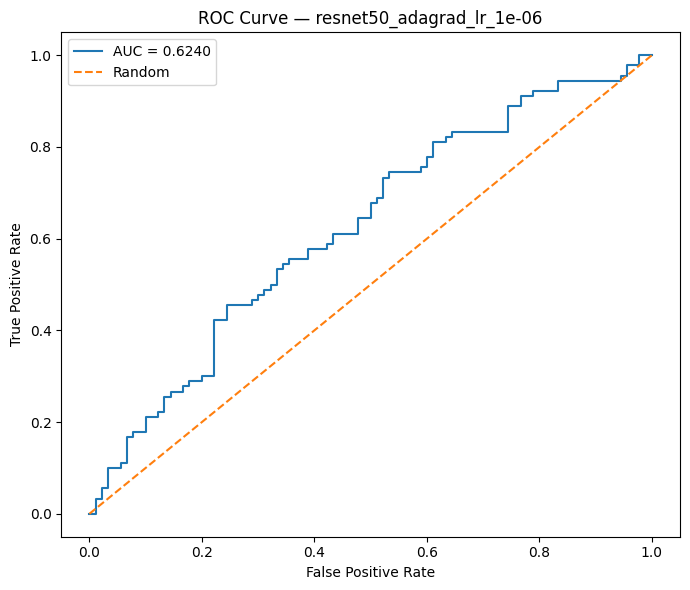

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,23,67
Actual With Disease,13,77


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adagrad,0.000001,0.555556,0.534722,0.855556,0.255556,0.65812,0.623951,23,67,13,77,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.638889,0.255556,0.365079,90.000000
With Disease,0.534722,0.855556,0.658120,90.000000
accuracy,0.555556,0.555556,0.555556,0.555556
macro avg,0.586806,0.555556,0.511600,180.000000
weighted avg,0.586806,0.555556,0.511600,180.000000


Incomplete or missing run, will run: resnet50_adamax_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_adamax_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_adamax_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_adamax_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adamax_lr_0p0001_confusion_matrix.csv

Running: resnet50_adamax_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5048 - auc: 0.4996 - loss: 1.0460 - precision: 0.5062 - recall: 0.5190 - val_accuracy: 0.5143 - val_auc: 0.4898 - val_loss: 0.7087 - val_precision: 0.5102 - val_recall: 0.4808
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5238 - auc: 0.5104 - loss: 1.0068 - precision: 0.5238 - recall: 0.5570 - val_accuracy: 0.4667 - val_auc: 0.4686 - val_loss: 0.7147 - val_precision: 0.4714 - val_recall: 0.6346
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5111 - auc: 0.5111 - loss: 0.9871 - precisi

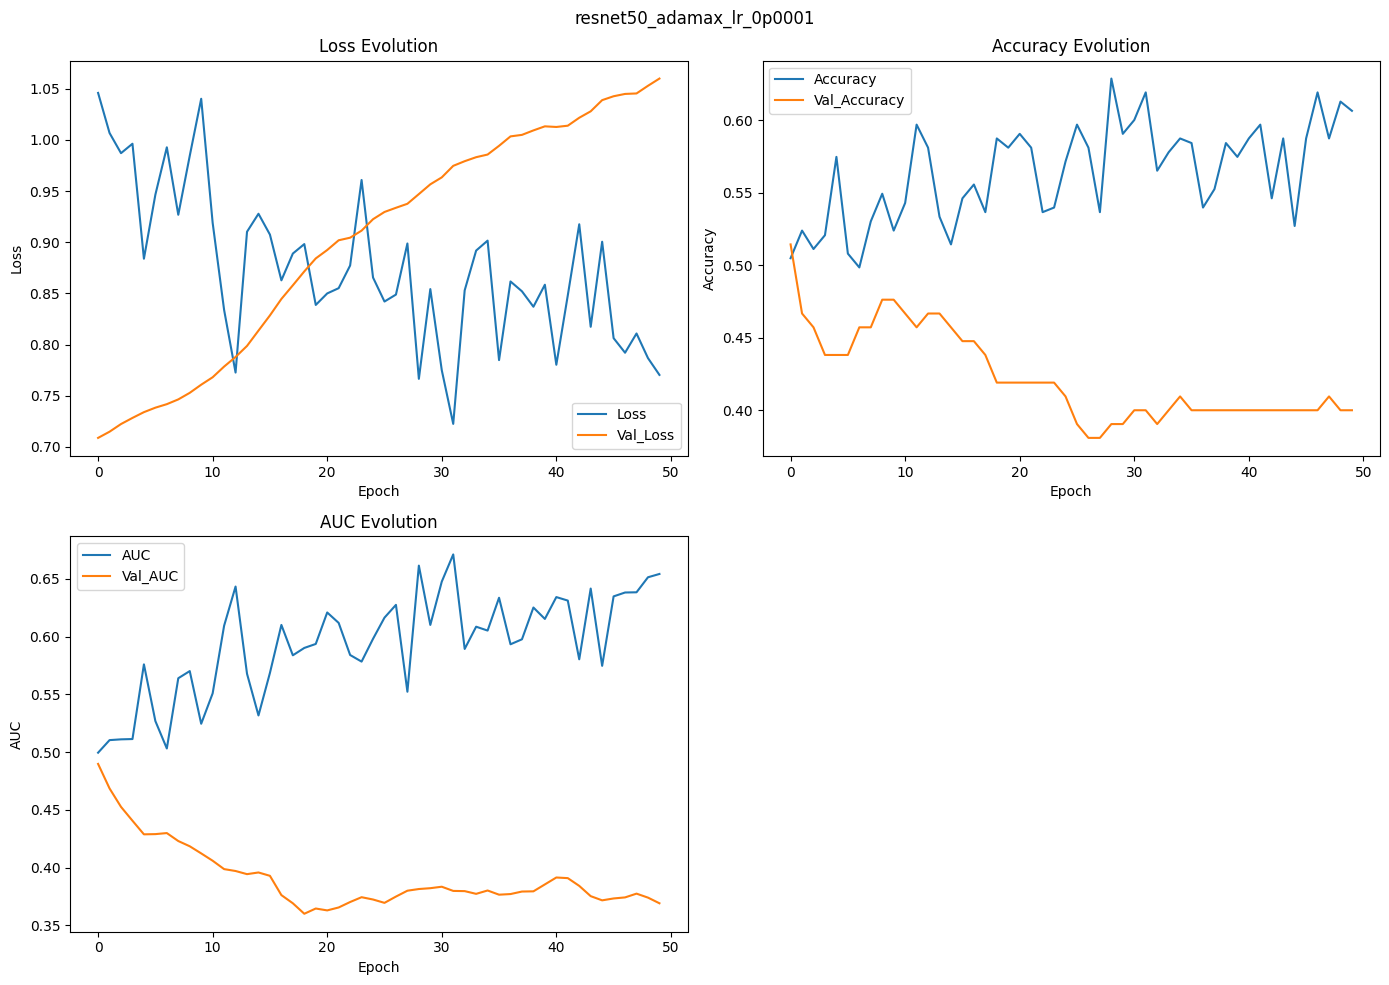

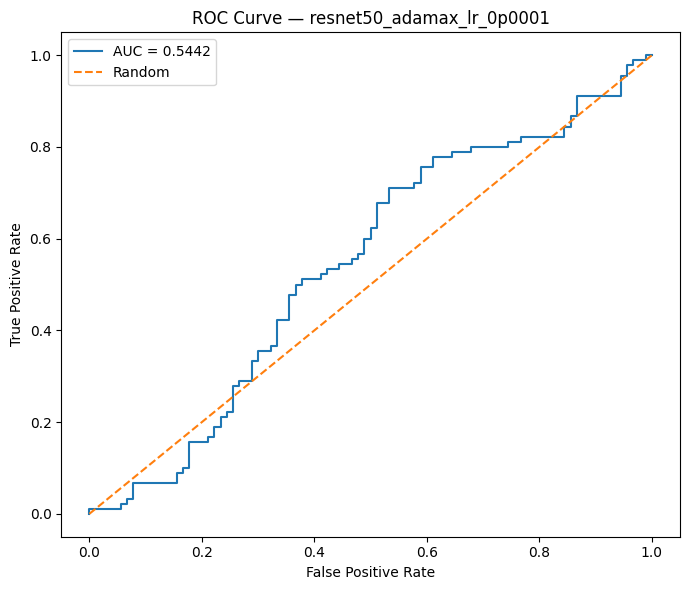

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,67,23
Actual With Disease,67,23


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adamax,0.0001,0.5,0.5,0.255556,0.744444,0.338235,0.544198,67,23,67,23,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\reports\resnet50_adamax_lr_0p...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.5,0.744444,0.598214,90.0
With Disease,0.5,0.255556,0.338235,90.0
accuracy,0.5,0.500000,0.500000,0.5
macro avg,0.5,0.500000,0.468225,180.0
weighted avg,0.5,0.500000,0.468225,180.0


Incomplete or missing run, will run: resnet50_adamax_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_adamax_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_adamax_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_adamax_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adamax_lr_1e-05_confusion_matrix.csv

Running: resnet50_adamax_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5492 - auc: 0.5745 - loss: 0.8509 - precision: 0.5500 - recall: 0.5570 - val_accuracy: 0.4857 - val_auc: 0.4358 - val_loss: 0.7024 - val_precision: 0.4821 - val_recall: 0.5192
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5206 - auc: 0.5416 - loss: 0.9450 - precision: 0.5215 - recall: 0.5380 - val_accuracy: 0.4762 - val_auc: 0.4526 - val_loss: 0.7019 - val_precision: 0.4762 - val_recall: 0.5769
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4952 - auc: 0.5137 - loss: 1.0063 - precision: 0.

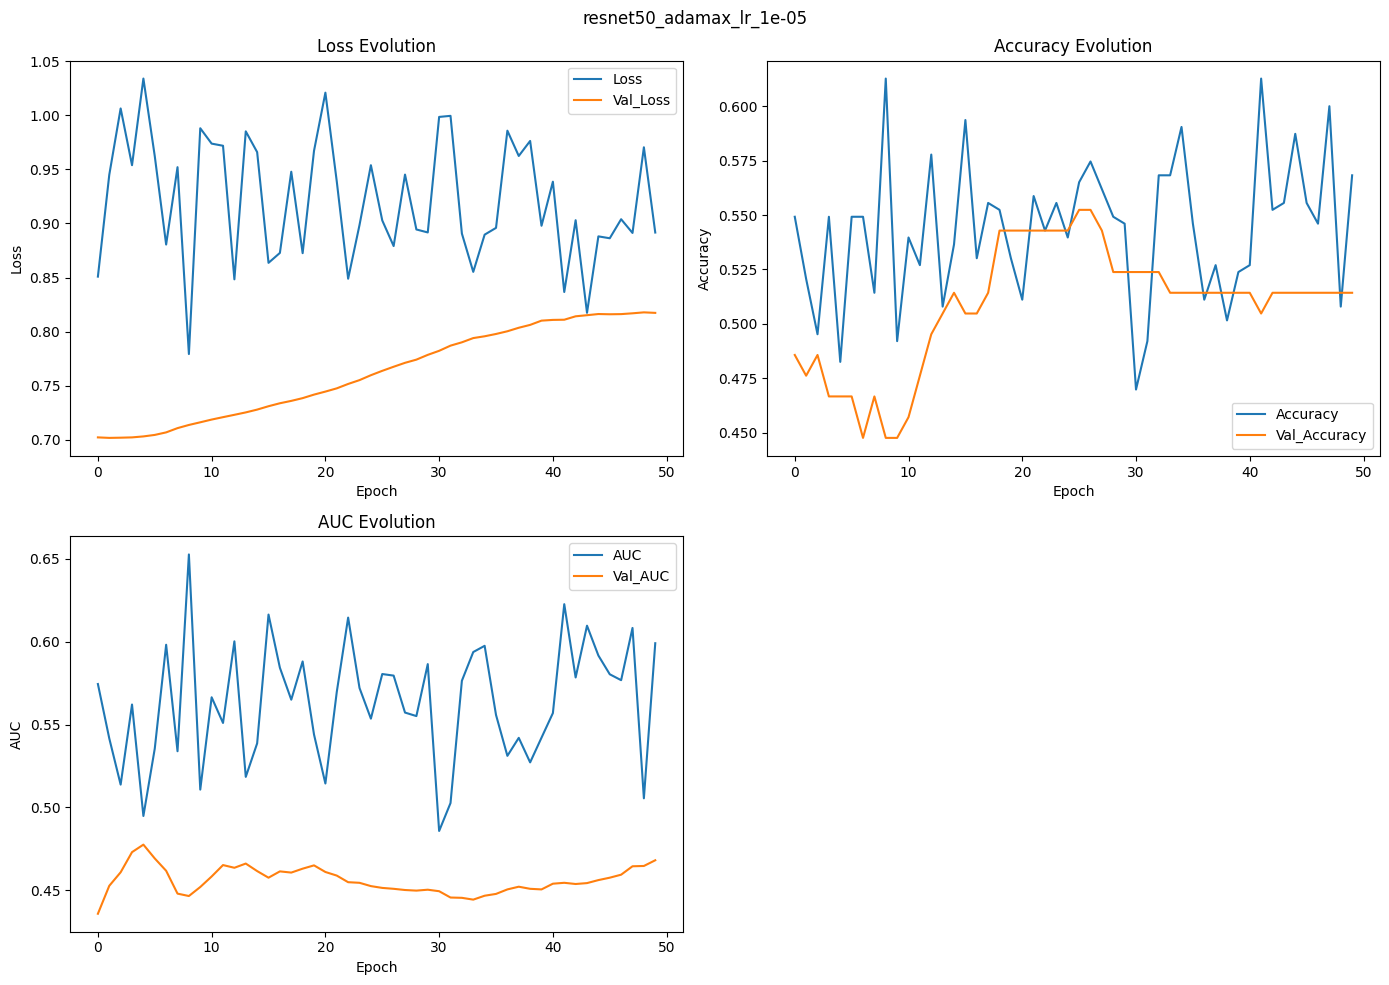

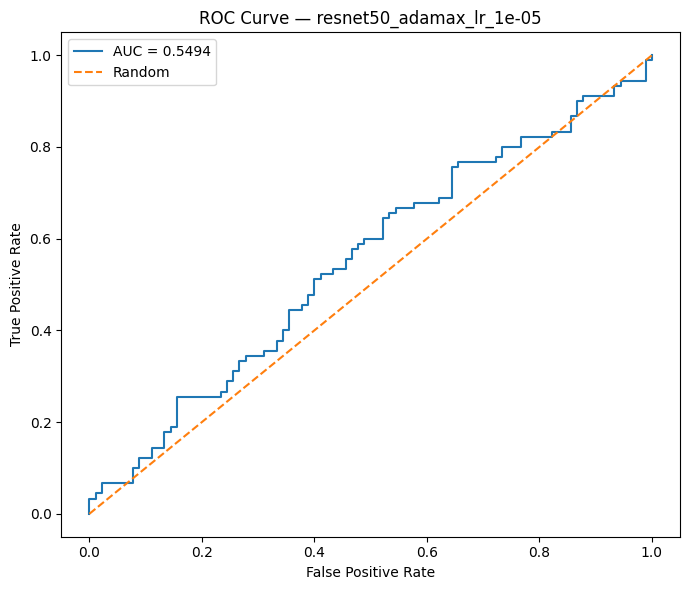

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,38,52
Actual With Disease,29,61


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adamax,0.00001,0.55,0.539823,0.677778,0.422222,0.600985,0.549383,38,52,29,61,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.567164,0.422222,0.484076,90.00
With Disease,0.539823,0.677778,0.600985,90.00
accuracy,0.550000,0.550000,0.550000,0.55
macro avg,0.553494,0.550000,0.542531,180.00
weighted avg,0.553494,0.550000,0.542531,180.00


Incomplete or missing run, will run: resnet50_adamax_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_adamax_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_adamax_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_adamax_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adamax_lr_1e-06_confusion_matrix.csv

Running: resnet50_adamax_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4857 - auc: 0.4791 - loss: 1.0117 - precision: 0.4882 - recall: 0.5253 - val_accuracy: 0.5238 - val_auc: 0.5122 - val_loss: 0.7038 - val_precision: 1.0000 - val_recall: 0.0385
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4413 - auc: 0.4279 - loss: 1.0575 - precision: 0.4444 - recall: 0.4557 - val_accuracy: 0.5810 - val_auc: 0.5679 - val_loss: 0.6899 - val_precision: 0.8333 - val_recall: 0.1923
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4794 - auc: 0.4823 - loss: 0.9823 - precision: 0.

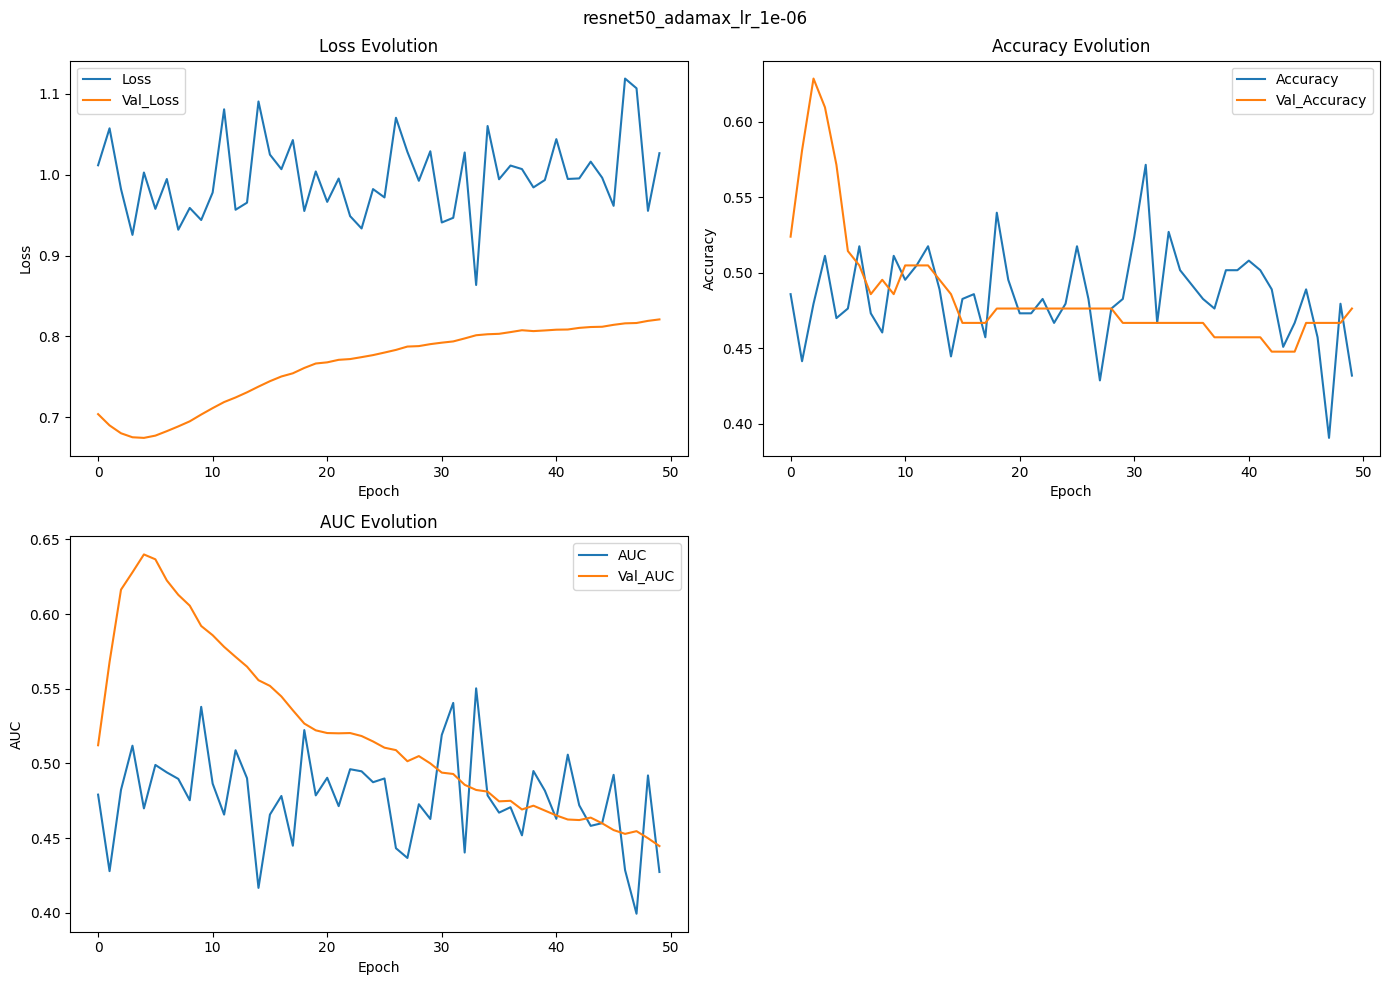

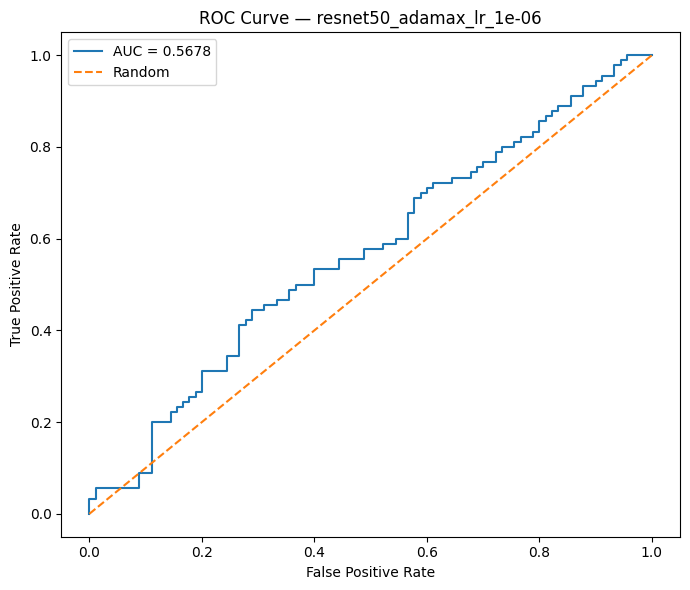

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,74,16
Actual With Disease,68,22


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adamax,0.000001,0.533333,0.578947,0.244444,0.822222,0.34375,0.567778,74,16,68,22,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.521127,0.822222,0.637931,90.000000
With Disease,0.578947,0.244444,0.343750,90.000000
accuracy,0.533333,0.533333,0.533333,0.533333
macro avg,0.550037,0.533333,0.490841,180.000000
weighted avg,0.550037,0.533333,0.490841,180.000000


Incomplete or missing run, will run: resnet50_adadelta_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_adadelta_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adadelta_lr_0p0001_confusion_matrix.csv

Running: resnet50_adadelta_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 38s 3s/step - accuracy: 0.5143 - auc: 0.5181 - loss: 0.9459 - precision: 0.5168 - recall: 0.4873 - val_accuracy: 0.4857 - val_auc: 0.5655 - val_loss: 0.7220 - val_precision: 0.4904 - val_recall: 0.9808
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5365 - auc: 0.5347 - loss: 0.9193 - precision: 0.5380 - recall: 0.5380 - val_accuracy: 0.4857 - val_auc: 0.5363 - val_loss: 0.7260 - val_precision: 0.4904 - val_recall: 0.9808
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5143 - auc: 0.5182 - loss: 0.93

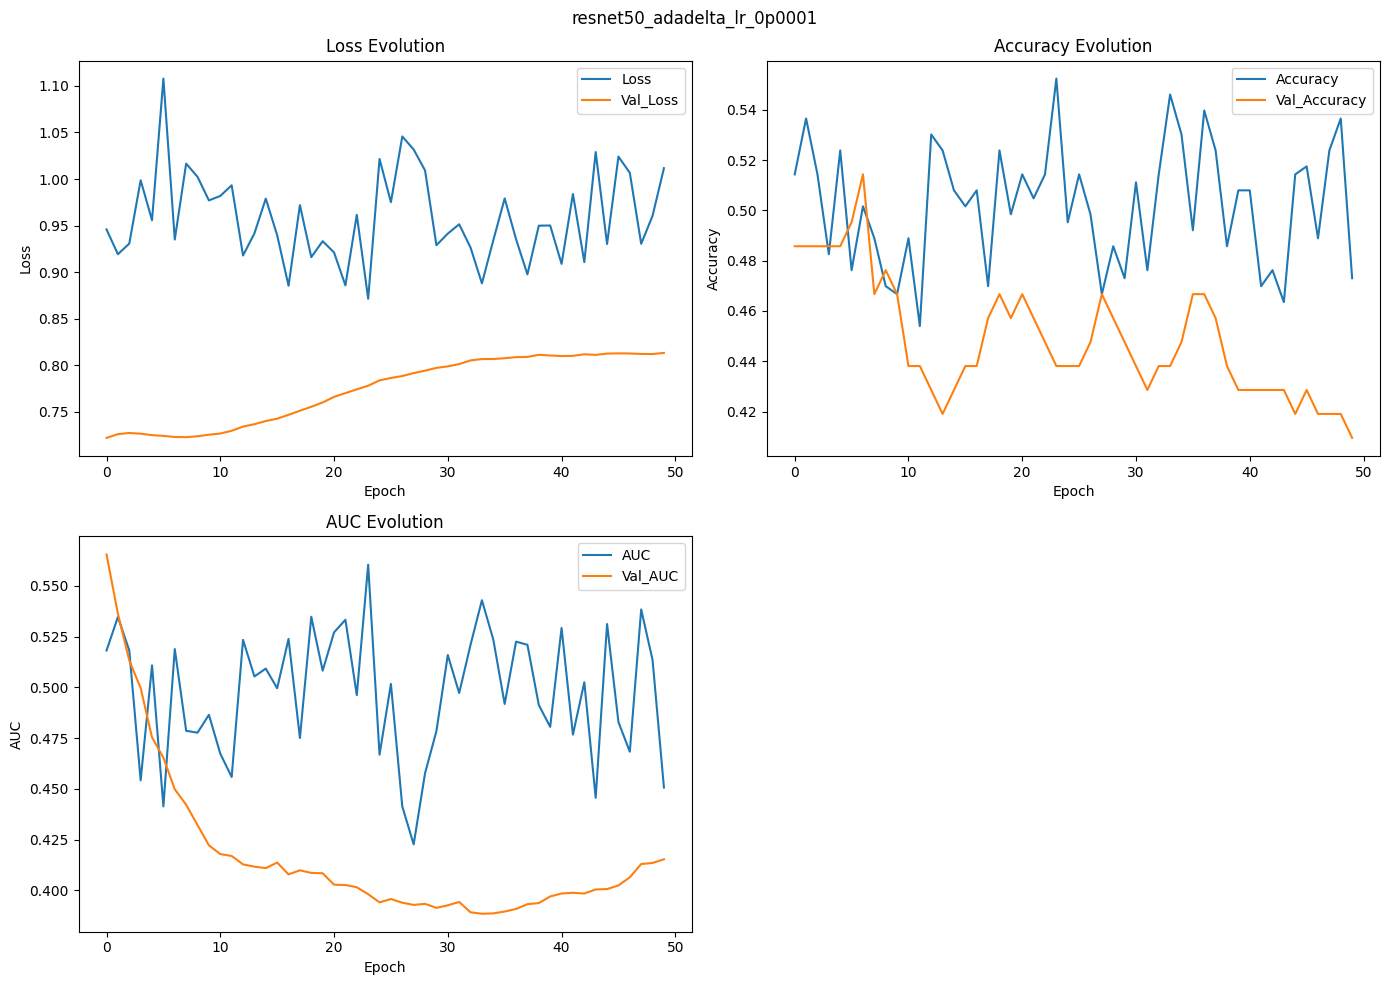

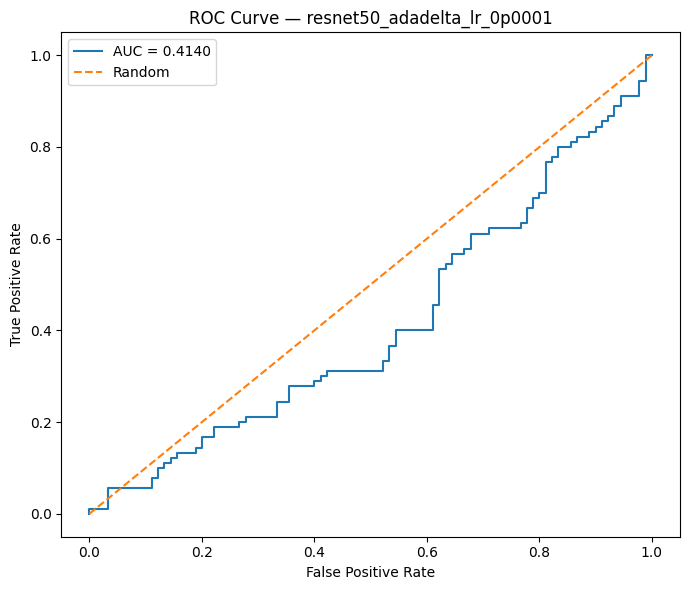

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,31,59
Actual With Disease,39,51


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adadelta,0.0001,0.455556,0.463636,0.566667,0.344444,0.51,0.413951,31,59,39,51,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\reports\resnet50_adadelta_lr_...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.442857,0.344444,0.387500,90.000000
With Disease,0.463636,0.566667,0.510000,90.000000
accuracy,0.455556,0.455556,0.455556,0.455556
macro avg,0.453247,0.455556,0.448750,180.000000
weighted avg,0.453247,0.455556,0.448750,180.000000


Incomplete or missing run, will run: resnet50_adadelta_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_adadelta_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adadelta_lr_1e-05_confusion_matrix.csv

Running: resnet50_adadelta_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.5397 - auc: 0.5330 - loss: 0.9177 - precision: 0.5442 - recall: 0.5063 - val_accuracy: 0.4952 - val_auc: 0.3173 - val_loss: 0.9800 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5016 - auc: 0.4971 - loss: 0.9661 - precision: 0.5031 - recall: 0.5063 - val_accuracy: 0.4952 - val_auc: 0.3200 - val_loss: 0.9252 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5175 - auc: 0.5098 - loss: 0.9514 - p

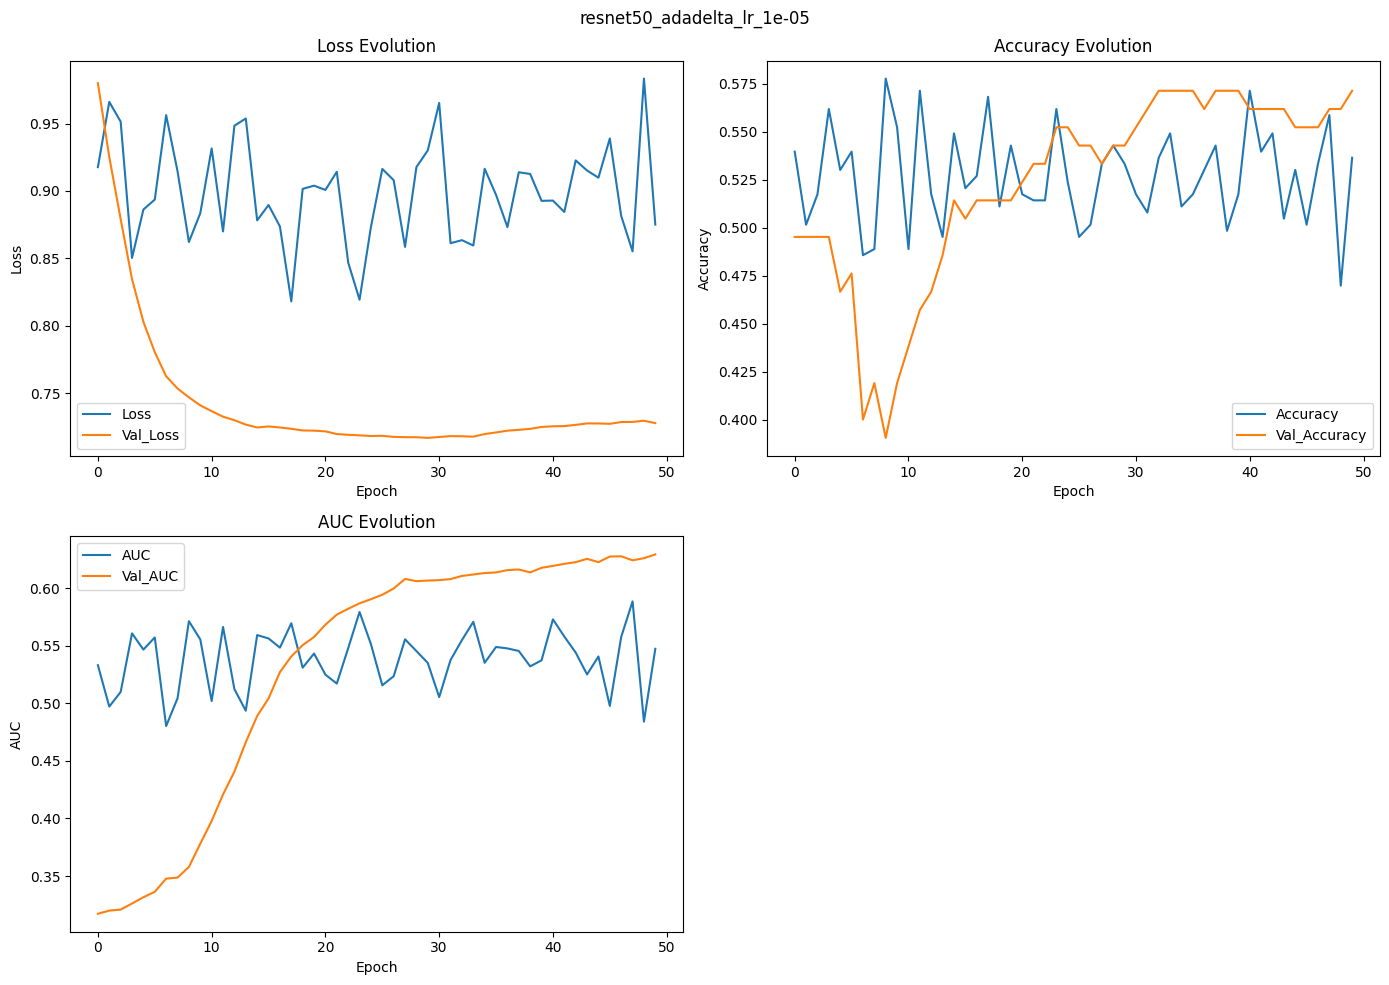

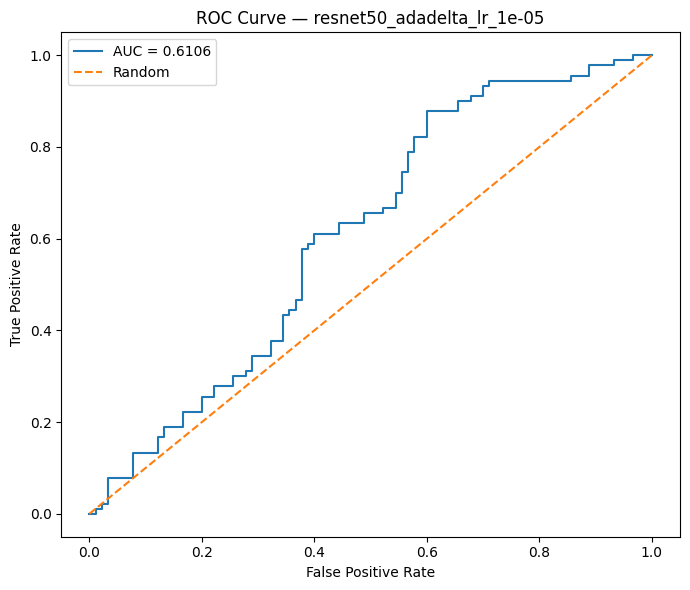

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,36,54
Actual With Disease,11,79


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adadelta,0.00001,0.638889,0.593985,0.877778,0.4,0.70852,0.610617,36,54,11,79,outputs_resnet50\plots\resnet50_adadelta_lr_1e...,outputs_resnet50\plots\resnet50_adadelta_lr_1e...,outputs_resnet50\reports\resnet50_adadelta_lr_...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.765957,0.400000,0.525547,90.000000
With Disease,0.593985,0.877778,0.708520,90.000000
accuracy,0.638889,0.638889,0.638889,0.638889
macro avg,0.679971,0.638889,0.617034,180.000000
weighted avg,0.679971,0.638889,0.617034,180.000000


Incomplete or missing run, will run: resnet50_adadelta_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_adadelta_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_adadelta_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_adadelta_lr_1e-06_confusion_matrix.csv

Running: resnet50_adadelta_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.3968 - auc: 0.3941 - loss: 1.1087 - precision: 0.4024 - recall: 0.4177 - val_accuracy: 0.5048 - val_auc: 0.4218 - val_loss: 0.7251 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4921 - auc: 0.4841 - loss: 1.0071 - precision: 0.4935 - recall: 0.4810 - val_accuracy: 0.5143 - val_auc: 0.4445 - val_loss: 0.7195 - val_precision: 1.0000 - val_recall: 0.0192
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5016 - auc: 0.4940 - loss: 1.

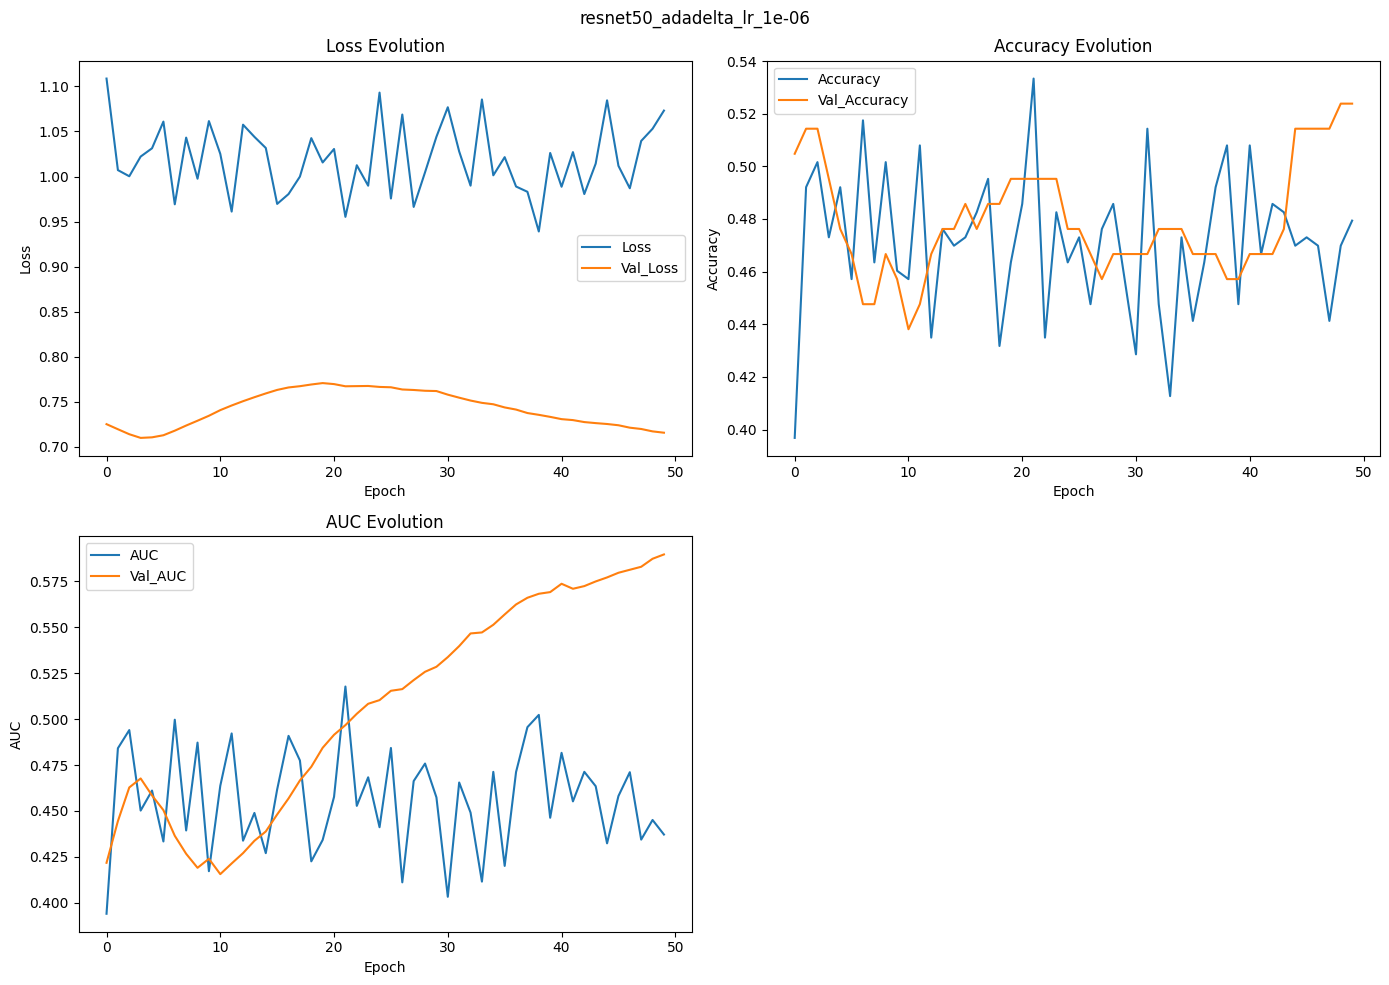

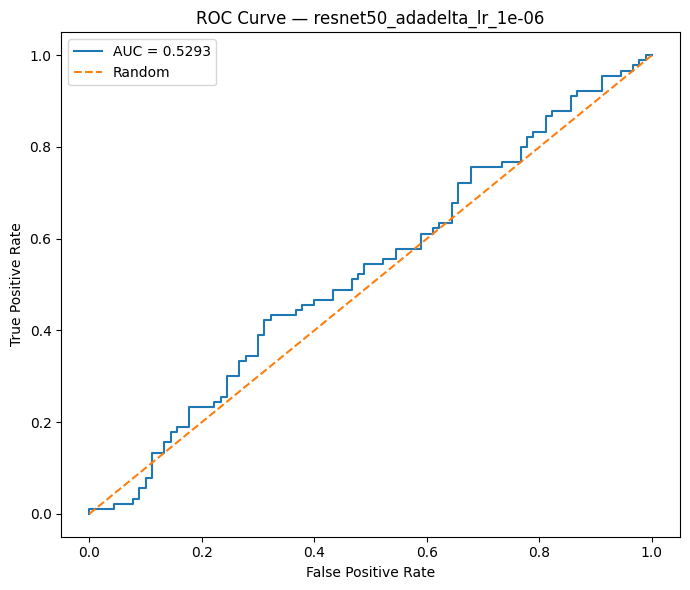

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,68,22
Actual With Disease,66,24


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adadelta,0.000001,0.511111,0.521739,0.266667,0.755556,0.352941,0.529259,68,22,66,24,outputs_resnet50\plots\resnet50_adadelta_lr_1e...,outputs_resnet50\plots\resnet50_adadelta_lr_1e...,outputs_resnet50\reports\resnet50_adadelta_lr_...,outputs_resnet50\confusion_matrices\resnet50_a...


,precision,recall,f1-score,support
Without Disease,0.507463,0.755556,0.607143,90.000000
With Disease,0.521739,0.266667,0.352941,90.000000
accuracy,0.511111,0.511111,0.511111,0.511111
macro avg,0.514601,0.511111,0.480042,180.000000
weighted avg,0.514601,0.511111,0.480042,180.000000


Incomplete or missing run, will run: resnet50_sgd_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_sgd_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_sgd_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_sgd_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_sgd_lr_0p0001_confusion_matrix.csv

Running: resnet50_sgd_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4476 - auc: 0.4712 - loss: 0.9922 - precision: 0.4487 - recall: 0.4430 - val_accuracy: 0.6000 - val_auc: 0.6466 - val_loss: 0.6652 - val_precision: 0.6000 - val_recall: 0.5769
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4857 - auc: 0.5089 - loss: 0.9828 - precision: 0.4868 - recall: 0.4684 - val_accuracy: 0.5619 - val_auc: 0.6529 - val_loss: 0.6647 - val_precision: 0.5682 - val_recall: 0.4808
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5079 - auc: 0.5111 - loss: 0.9555 - precision: 0.5101 - recal

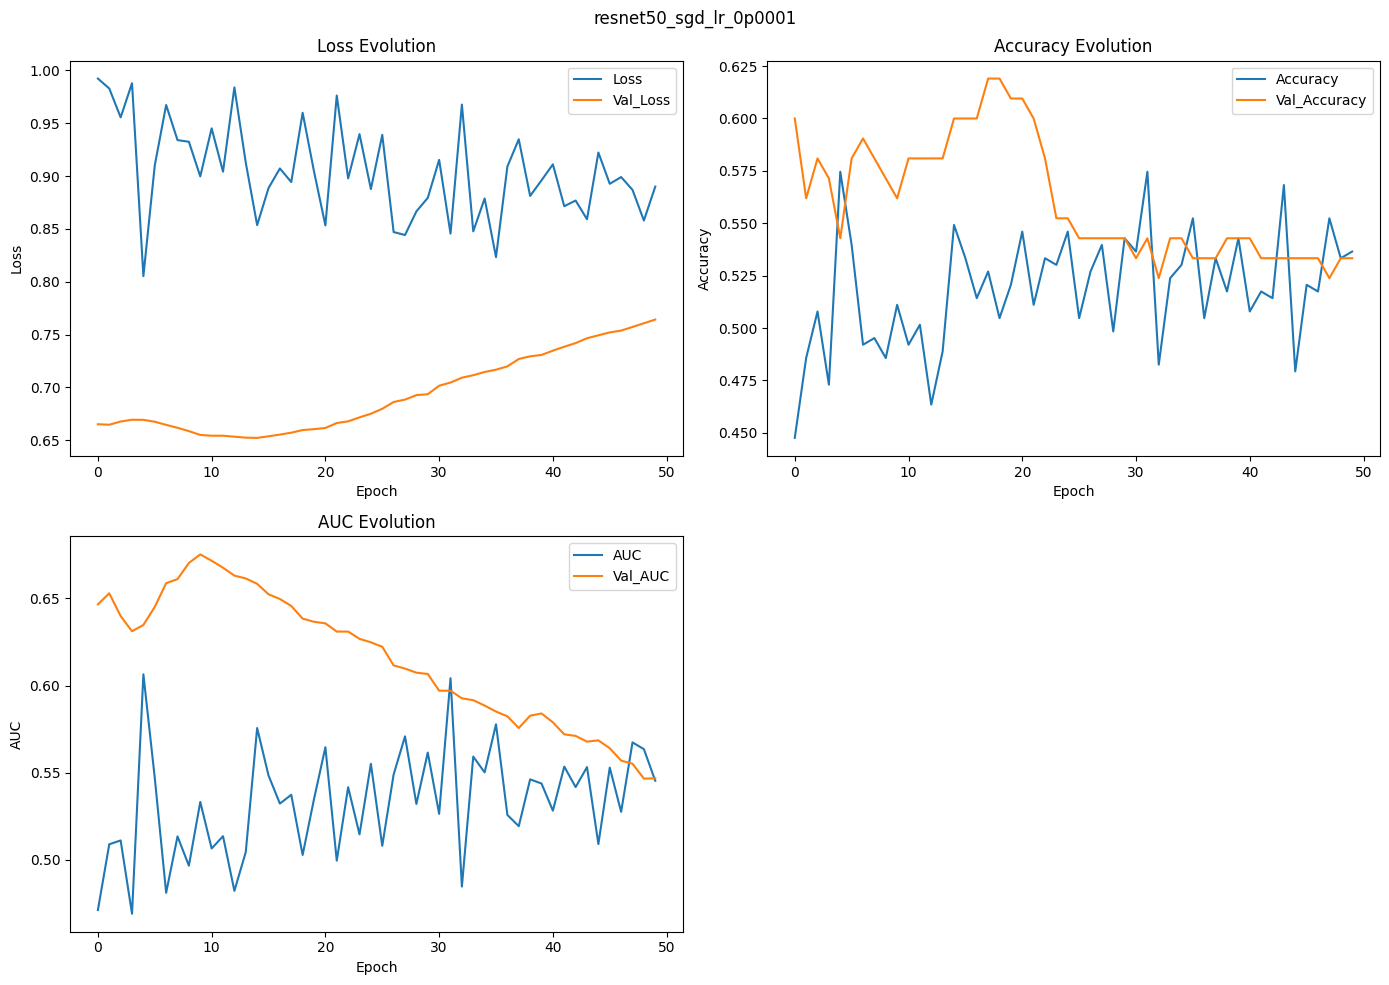

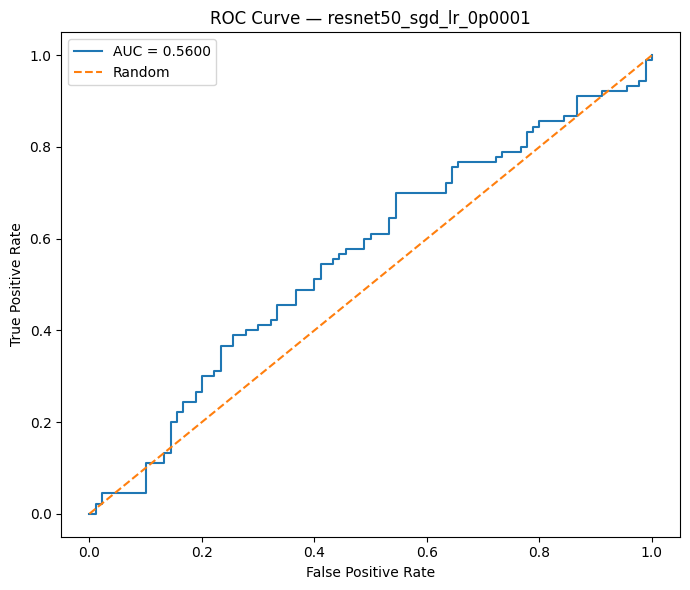

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,63,27
Actual With Disease,53,37


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,sgd,0.0001,0.555556,0.578125,0.411111,0.7,0.480519,0.56,63,27,53,37,outputs_resnet50\plots\resnet50_sgd_lr_0p0001_...,outputs_resnet50\plots\resnet50_sgd_lr_0p0001_...,outputs_resnet50\reports\resnet50_sgd_lr_0p000...,outputs_resnet50\confusion_matrices\resnet50_s...


,precision,recall,f1-score,support
Without Disease,0.543103,0.700000,0.611650,90.000000
With Disease,0.578125,0.411111,0.480519,90.000000
accuracy,0.555556,0.555556,0.555556,0.555556
macro avg,0.560614,0.555556,0.546085,180.000000
weighted avg,0.560614,0.555556,0.546085,180.000000


Incomplete or missing run, will run: resnet50_sgd_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_sgd_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_sgd_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_sgd_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_sgd_lr_1e-05_confusion_matrix.csv

Running: resnet50_sgd_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4889 - auc: 0.4822 - loss: 0.9379 - precision: 0.4907 - recall: 0.5000 - val_accuracy: 0.5048 - val_auc: 0.4441 - val_loss: 0.7440 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5048 - auc: 0.5124 - loss: 0.8995 - precision: 0.5057 - recall: 0.5633 - val_accuracy: 0.4857 - val_auc: 0.4579 - val_loss: 0.7216 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4698 - auc: 0.4890 - loss: 0.9266 - precision: 0.47

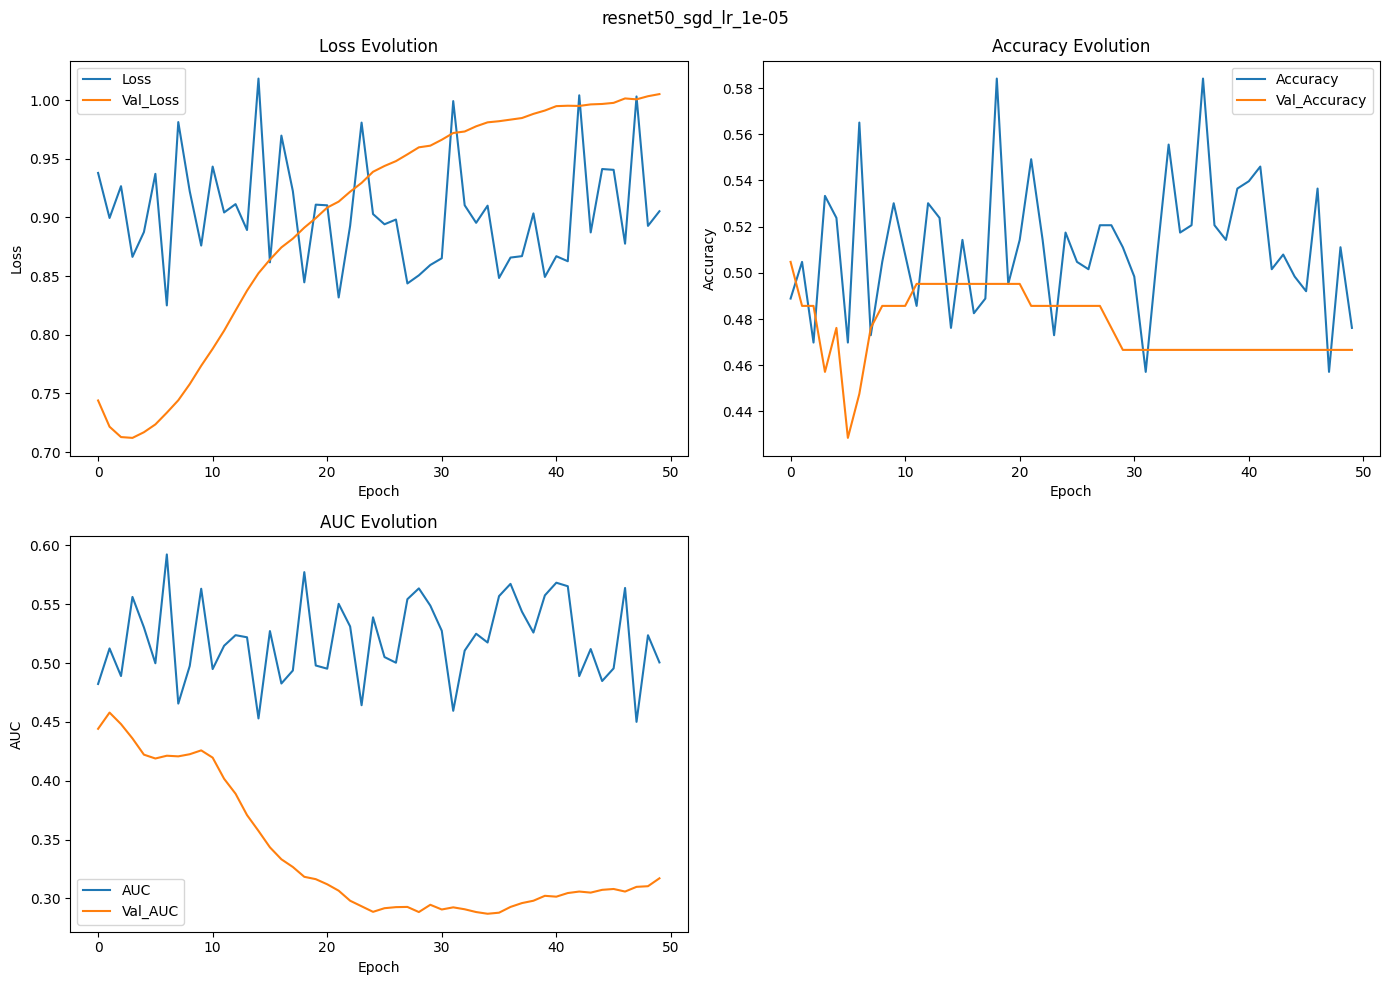

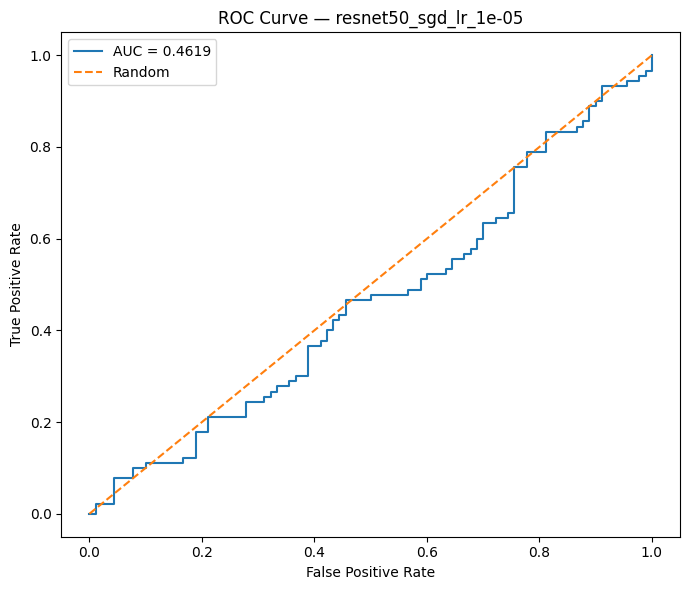

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,86,4
Actual With Disease,83,7


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,sgd,0.00001,0.516667,0.636364,0.077778,0.955556,0.138614,0.461852,86,4,83,7,outputs_resnet50\plots\resnet50_sgd_lr_1e-05_h...,outputs_resnet50\plots\resnet50_sgd_lr_1e-05_r...,outputs_resnet50\reports\resnet50_sgd_lr_1e-05...,outputs_resnet50\confusion_matrices\resnet50_s...


,precision,recall,f1-score,support
Without Disease,0.508876,0.955556,0.664093,90.000000
With Disease,0.636364,0.077778,0.138614,90.000000
accuracy,0.516667,0.516667,0.516667,0.516667
macro avg,0.572620,0.516667,0.401353,180.000000
weighted avg,0.572620,0.516667,0.401353,180.000000


Incomplete or missing run, will run: resnet50_sgd_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_sgd_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_sgd_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_sgd_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_sgd_lr_1e-06_confusion_matrix.csv

Running: resnet50_sgd_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.5429 - auc: 0.5212 - loss: 0.9787 - precision: 0.5422 - recall: 0.5696 - val_accuracy: 0.4952 - val_auc: 0.4833 - val_loss: 0.9124 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5302 - auc: 0.5306 - loss: 0.9536 - precision: 0.5316 - recall: 0.5316 - val_accuracy: 0.4952 - val_auc: 0.4806 - val_loss: 0.8651 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5048 - auc: 0.5067 - loss: 0.9686 - precision: 0.5065 - recall: 0.4

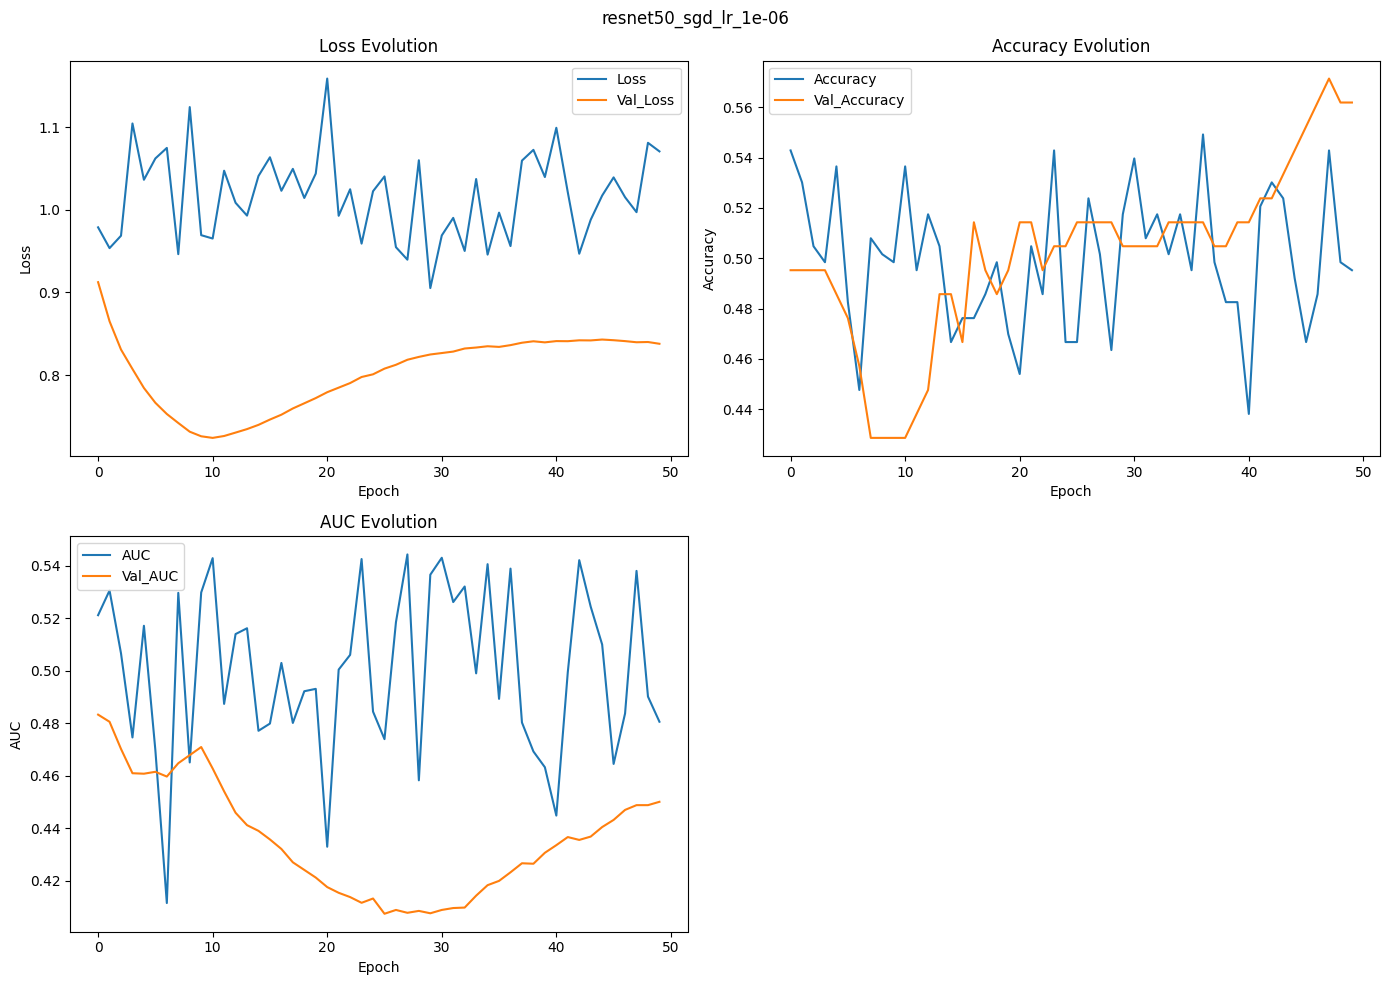

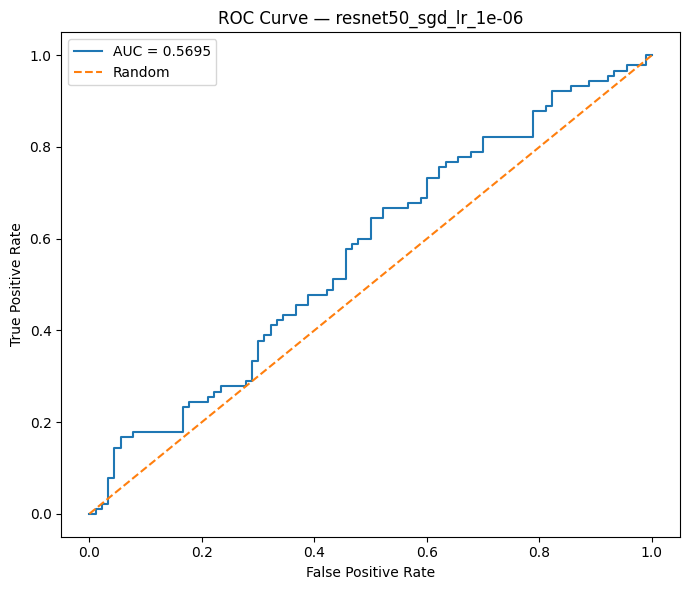

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,19,71
Actual With Disease,15,75


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,sgd,0.000001,0.522222,0.513699,0.833333,0.211111,0.635593,0.569506,19,71,15,75,outputs_resnet50\plots\resnet50_sgd_lr_1e-06_h...,outputs_resnet50\plots\resnet50_sgd_lr_1e-06_r...,outputs_resnet50\reports\resnet50_sgd_lr_1e-06...,outputs_resnet50\confusion_matrices\resnet50_s...


,precision,recall,f1-score,support
Without Disease,0.558824,0.211111,0.306452,90.000000
With Disease,0.513699,0.833333,0.635593,90.000000
accuracy,0.522222,0.522222,0.522222,0.522222
macro avg,0.536261,0.522222,0.471022,180.000000
weighted avg,0.536261,0.522222,0.471022,180.000000


Incomplete or missing run, will run: resnet50_rmsprop_lr_0p0001
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_0p0001_history.png
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_0p0001_roc.png
Missing: outputs_resnet50\reports\resnet50_rmsprop_lr_0p0001_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_rmsprop_lr_0p0001_confusion_matrix.csv

Running: resnet50_rmsprop_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5206 - auc: 0.5244 - loss: 0.9113 - precision: 0.5220 - recall: 0.5253 - val_accuracy: 0.4667 - val_auc: 0.3565 - val_loss: 0.7456 - val_precision: 0.4800 - val_recall: 0.9231
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5365 - auc: 0.5377 - loss: 0.8965 - precision: 0.5349 - recall: 0.5823 - val_accuracy: 0.4000 - val_auc: 0.3639 - val_loss: 0.7448 - val_precision: 0.4396 - val_recall: 0.7692
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5587 - auc: 0.5610 - loss: 0.8876 - p

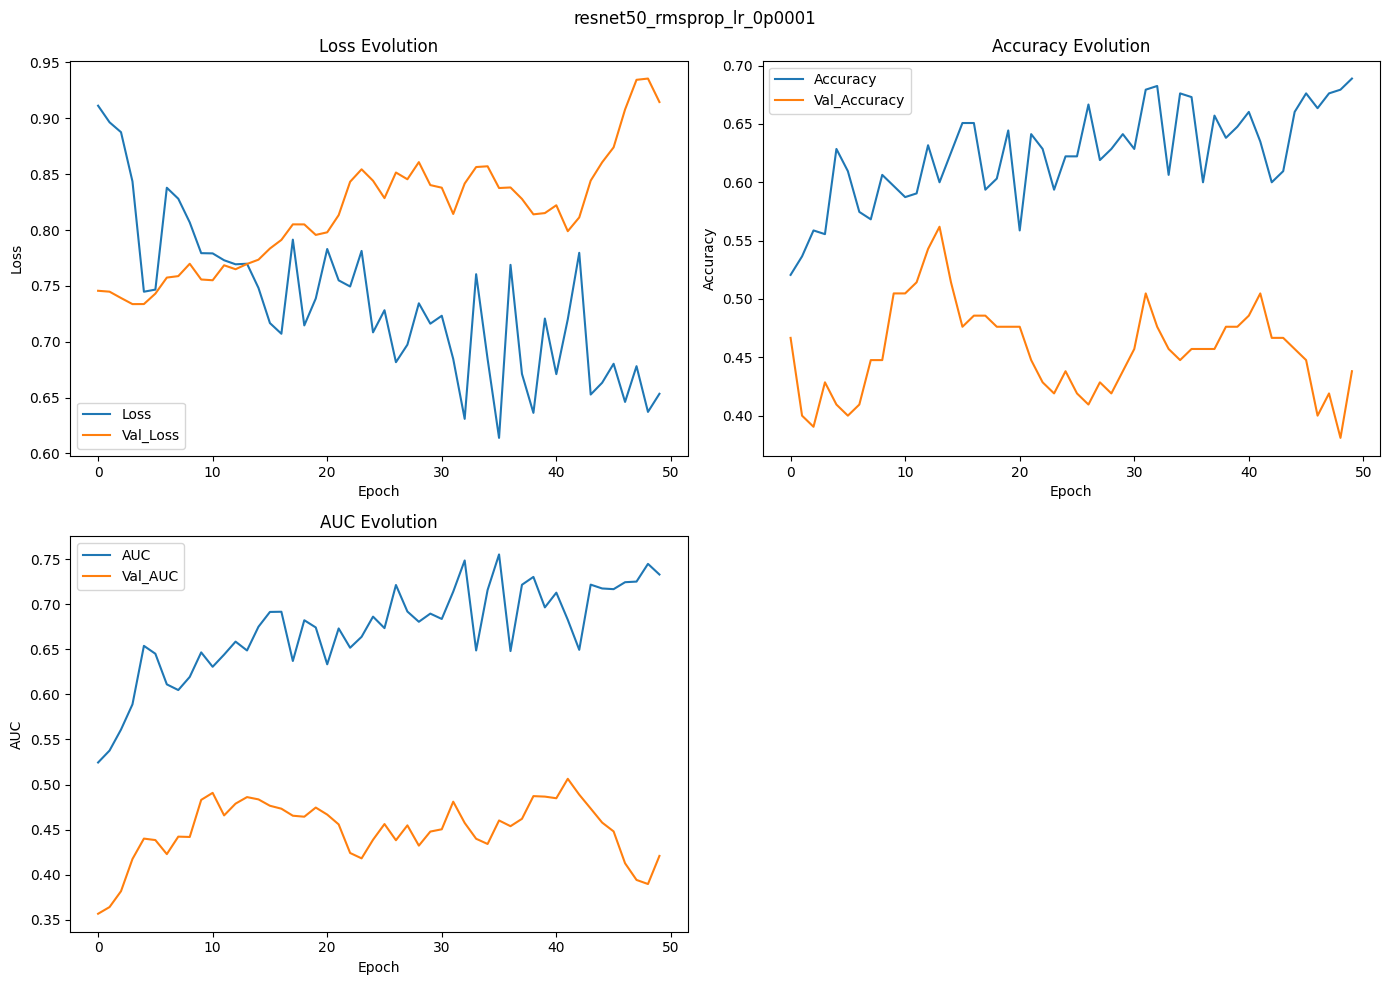

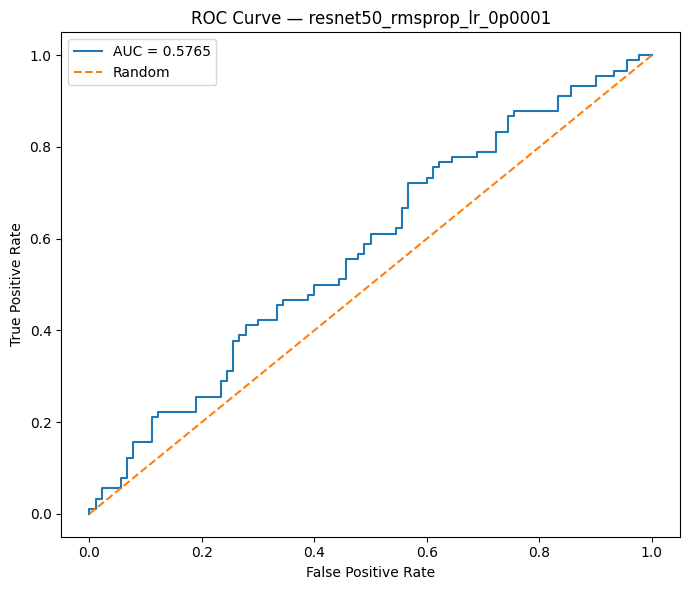

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,39,51
Actual With Disease,29,61


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,rmsprop,0.0001,0.555556,0.544643,0.677778,0.433333,0.60396,0.576543,39,51,29,61,outputs_resnet50\plots\resnet50_rmsprop_lr_0p0...,outputs_resnet50\plots\resnet50_rmsprop_lr_0p0...,outputs_resnet50\reports\resnet50_rmsprop_lr_0...,outputs_resnet50\confusion_matrices\resnet50_r...


,precision,recall,f1-score,support
Without Disease,0.573529,0.433333,0.493671,90.000000
With Disease,0.544643,0.677778,0.603960,90.000000
accuracy,0.555556,0.555556,0.555556,0.555556
macro avg,0.559086,0.555556,0.548816,180.000000
weighted avg,0.559086,0.555556,0.548816,180.000000


Incomplete or missing run, will run: resnet50_rmsprop_lr_1e-05
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_1e-05_history.png
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_1e-05_roc.png
Missing: outputs_resnet50\reports\resnet50_rmsprop_lr_1e-05_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_rmsprop_lr_1e-05_confusion_matrix.csv

Running: resnet50_rmsprop_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4889 - auc: 0.4732 - loss: 1.0142 - precision: 0.4903 - recall: 0.4810 - val_accuracy: 0.5714 - val_auc: 0.5461 - val_loss: 0.6994 - val_precision: 0.5522 - val_recall: 0.7115
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4635 - auc: 0.5006 - loss: 0.9843 - precision: 0.4626 - recall: 0.4304 - val_accuracy: 0.5714 - val_auc: 0.5570 - val_loss: 0.6948 - val_precision: 0.5556 - val_recall: 0.6731
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5111 - auc: 0.5418 - loss: 0.8827 - precisi

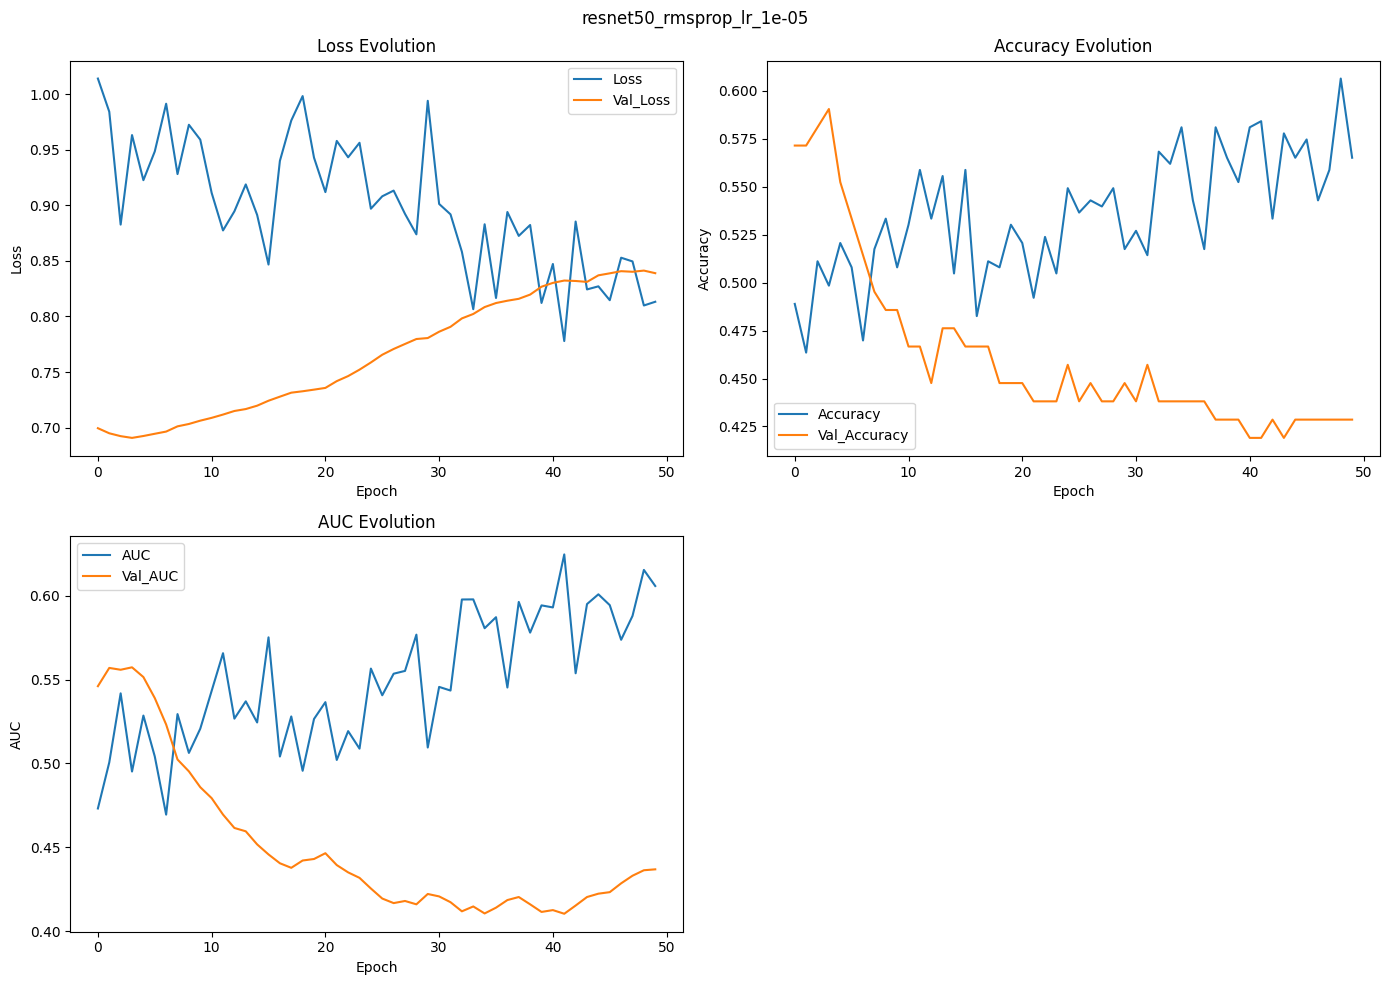

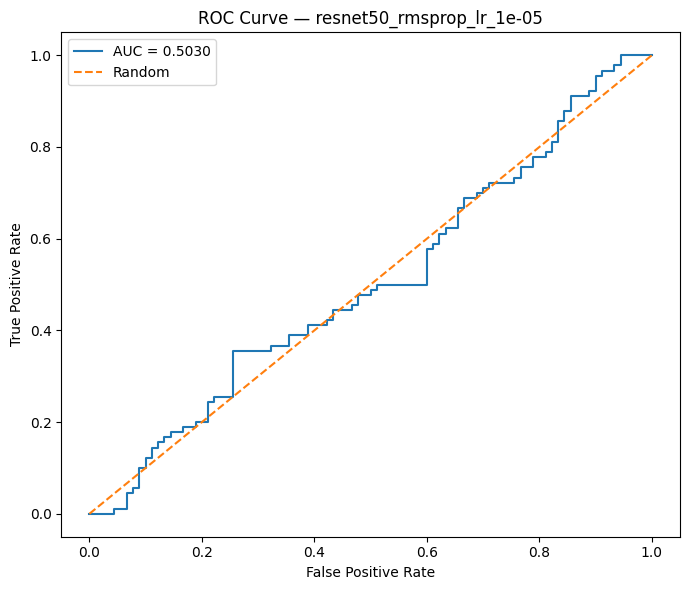

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,52,38
Actual With Disease,53,37


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,rmsprop,0.00001,0.494444,0.493333,0.411111,0.577778,0.448485,0.502963,52,38,53,37,outputs_resnet50\plots\resnet50_rmsprop_lr_1e-...,outputs_resnet50\plots\resnet50_rmsprop_lr_1e-...,outputs_resnet50\reports\resnet50_rmsprop_lr_1...,outputs_resnet50\confusion_matrices\resnet50_r...


,precision,recall,f1-score,support
Without Disease,0.495238,0.577778,0.533333,90.000000
With Disease,0.493333,0.411111,0.448485,90.000000
accuracy,0.494444,0.494444,0.494444,0.494444
macro avg,0.494286,0.494444,0.490909,180.000000
weighted avg,0.494286,0.494444,0.490909,180.000000


Incomplete or missing run, will run: resnet50_rmsprop_lr_1e-06
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_1e-06_history.png
Missing: outputs_resnet50\plots\resnet50_rmsprop_lr_1e-06_roc.png
Missing: outputs_resnet50\reports\resnet50_rmsprop_lr_1e-06_classification_report.csv
Missing: outputs_resnet50\confusion_matrices\resnet50_rmsprop_lr_1e-06_confusion_matrix.csv

Running: resnet50_rmsprop_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4794 - auc: 0.4832 - loss: 1.0057 - precision: 0.4817 - recall: 0.5000 - val_accuracy: 0.7810 - val_auc: 0.8070 - val_loss: 0.6328 - val_precision: 0.8537 - val_recall: 0.6731
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4698 - auc: 0.4674 - loss: 1.0655 - precision: 0.4713 - recall: 0.4684 - val_accuracy: 0.7714 - val_auc: 0.7999 - val_loss: 0.6322 - val_precision: 0.8500 - val_recall: 0.6538
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.4952 - auc: 0.4939 - loss: 0.9942 - precisi

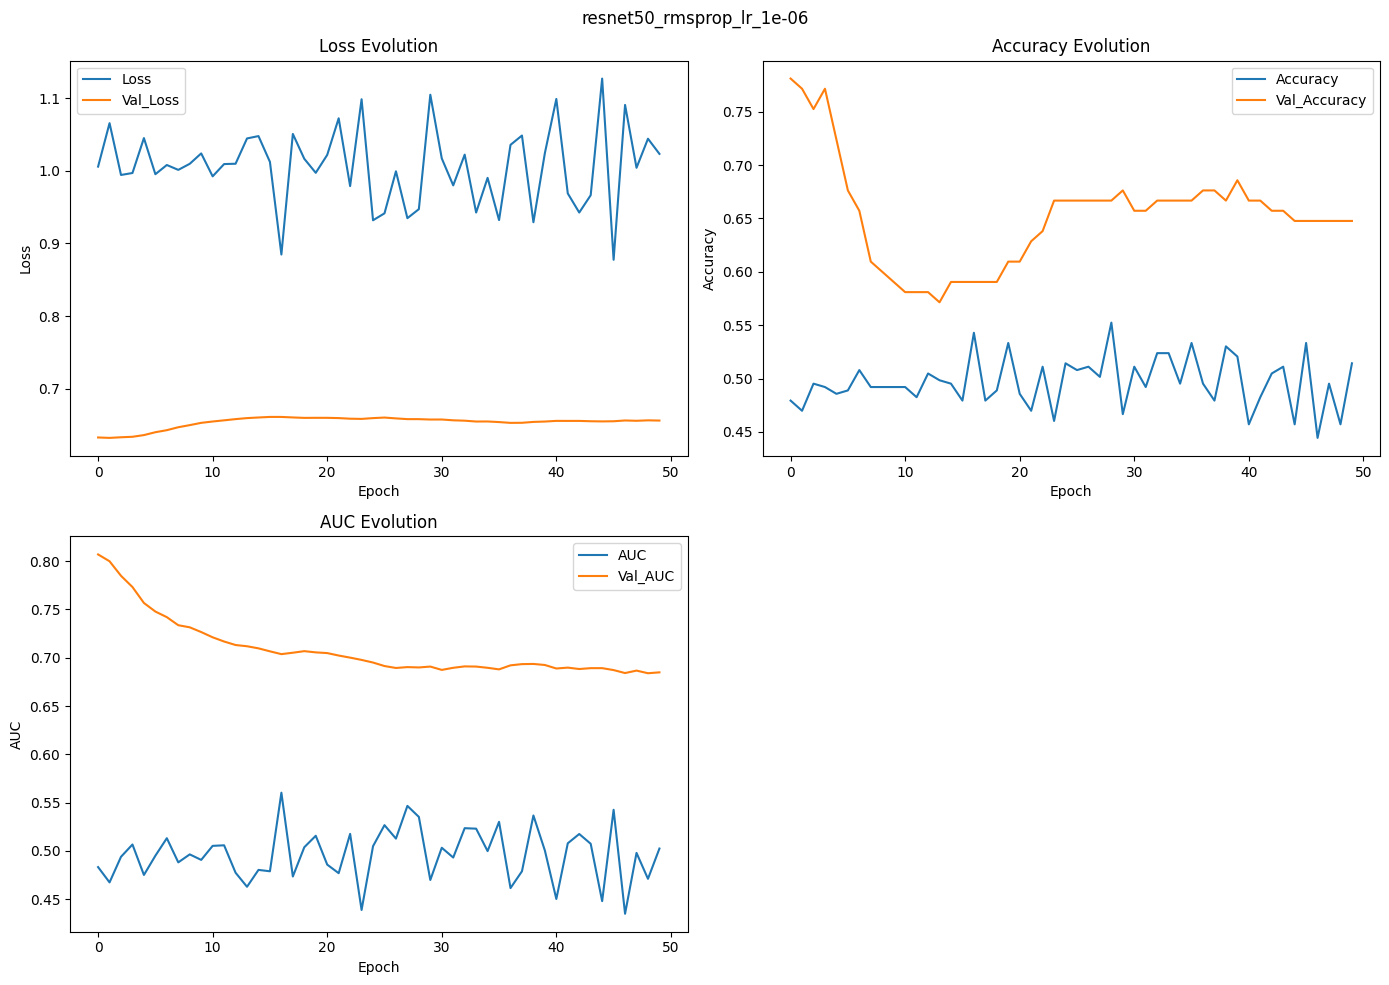

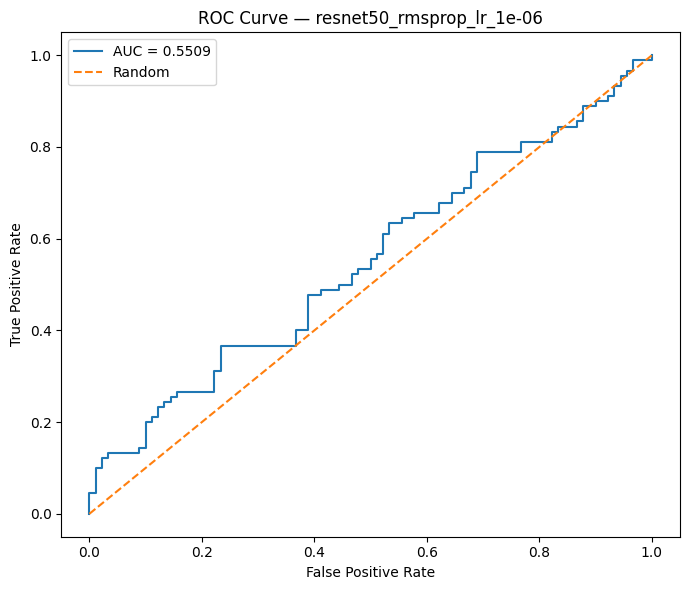

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,65,25
Actual With Disease,57,33


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,rmsprop,0.000001,0.544444,0.568966,0.366667,0.722222,0.445946,0.550864,65,25,57,33,outputs_resnet50\plots\resnet50_rmsprop_lr_1e-...,outputs_resnet50\plots\resnet50_rmsprop_lr_1e-...,outputs_resnet50\reports\resnet50_rmsprop_lr_1...,outputs_resnet50\confusion_matrices\resnet50_r...


,precision,recall,f1-score,support
Without Disease,0.532787,0.722222,0.613208,90.000000
With Disease,0.568966,0.366667,0.445946,90.000000
accuracy,0.544444,0.544444,0.544444,0.544444
macro avg,0.550876,0.544444,0.529577,180.000000
weighted avg,0.550876,0.544444,0.529577,180.000000


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adam,0.000100,0.572222,0.559633,0.677778,0.466667,0.613065,0.580864,42,48,29,61,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\reports\resnet50_adam_lr_0p00...,outputs_resnet50\confusion_matrices\resnet50_a...
1,resnet50,adam,0.000010,0.505556,0.506494,0.433333,0.577778,0.467066,0.547407,52,38,51,39,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...
2,resnet50,adam,0.000001,0.516667,0.510949,0.777778,0.255556,0.616740,0.465309,23,67,20,70,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...
3,resnet50,adagrad,0.000100,0.444444,0.361111,0.144444,0.744444,0.206349,0.453704,67,23,77,13,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\reports\resnet50_adagrad_lr_0...,outputs_resnet50\confusion_matrices\resnet50_a...
4,resnet50,adagrad,0.000010,0.483333,0.483871,0.500000,0.466667,0.491803,0.487160,42,48,45,45,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...
5,resnet50,adagrad,0.000001,0.555556,0.534722,0.855556,0.255556,0.658120,0.623951,23,67,13,77,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...
6,resnet50,adamax,0.000100,0.500000,0.500000,0.255556,0.744444,0.338235,0.544198,67,23,67,23,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\reports\resnet50_adamax_lr_0p...,outputs_resnet50\confusion_matrices\resnet50_a...
7,resnet50,adamax,0.000010,0.550000,0.539823,0.677778,0.422222,0.600985,0.549383,38,52,29,61,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...
8,resnet50,adamax,0.000001,0.533333,0.578947,0.244444,0.822222,0.343750,0.567778,74,16,68,22,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...
9,resnet50,adadelta,0.000100,0.455556,0.463636,0.566667,0.344444,0.510000,0.413951,31,59,39,51,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\reports\resnet50_adadelta_lr_...,outputs_resnet50\confusion_matrices\resnet50_a...


Incomplete or missing run, will run: densenet121_adam_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_adam_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_adam_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_adam_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adam_lr_0p0001_confusion_matrix.csv

Running: densenet121_adam_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4889 - auc: 0.5102 - loss: 0.9553 - precision: 0.4903 - recall: 0.4810 - val_accuracy: 0.4667 - val_auc: 0.4171 - val_loss: 0.7419 - val_precision: 0.4444 - val_recall: 0.3077
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4825 - auc: 0.4777 - loss: 1.0511 - precision: 0.4834 - recall: 0.4620 - val_accuracy: 0.4667 - val_auc: 0.4243 - val_loss: 0.7370 - val_precision: 0.4474 - val_recall: 0.3269
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5365 - auc: 0.5197 - loss

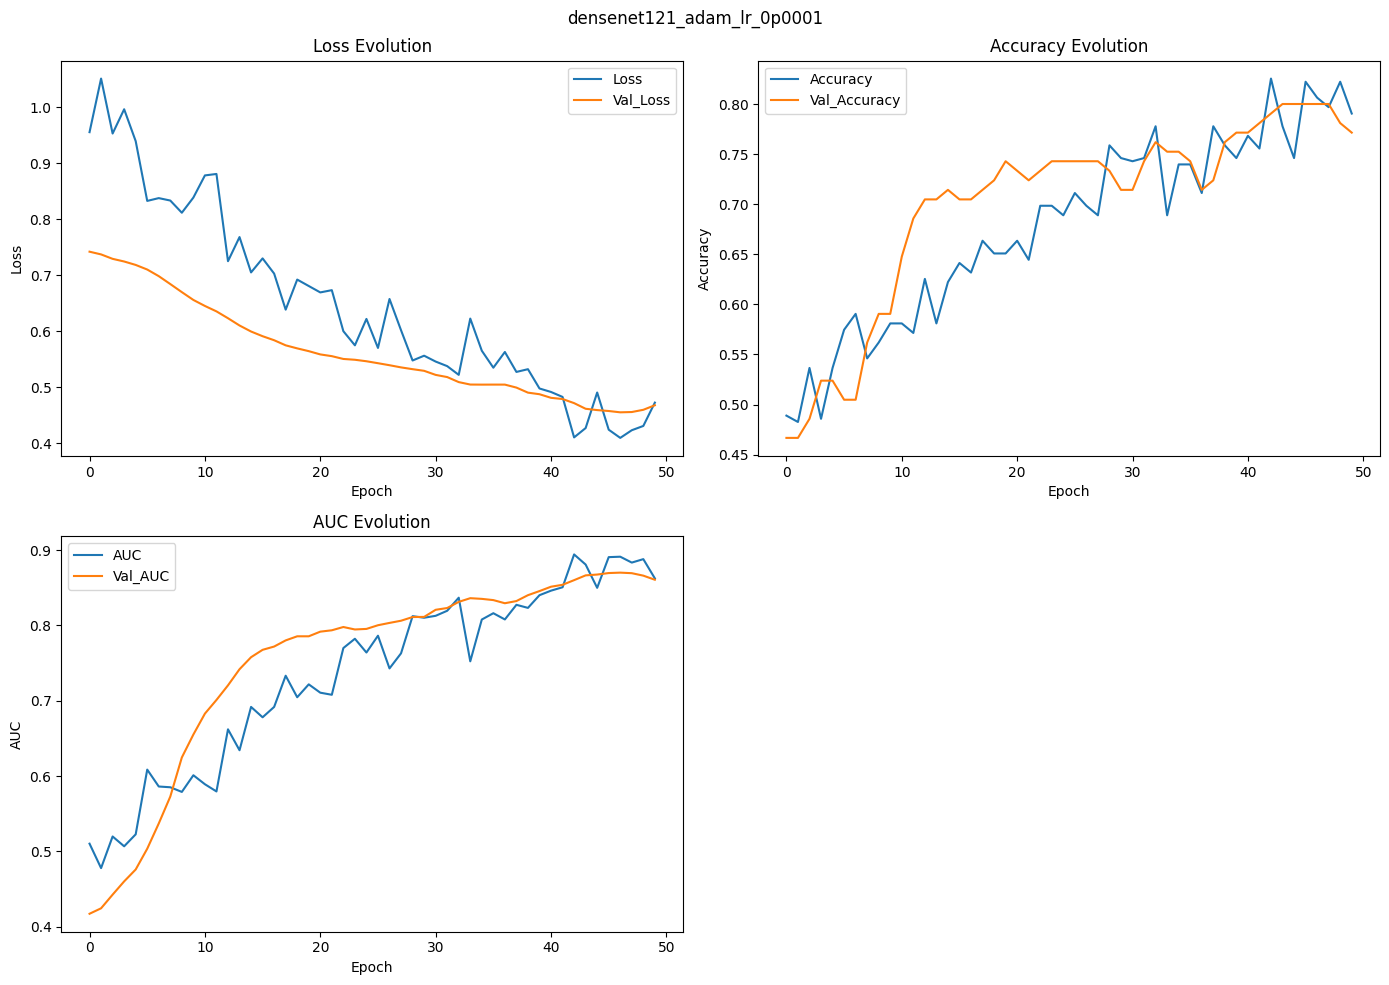

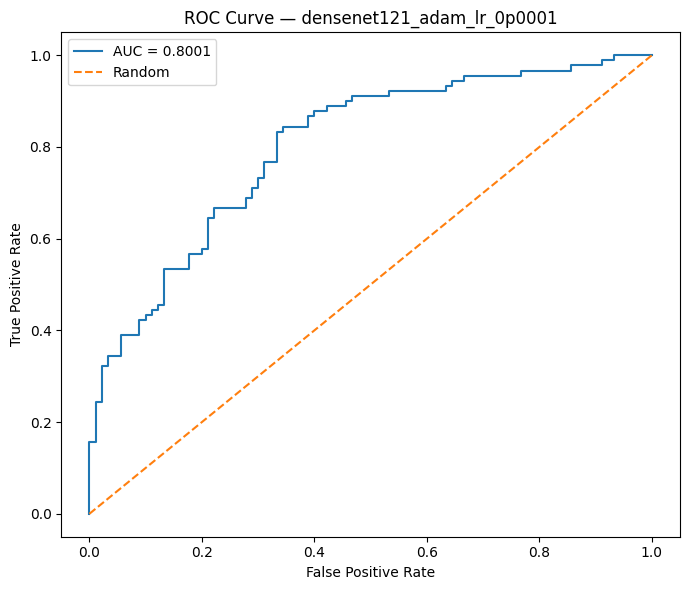

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,62,28
Actual With Disease,24,66


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adam,0.0001,0.711111,0.702128,0.733333,0.688889,0.717391,0.800123,62,28,24,66,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.720930,0.688889,0.704545,90.000000
With Disease,0.702128,0.733333,0.717391,90.000000
accuracy,0.711111,0.711111,0.711111,0.711111
macro avg,0.711529,0.711111,0.710968,180.000000
weighted avg,0.711529,0.711111,0.710968,180.000000


Incomplete or missing run, will run: densenet121_adam_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_adam_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_adam_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_adam_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adam_lr_1e-05_confusion_matrix.csv

Running: densenet121_adam_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4984 - auc: 0.4981 - loss: 0.9025 - precision: 0.5000 - recall: 0.4747 - val_accuracy: 0.4762 - val_auc: 0.5504 - val_loss: 0.7174 - val_precision: 0.4854 - val_recall: 0.9615
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4698 - auc: 0.4634 - loss: 0.9560 - precision: 0.4690 - recall: 0.4304 - val_accuracy: 0.5048 - val_auc: 0.5673 - val_loss: 0.6996 - val_precision: 0.5000 - val_recall: 0.8654
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5365 - auc: 0.5416 - loss: 0.84

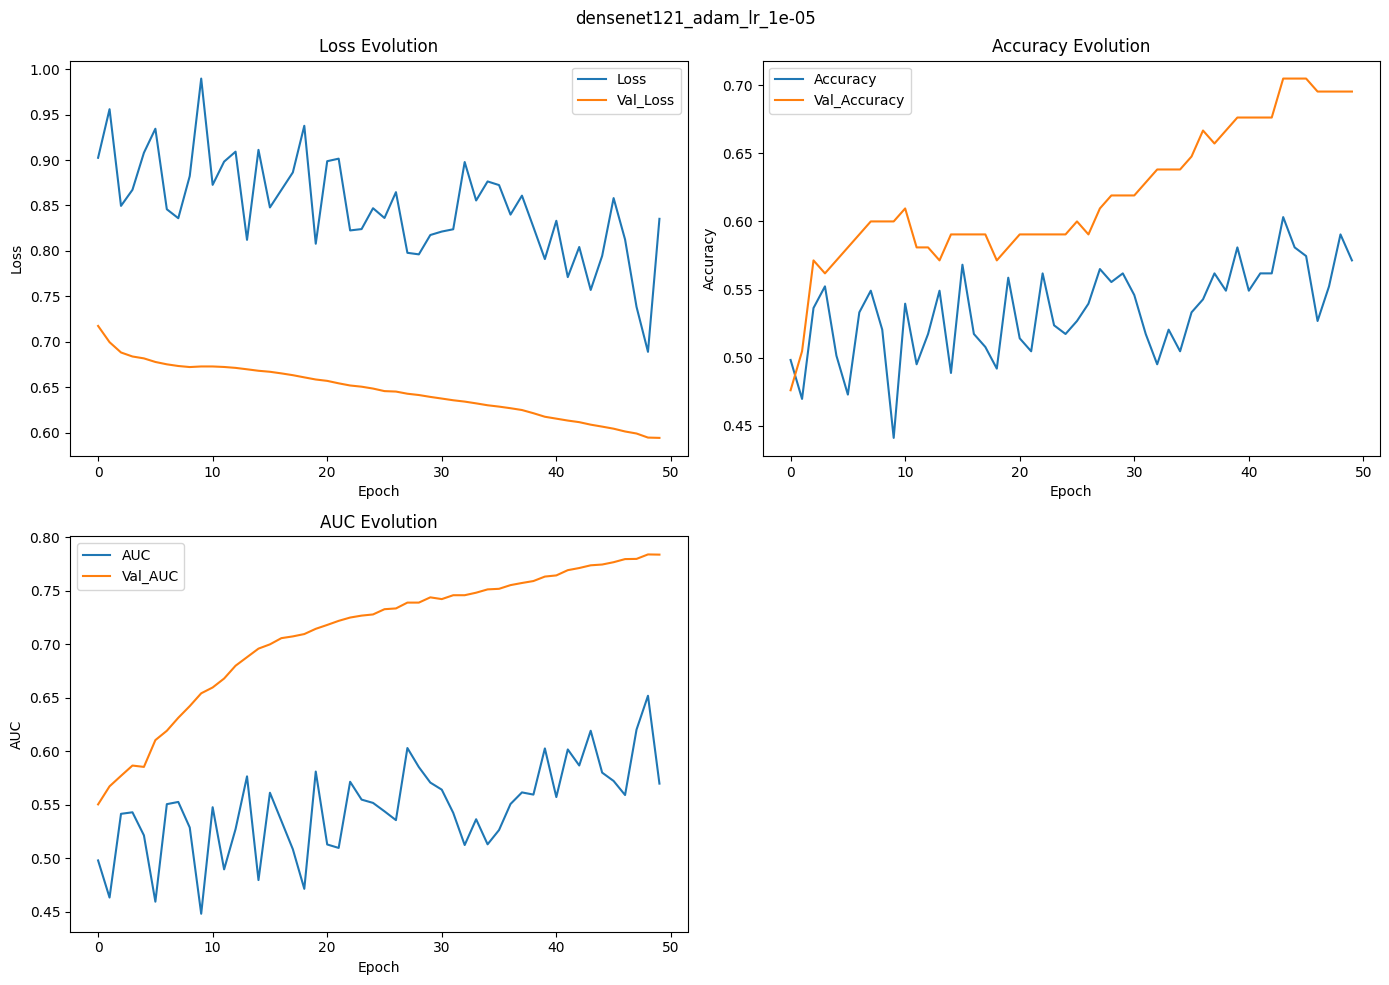

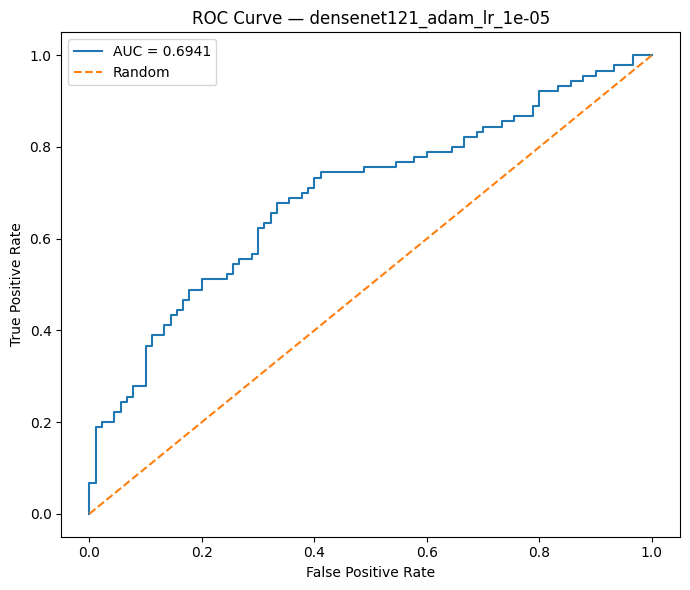

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,27,63
Actual With Disease,14,76


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adam,0.00001,0.572222,0.546763,0.844444,0.3,0.663755,0.694074,27,63,14,76,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.658537,0.300000,0.412214,90.000000
With Disease,0.546763,0.844444,0.663755,90.000000
accuracy,0.572222,0.572222,0.572222,0.572222
macro avg,0.602650,0.572222,0.537985,180.000000
weighted avg,0.602650,0.572222,0.537985,180.000000


Incomplete or missing run, will run: densenet121_adam_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_adam_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_adam_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_adam_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adam_lr_1e-06_confusion_matrix.csv

Running: densenet121_adam_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5302 - auc: 0.5125 - loss: 0.8987 - precision: 0.5333 - recall: 0.5063 - val_accuracy: 0.5238 - val_auc: 0.6199 - val_loss: 0.6757 - val_precision: 0.5128 - val_recall: 0.7692
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5365 - auc: 0.5163 - loss: 0.8826 - precision: 0.5390 - recall: 0.5253 - val_accuracy: 0.5048 - val_auc: 0.6061 - val_loss: 0.6788 - val_precision: 0.5000 - val_recall: 0.7885
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4921 - auc: 0.4761 - loss: 0.92

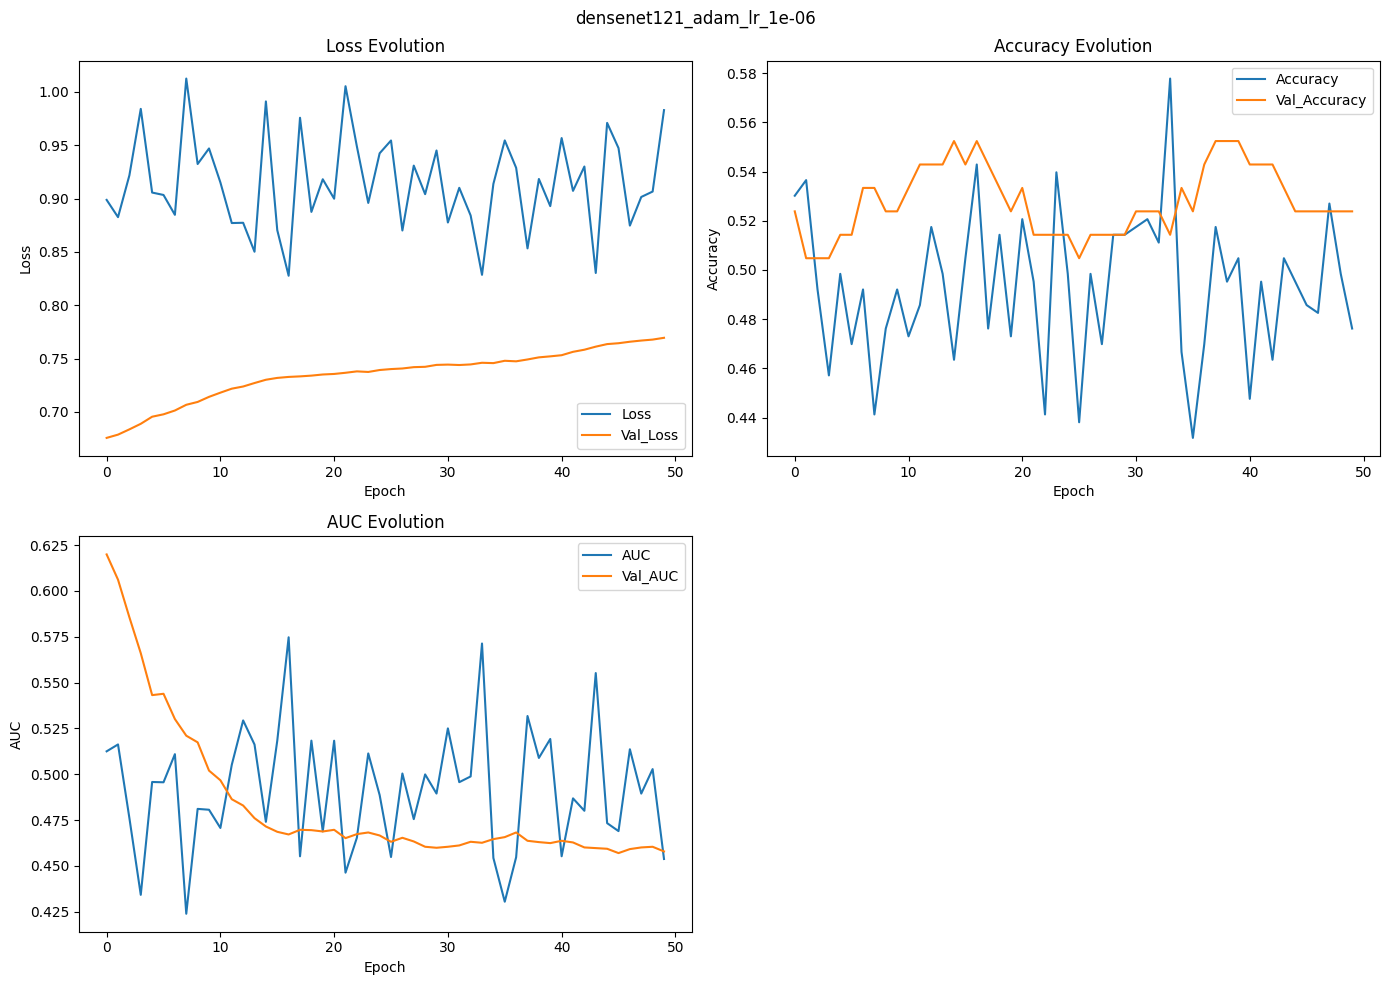

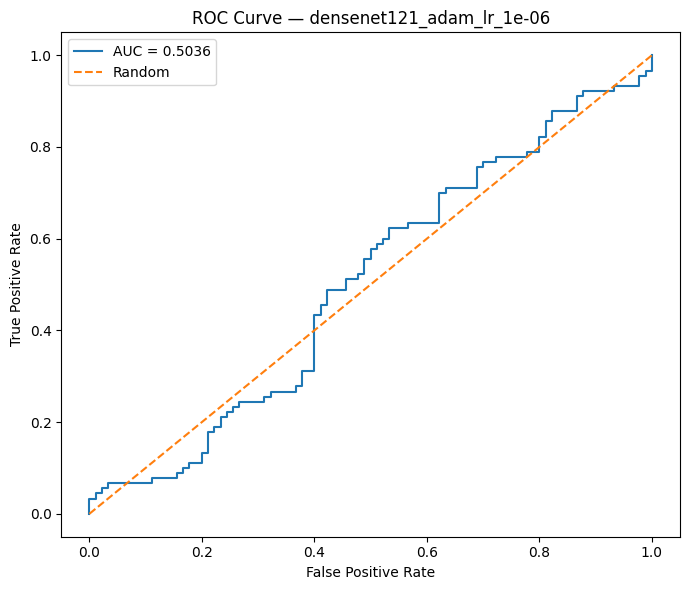

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,62,28
Actual With Disease,68,22


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adam,0.000001,0.466667,0.44,0.244444,0.688889,0.314286,0.50358,62,28,68,22,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.476923,0.688889,0.563636,90.000000
With Disease,0.440000,0.244444,0.314286,90.000000
accuracy,0.466667,0.466667,0.466667,0.466667
macro avg,0.458462,0.466667,0.438961,180.000000
weighted avg,0.458462,0.466667,0.438961,180.000000


Incomplete or missing run, will run: densenet121_adagrad_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_adagrad_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adagrad_lr_0p0001_confusion_matrix.csv

Running: densenet121_adagrad_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4603 - auc: 0.4509 - loss: 0.9524 - precision: 0.4643 - recall: 0.4937 - val_accuracy: 0.3429 - val_auc: 0.2905 - val_loss: 0.7760 - val_precision: 0.4000 - val_recall: 0.6538
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4921 - auc: 0.4877 - loss: 0.9566 - precision: 0.4932 - recall: 0.4557 - val_accuracy: 0.3238 - val_auc: 0.2977 - val_loss: 0.7727 - val_precision: 0.3827 - val_recall: 0.5962
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4984 - 

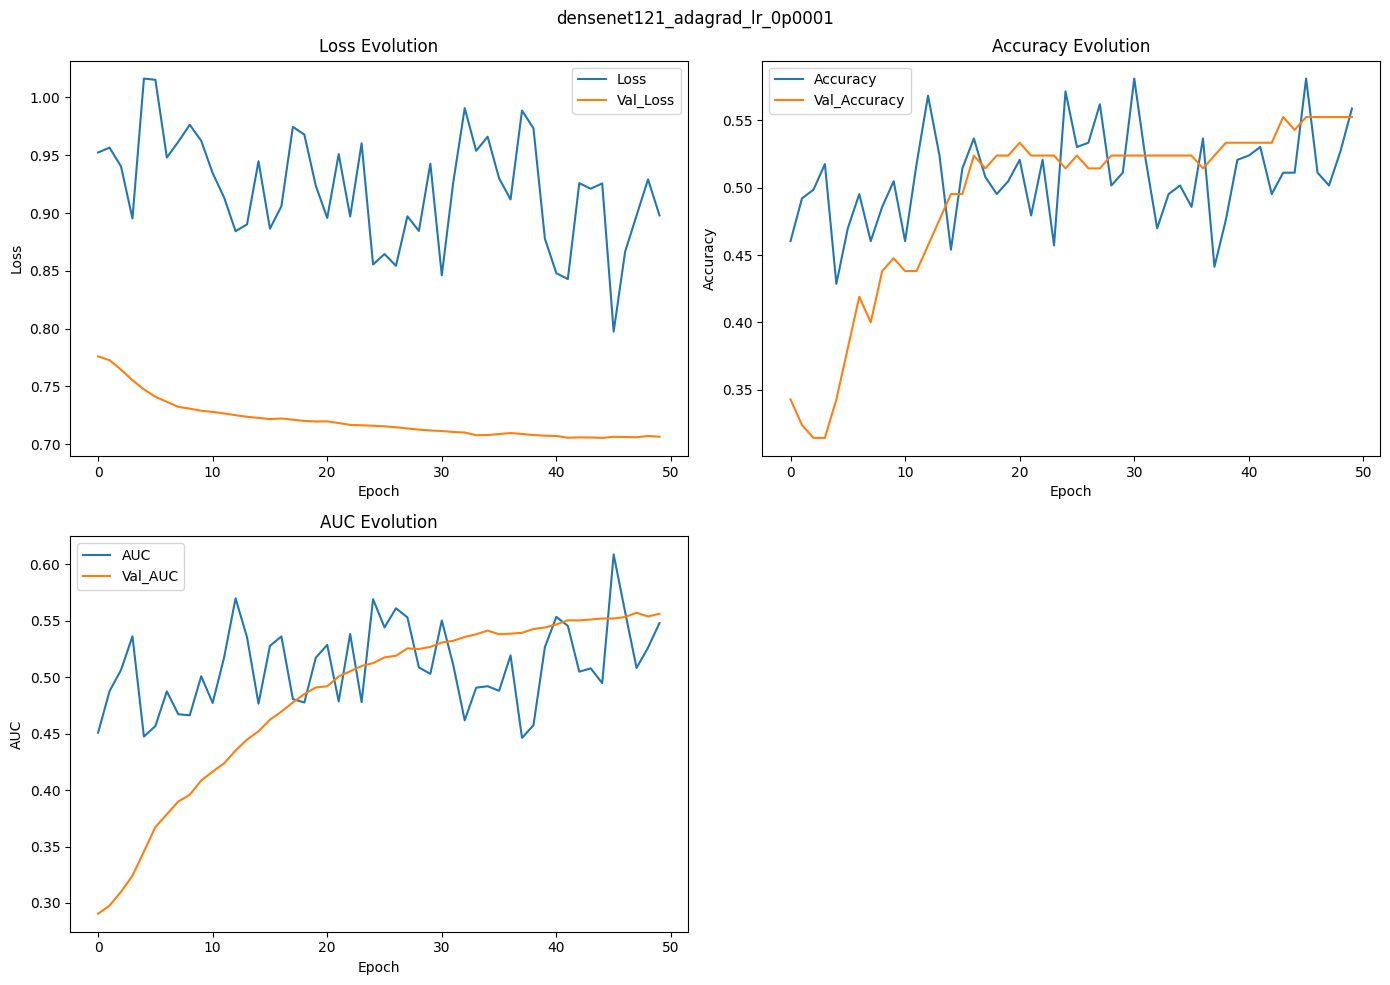

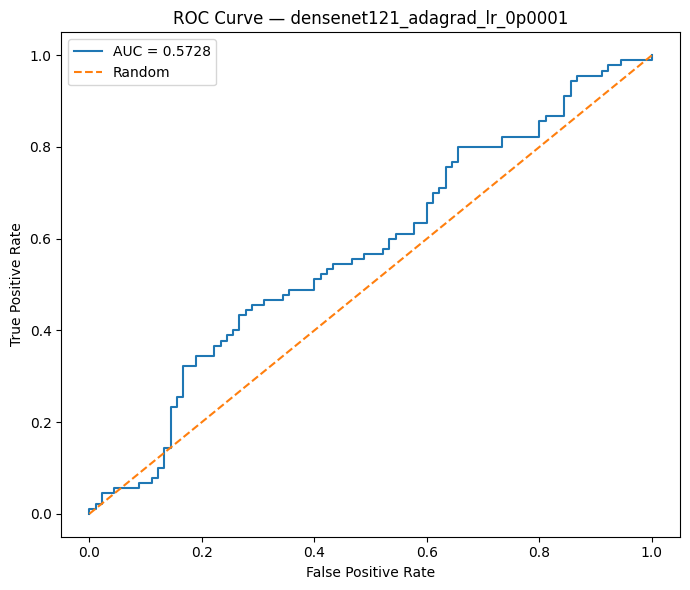

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,30,60
Actual With Disease,18,72


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adagrad,0.0001,0.566667,0.545455,0.8,0.333333,0.648649,0.57284,30,60,18,72,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.625000,0.333333,0.434783,90.000000
With Disease,0.545455,0.800000,0.648649,90.000000
accuracy,0.566667,0.566667,0.566667,0.566667
macro avg,0.585227,0.566667,0.541716,180.000000
weighted avg,0.585227,0.566667,0.541716,180.000000


Incomplete or missing run, will run: densenet121_adagrad_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_adagrad_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adagrad_lr_1e-05_confusion_matrix.csv

Running: densenet121_adagrad_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4603 - auc: 0.4403 - loss: 1.0124 - precision: 0.4625 - recall: 0.4684 - val_accuracy: 0.3714 - val_auc: 0.2324 - val_loss: 0.7599 - val_precision: 0.4146 - val_recall: 0.6538
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5206 - auc: 0.5171 - loss: 0.9342 - precision: 0.5238 - recall: 0.4873 - val_accuracy: 0.3714 - val_auc: 0.2286 - val_loss: 0.7645 - val_precision: 0.4186 - val_recall: 0.6923
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5175 - auc: 0

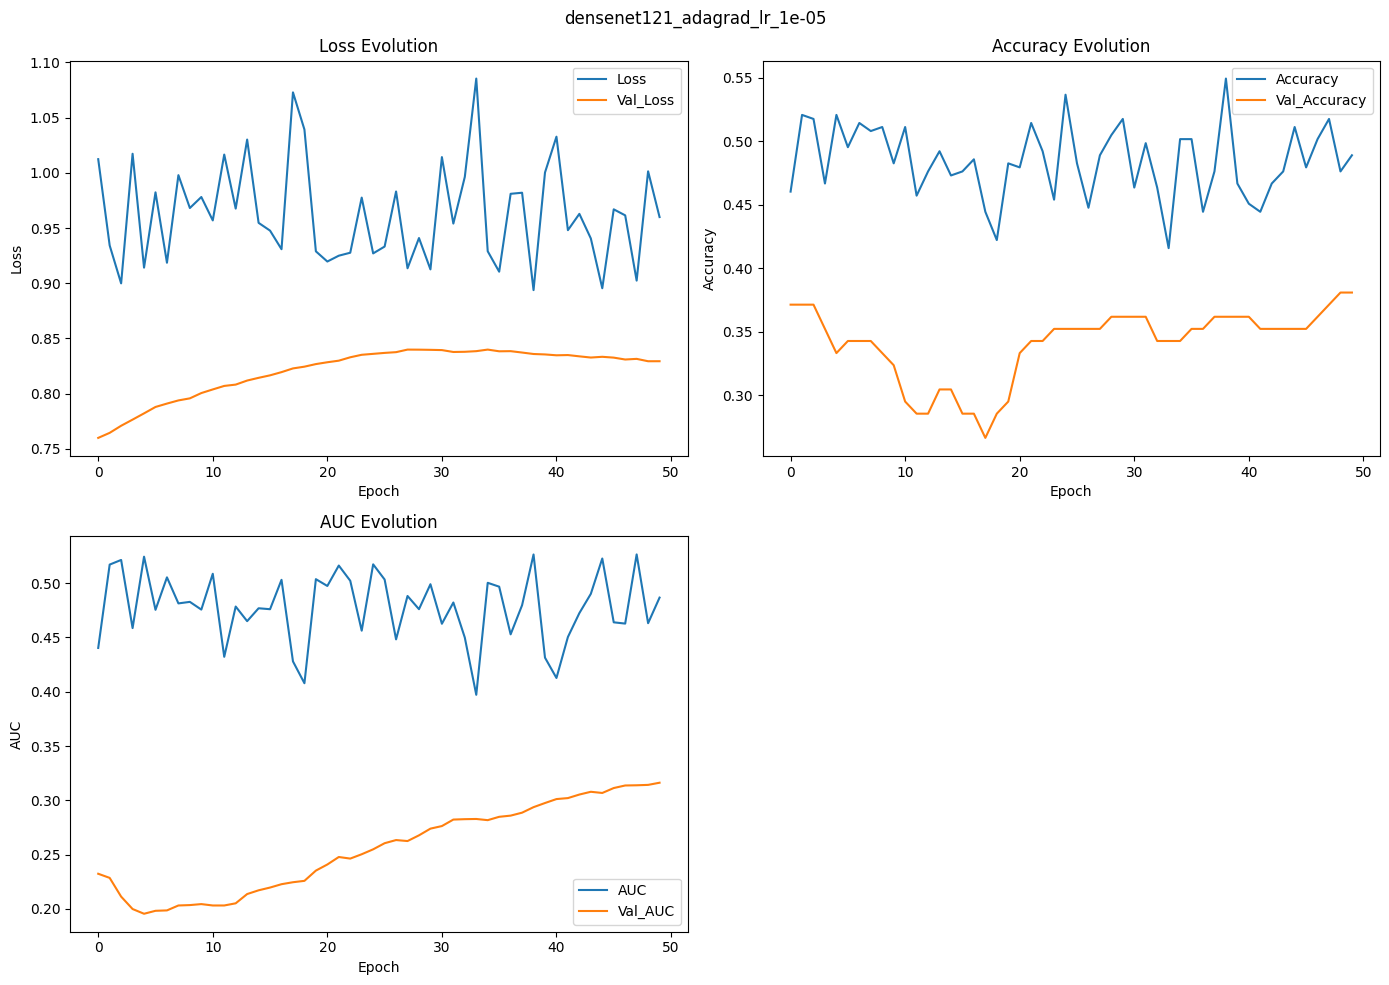

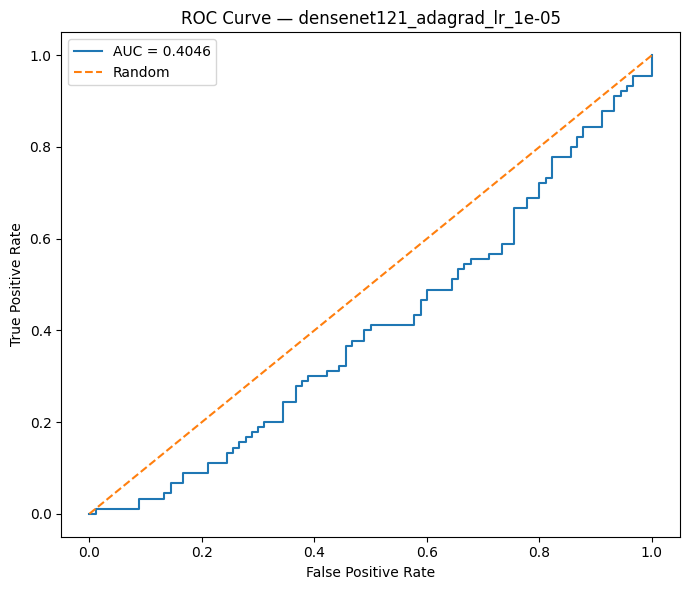

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,29,61
Actual With Disease,40,50


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adagrad,0.00001,0.438889,0.45045,0.555556,0.322222,0.497512,0.404568,29,61,40,50,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.420290,0.322222,0.364780,90.000000
With Disease,0.450450,0.555556,0.497512,90.000000
accuracy,0.438889,0.438889,0.438889,0.438889
macro avg,0.435370,0.438889,0.431146,180.000000
weighted avg,0.435370,0.438889,0.431146,180.000000


Incomplete or missing run, will run: densenet121_adagrad_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_adagrad_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_adagrad_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adagrad_lr_1e-06_confusion_matrix.csv

Running: densenet121_adagrad_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5206 - auc: 0.5405 - loss: 0.8694 - precision: 0.5217 - recall: 0.5316 - val_accuracy: 0.5238 - val_auc: 0.4869 - val_loss: 0.7030 - val_precision: 0.5135 - val_recall: 0.7308
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5111 - auc: 0.5112 - loss: 0.9032 - precision: 0.5132 - recall: 0.4937 - val_accuracy: 0.4857 - val_auc: 0.4744 - val_loss: 0.7041 - val_precision: 0.4821 - val_recall: 0.5192
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5016 - auc: 0

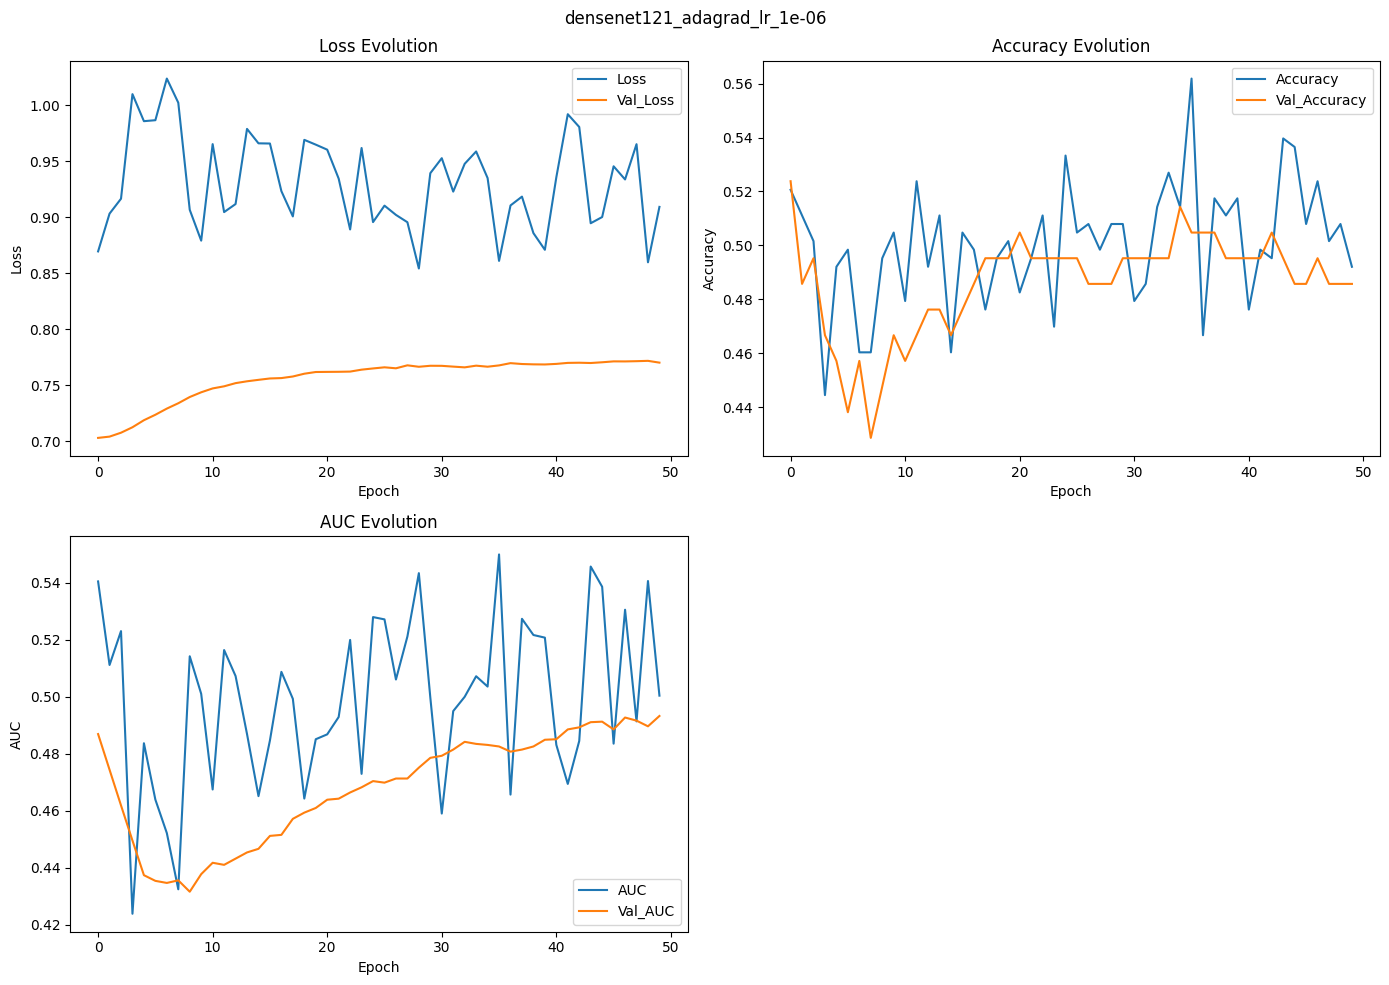

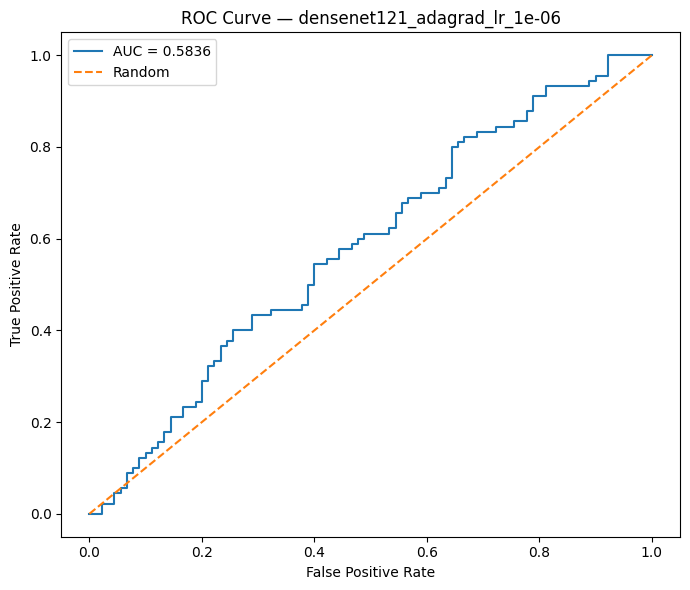

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,24,66
Actual With Disease,14,76


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adagrad,0.000001,0.555556,0.535211,0.844444,0.266667,0.655172,0.58358,24,66,14,76,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.631579,0.266667,0.375000,90.000000
With Disease,0.535211,0.844444,0.655172,90.000000
accuracy,0.555556,0.555556,0.555556,0.555556
macro avg,0.583395,0.555556,0.515086,180.000000
weighted avg,0.583395,0.555556,0.515086,180.000000


Incomplete or missing run, will run: densenet121_adamax_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_adamax_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_adamax_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_adamax_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adamax_lr_0p0001_confusion_matrix.csv

Running: densenet121_adamax_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4889 - auc: 0.4965 - loss: 1.0118 - precision: 0.4902 - recall: 0.4747 - val_accuracy: 0.5429 - val_auc: 0.5604 - val_loss: 0.6880 - val_precision: 0.5333 - val_recall: 0.6154
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4984 - auc: 0.5284 - loss: 0.9691 - precision: 0.5000 - recall: 0.5063 - val_accuracy: 0.5810 - val_auc: 0.5780 - val_loss: 0.6867 - val_precision: 0.5588 - val_recall: 0.7308
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4794 - auc: 0

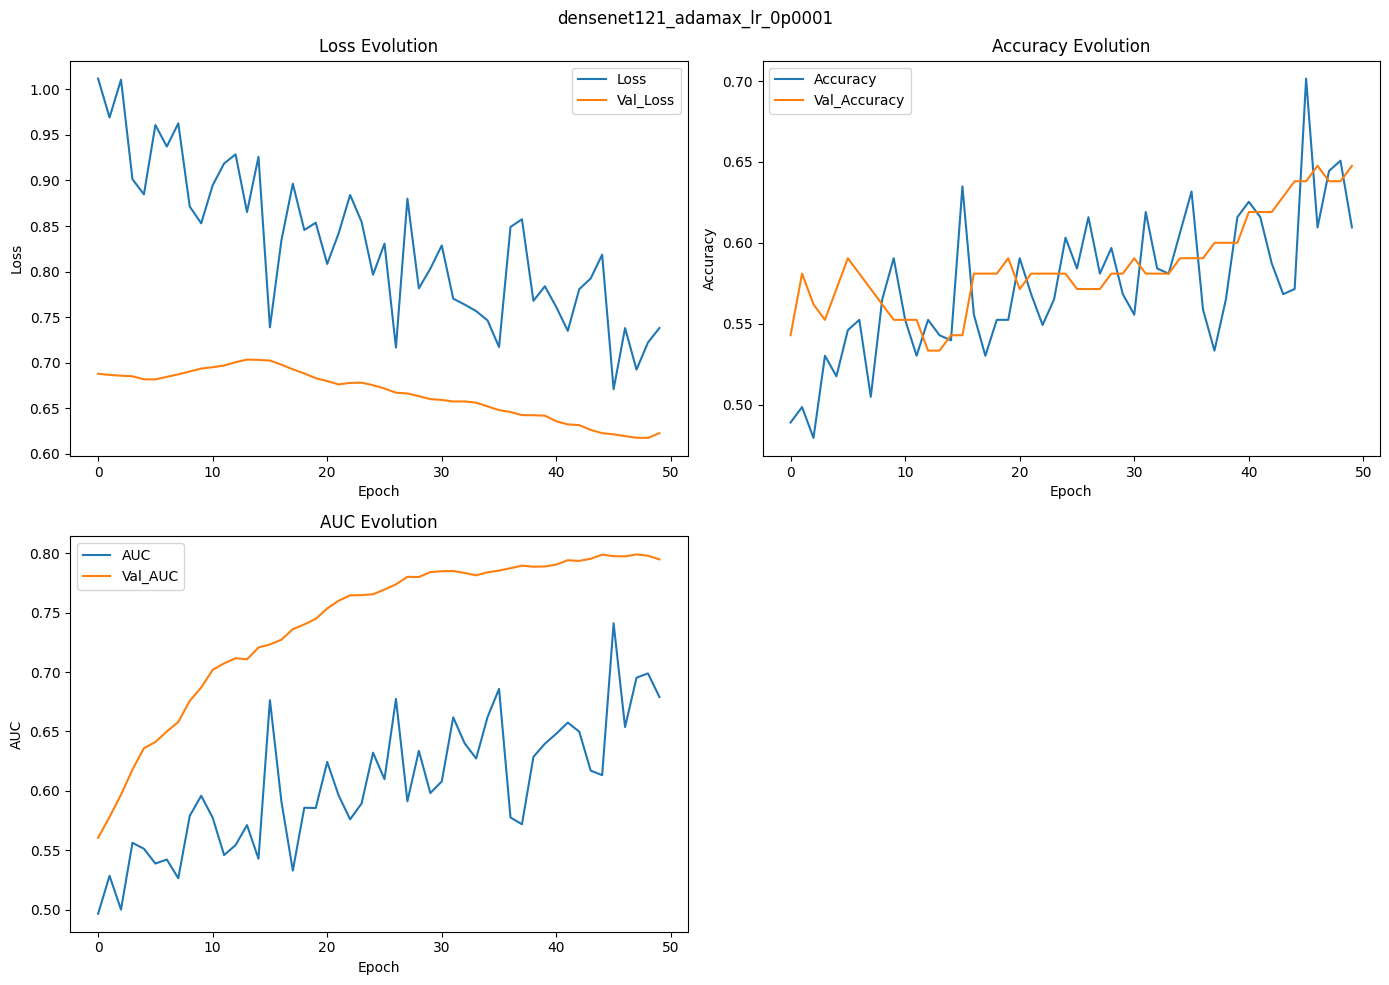

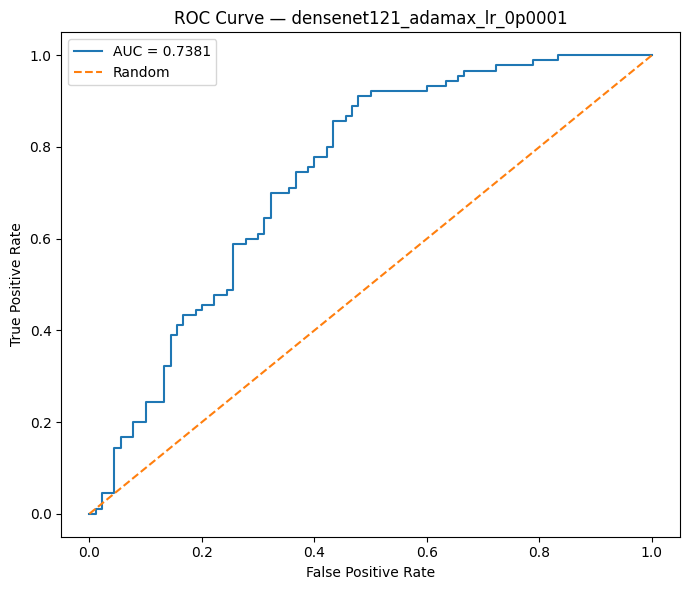

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,76,14
Actual With Disease,55,35


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adamax,0.0001,0.616667,0.714286,0.388889,0.844444,0.503597,0.738148,76,14,55,35,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.580153,0.844444,0.687783,90.000000
With Disease,0.714286,0.388889,0.503597,90.000000
accuracy,0.616667,0.616667,0.616667,0.616667
macro avg,0.647219,0.616667,0.595690,180.000000
weighted avg,0.647219,0.616667,0.595690,180.000000


Incomplete or missing run, will run: densenet121_adamax_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_adamax_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_adamax_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_adamax_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adamax_lr_1e-05_confusion_matrix.csv

Running: densenet121_adamax_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.4603 - auc: 0.4458 - loss: 1.0330 - precision: 0.4625 - recall: 0.4684 - val_accuracy: 0.3714 - val_auc: 0.2906 - val_loss: 0.8251 - val_precision: 0.4222 - val_recall: 0.7308
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4762 - auc: 0.4584 - loss: 0.9905 - precision: 0.4771 - recall: 0.4620 - val_accuracy: 0.3524 - val_auc: 0.2872 - val_loss: 0.8159 - val_precision: 0.4024 - val_recall: 0.6346
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4889 - auc: 0.4930 

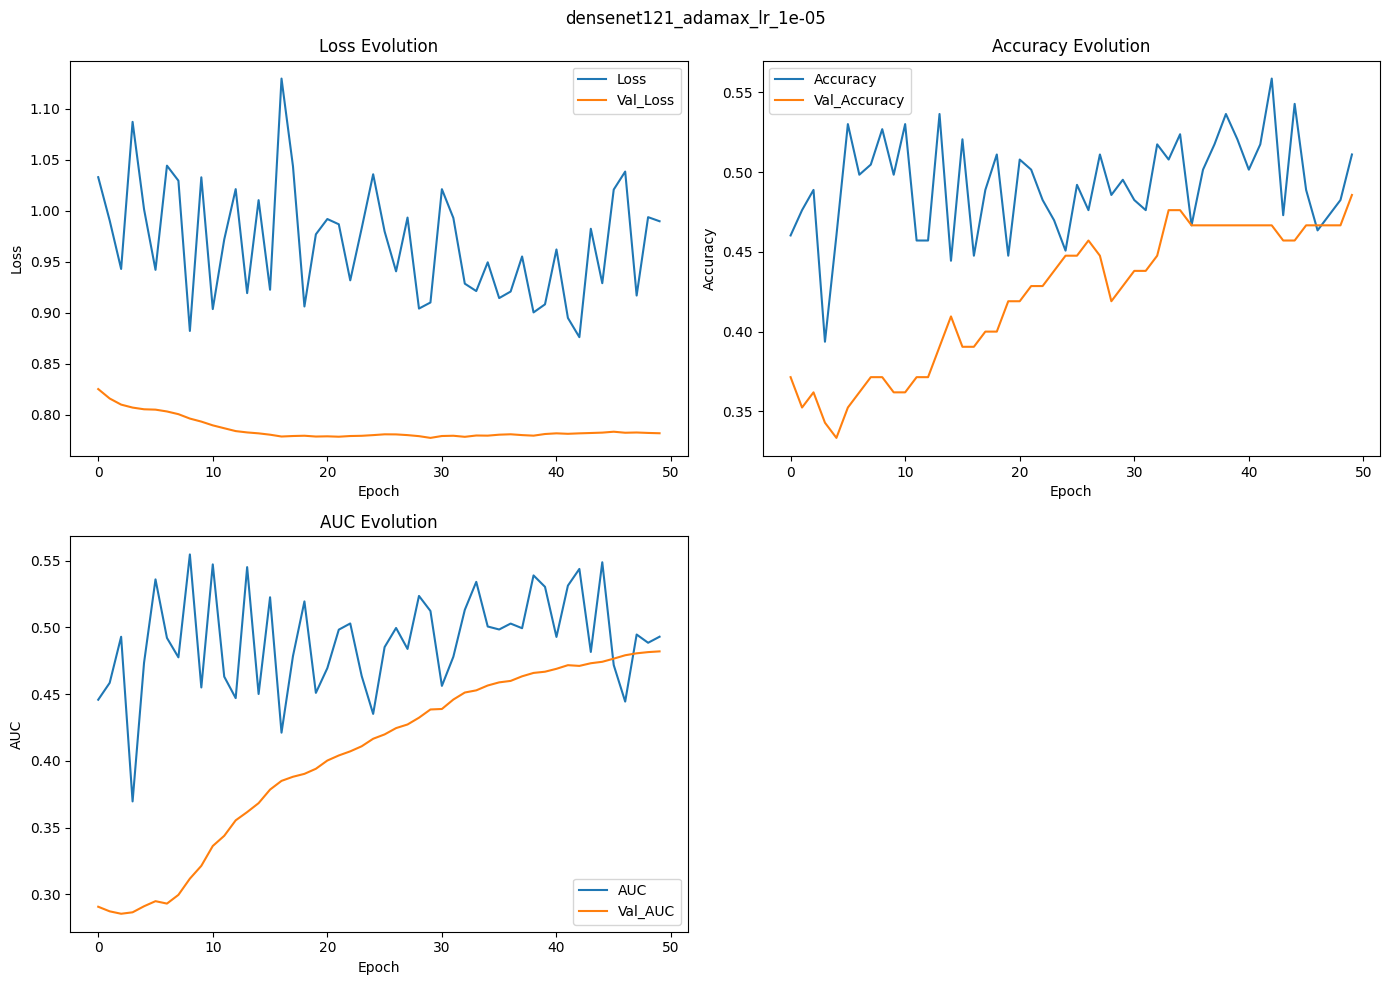

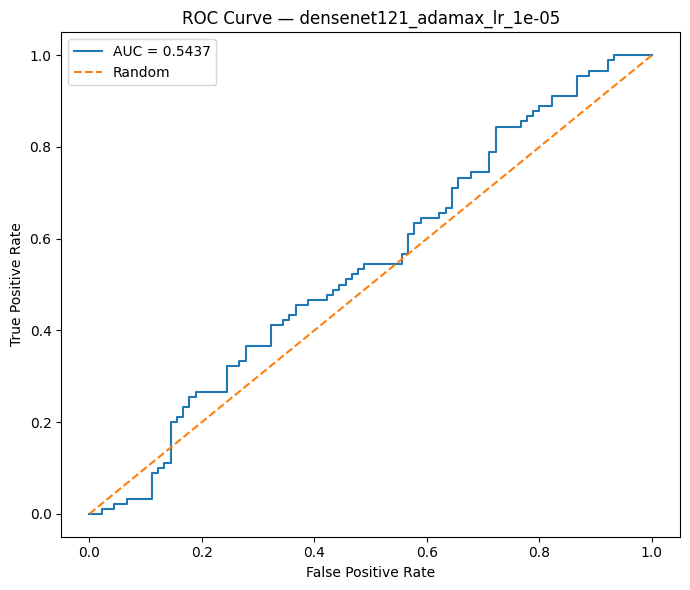

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,40,50
Actual With Disease,39,51


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adamax,0.00001,0.505556,0.50495,0.566667,0.444444,0.534031,0.543704,40,50,39,51,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.506329,0.444444,0.473373,90.000000
With Disease,0.504950,0.566667,0.534031,90.000000
accuracy,0.505556,0.505556,0.505556,0.505556
macro avg,0.505640,0.505556,0.503702,180.000000
weighted avg,0.505640,0.505556,0.503702,180.000000


Incomplete or missing run, will run: densenet121_adamax_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_adamax_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_adamax_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_adamax_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adamax_lr_1e-06_confusion_matrix.csv

Running: densenet121_adamax_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5397 - auc: 0.5526 - loss: 0.8662 - precision: 0.5394 - recall: 0.5633 - val_accuracy: 0.6095 - val_auc: 0.6821 - val_loss: 0.6576 - val_precision: 0.6341 - val_recall: 0.5000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5111 - auc: 0.5279 - loss: 0.9510 - precision: 0.5133 - recall: 0.4873 - val_accuracy: 0.6095 - val_auc: 0.6651 - val_loss: 0.6620 - val_precision: 0.6341 - val_recall: 0.5000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5238 - auc: 0.5408 

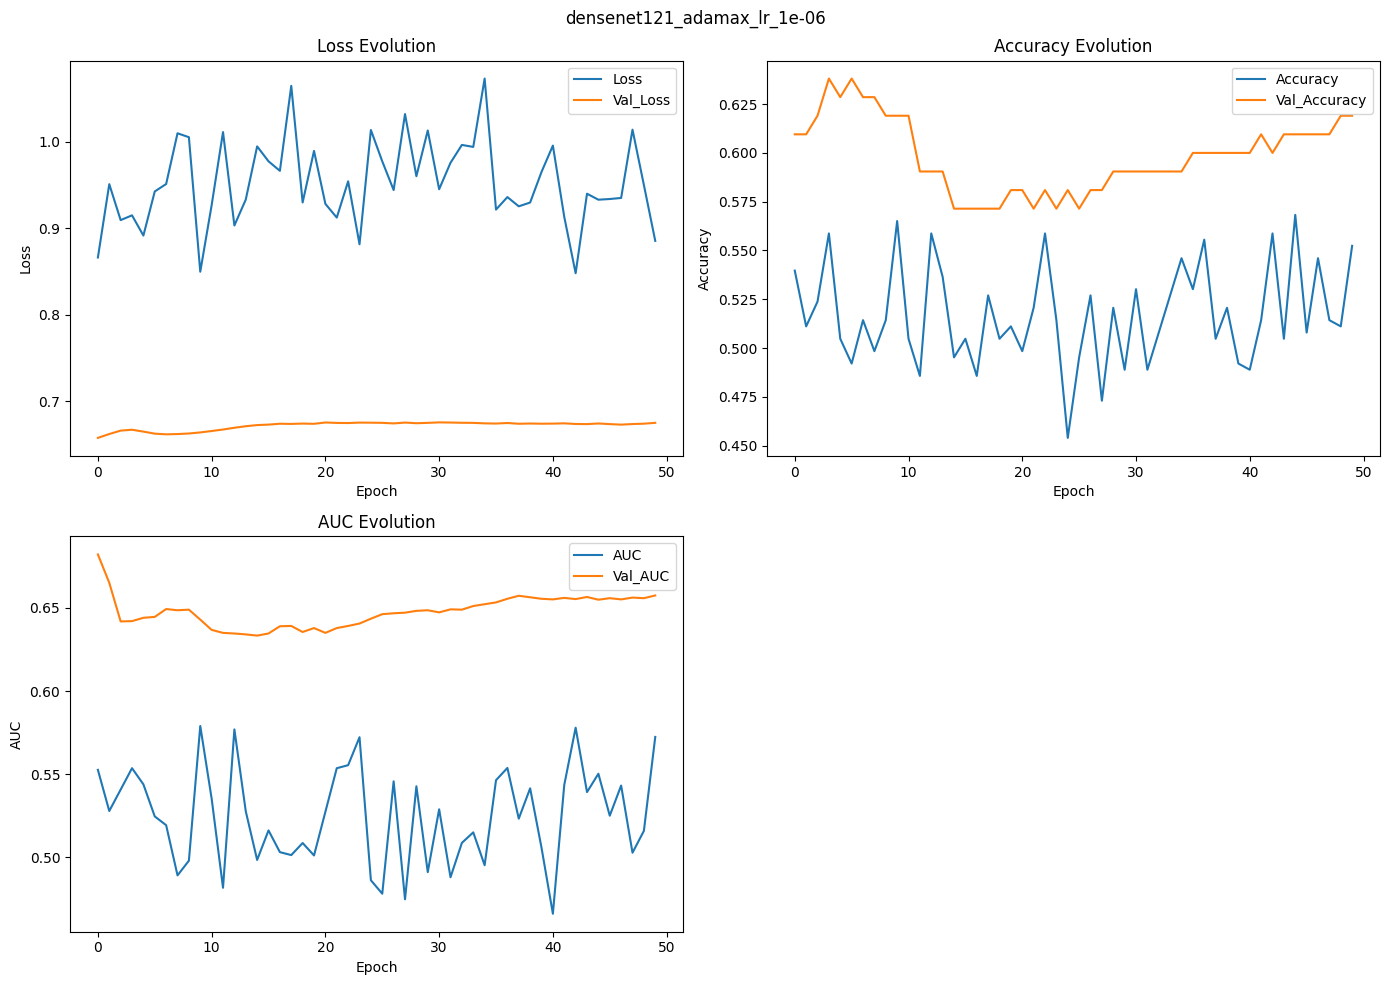

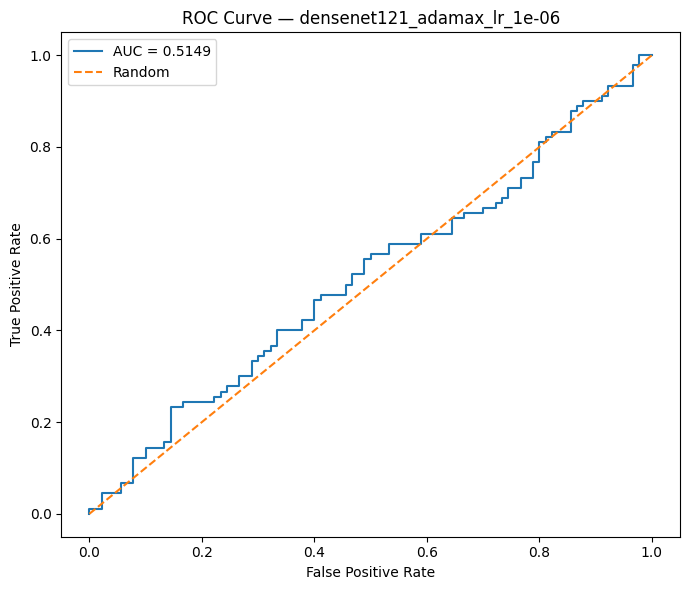

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,69,21
Actual With Disease,66,24


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adamax,0.000001,0.516667,0.533333,0.266667,0.766667,0.355556,0.514938,69,21,66,24,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.511111,0.766667,0.613333,90.000000
With Disease,0.533333,0.266667,0.355556,90.000000
accuracy,0.516667,0.516667,0.516667,0.516667
macro avg,0.522222,0.516667,0.484444,180.000000
weighted avg,0.522222,0.516667,0.484444,180.000000


Incomplete or missing run, will run: densenet121_adadelta_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_adadelta_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adadelta_lr_0p0001_confusion_matrix.csv

Running: densenet121_adadelta_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4762 - auc: 0.4584 - loss: 1.0088 - precision: 0.4780 - recall: 0.4810 - val_accuracy: 0.4857 - val_auc: 0.2161 - val_loss: 0.8385 - val_precision: 0.4902 - val_recall: 0.9615
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4857 - auc: 0.4993 - loss: 1.0119 - precision: 0.4878 - recall: 0.5063 - val_accuracy: 0.4571 - val_auc: 0.2175 - val_loss: 0.8206 - val_precision: 0.4737 - val_recall: 0.8654
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4

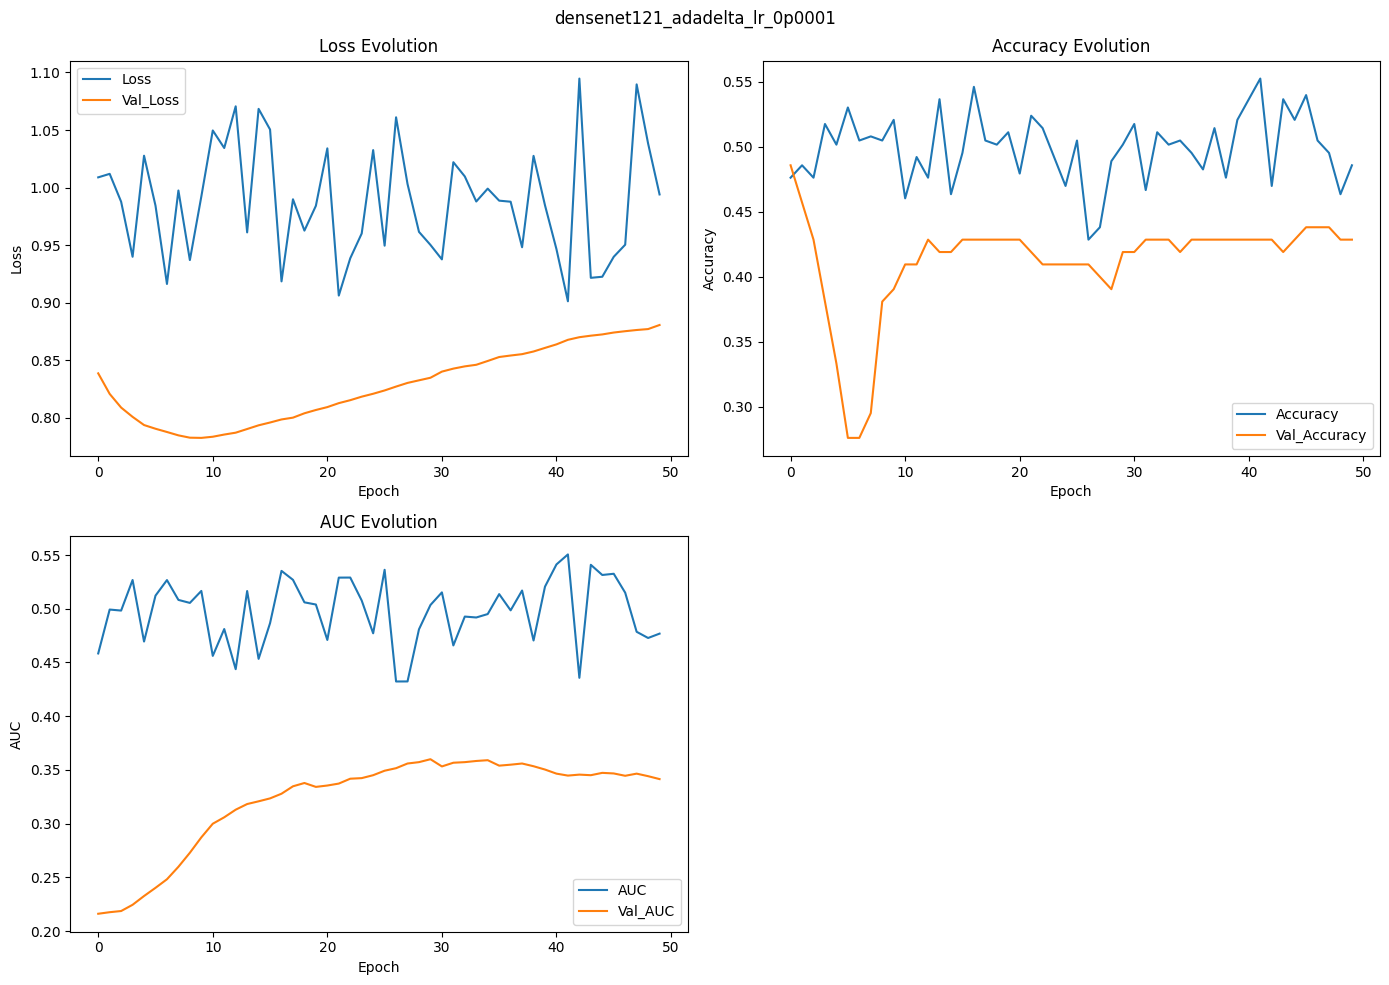

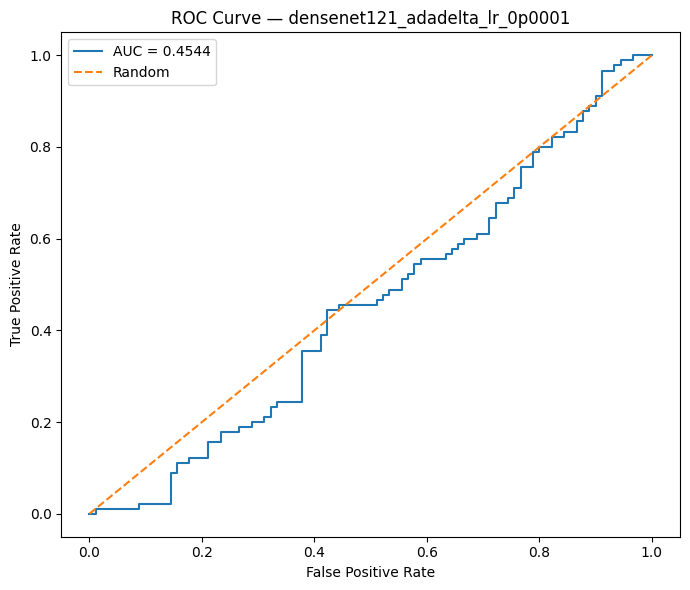

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,21,69
Actual With Disease,26,64


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adadelta,0.0001,0.472222,0.481203,0.711111,0.233333,0.573991,0.454444,21,69,26,64,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\reports\densenet121_adadel...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.446809,0.233333,0.306569,90.000000
With Disease,0.481203,0.711111,0.573991,90.000000
accuracy,0.472222,0.472222,0.472222,0.472222
macro avg,0.464006,0.472222,0.440280,180.000000
weighted avg,0.464006,0.472222,0.440280,180.000000


Incomplete or missing run, will run: densenet121_adadelta_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_adadelta_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adadelta_lr_1e-05_confusion_matrix.csv

Running: densenet121_adadelta_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.5143 - auc: 0.4886 - loss: 0.9912 - precision: 0.5157 - recall: 0.5190 - val_accuracy: 0.3810 - val_auc: 0.3266 - val_loss: 0.7373 - val_precision: 0.4235 - val_recall: 0.6923
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4635 - auc: 0.4443 - loss: 1.0288 - precision: 0.4667 - recall: 0.4873 - val_accuracy: 0.3905 - val_auc: 0.3122 - val_loss: 0.7422 - val_precision: 0.4302 - val_recall: 0.7115
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4825 - 

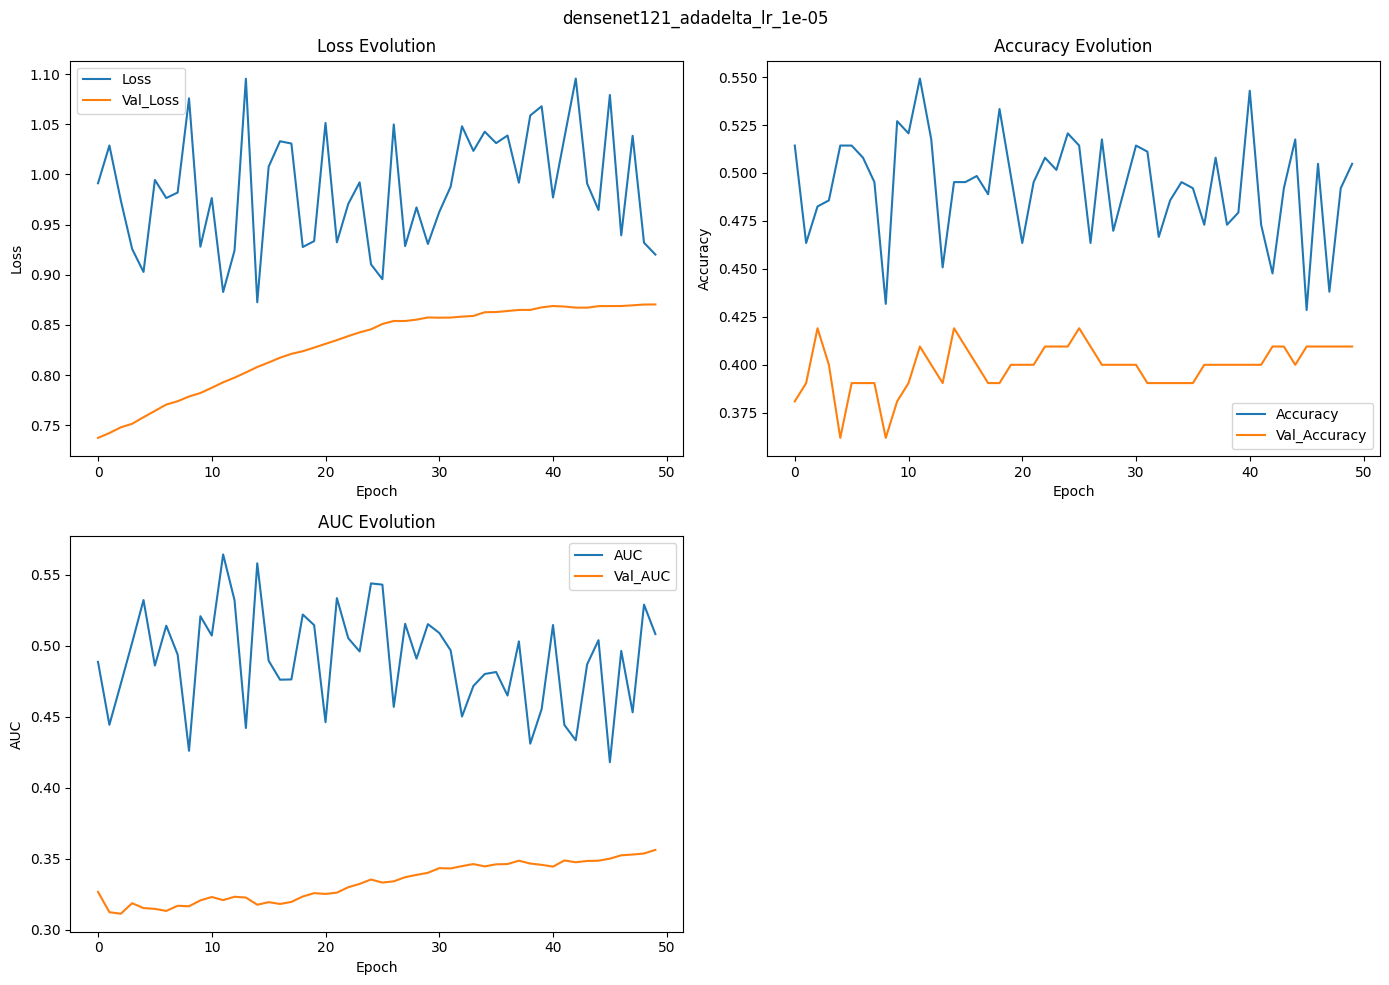

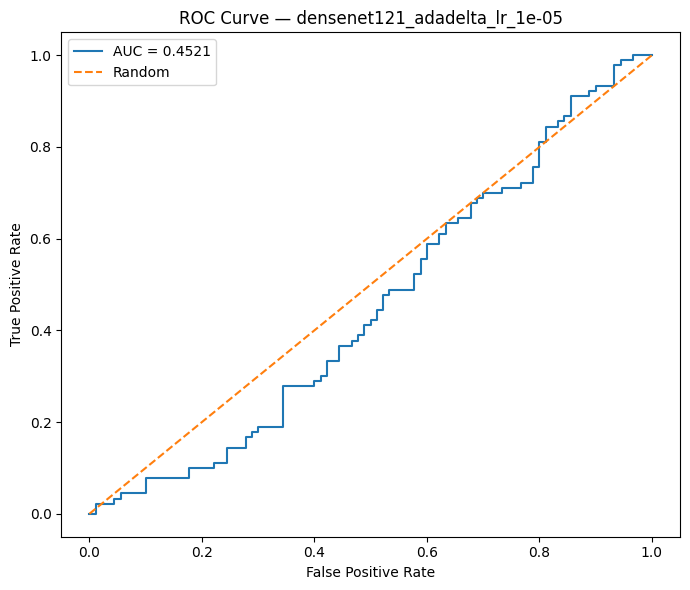

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,46,44
Actual With Disease,55,35


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adadelta,0.00001,0.45,0.443038,0.388889,0.511111,0.414201,0.452099,46,44,55,35,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\reports\densenet121_adadel...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.455446,0.511111,0.481675,90.00
With Disease,0.443038,0.388889,0.414201,90.00
accuracy,0.450000,0.450000,0.450000,0.45
macro avg,0.449242,0.450000,0.447938,180.00
weighted avg,0.449242,0.450000,0.447938,180.00


Incomplete or missing run, will run: densenet121_adadelta_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_adadelta_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_adadelta_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_adadelta_lr_1e-06_confusion_matrix.csv

Running: densenet121_adadelta_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4698 - auc: 0.4613 - loss: 0.9882 - precision: 0.4702 - recall: 0.4494 - val_accuracy: 0.4857 - val_auc: 0.3948 - val_loss: 0.7600 - val_precision: 0.4902 - val_recall: 0.9615
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4762 - auc: 0.4838 - loss: 0.9630 - precision: 0.4795 - recall: 0.5190 - val_accuracy: 0.4571 - val_auc: 0.4260 - val_loss: 0.7321 - val_precision: 0.4719 - val_recall: 0.8077
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.4794 - 

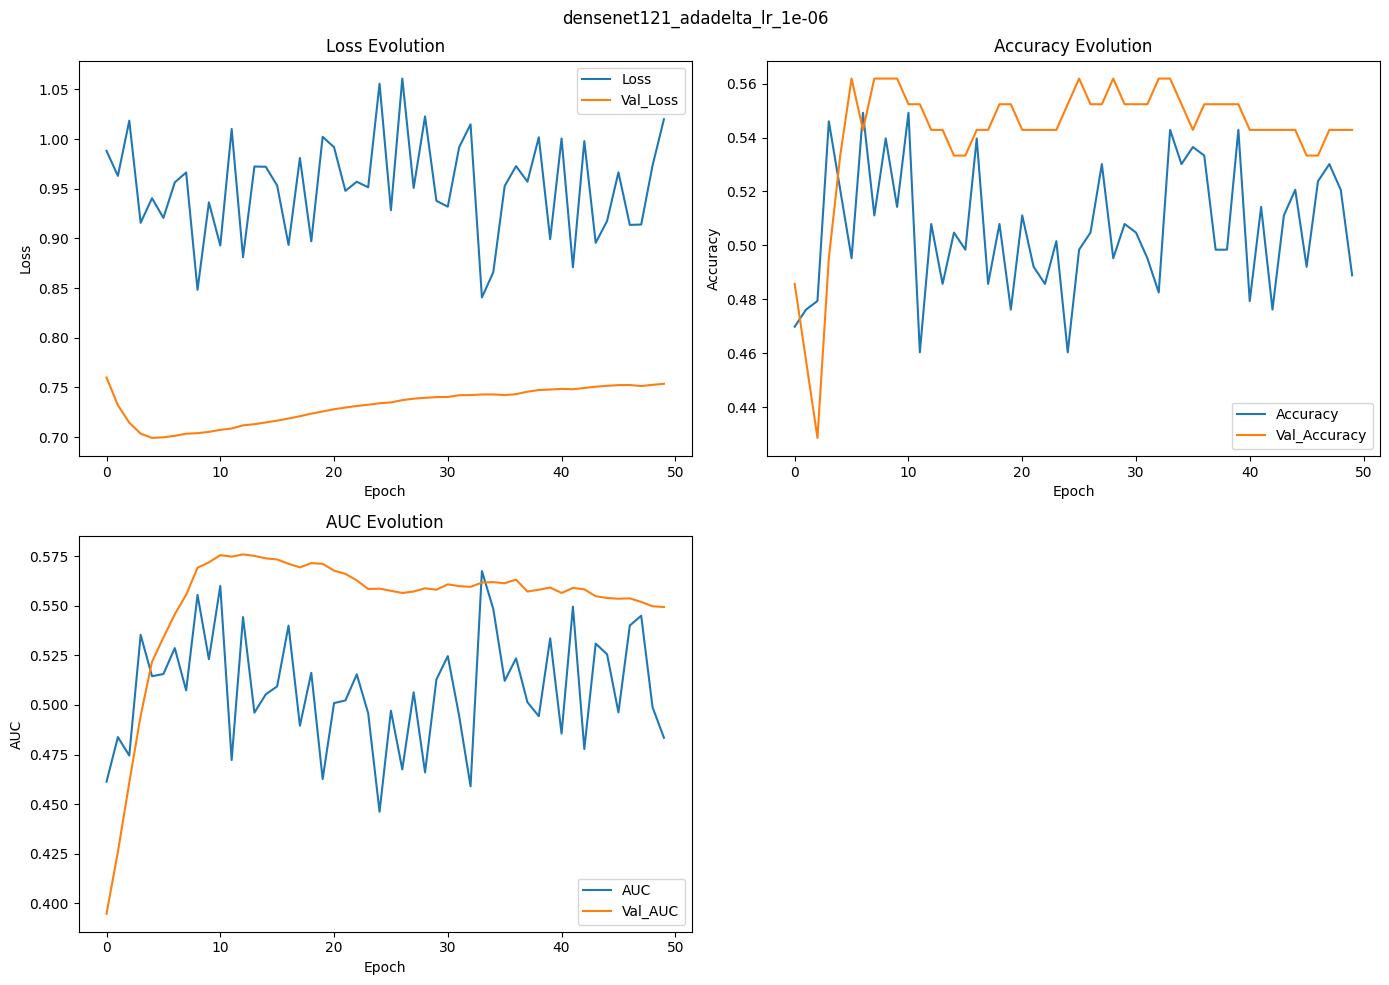

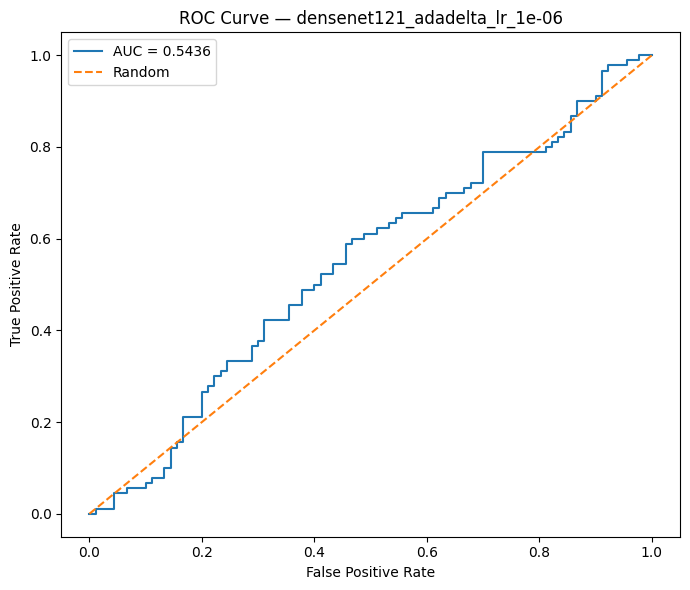

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,31,59
Actual With Disease,27,63


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adadelta,0.000001,0.522222,0.516393,0.7,0.344444,0.59434,0.54358,31,59,27,63,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\reports\densenet121_adadel...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.534483,0.344444,0.418919,90.000000
With Disease,0.516393,0.700000,0.594340,90.000000
accuracy,0.522222,0.522222,0.522222,0.522222
macro avg,0.525438,0.522222,0.506629,180.000000
weighted avg,0.525438,0.522222,0.506629,180.000000


Incomplete or missing run, will run: densenet121_sgd_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_sgd_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_sgd_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_sgd_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_sgd_lr_0p0001_confusion_matrix.csv

Running: densenet121_sgd_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5206 - auc: 0.5269 - loss: 0.8676 - precision: 0.5220 - recall: 0.5253 - val_accuracy: 0.5143 - val_auc: 0.5602 - val_loss: 0.6947 - val_precision: 0.5054 - val_recall: 0.9038
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4889 - auc: 0.4978 - loss: 0.9321 - precision: 0.4901 - recall: 0.4684 - val_accuracy: 0.5333 - val_auc: 0.5615 - val_loss: 0.6926 - val_precision: 0.5176 - val_recall: 0.8462
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4921 - auc: 0.5008 - loss: 0.97

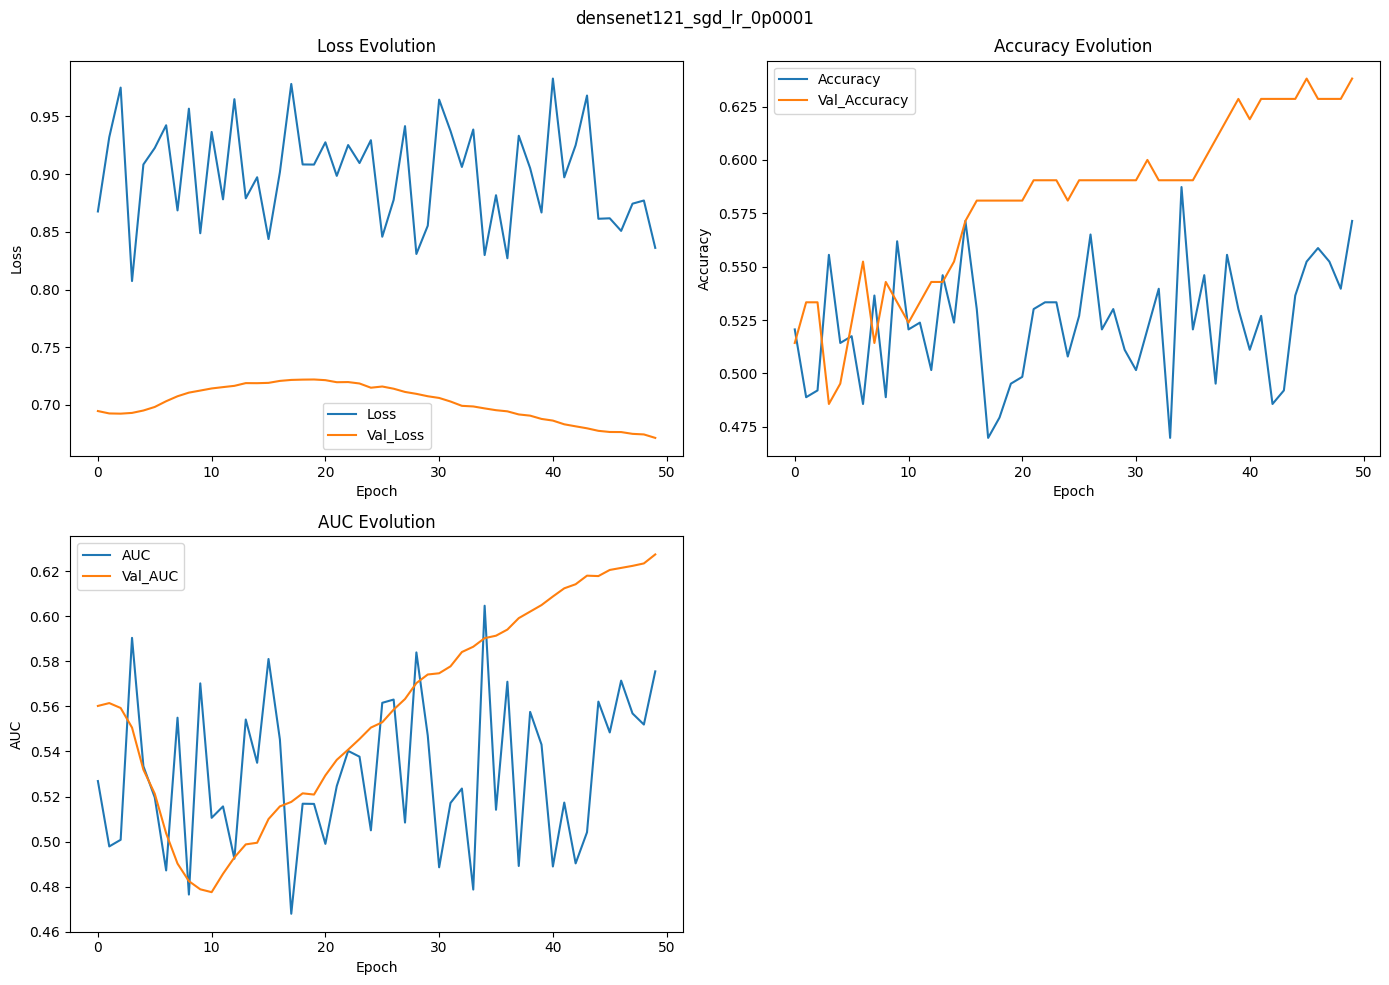

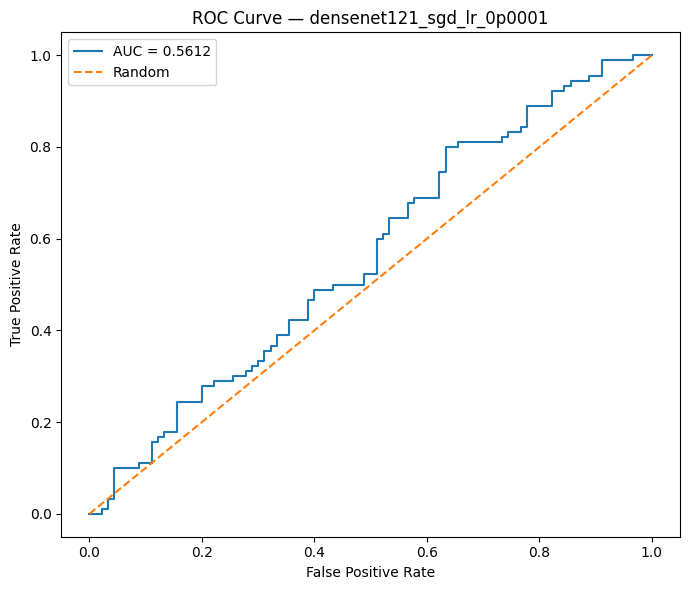

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,30,60
Actual With Disease,17,73


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,sgd,0.0001,0.572222,0.548872,0.811111,0.333333,0.654709,0.561235,30,60,17,73,outputs_densenet121\plots\densenet121_sgd_lr_0...,outputs_densenet121\plots\densenet121_sgd_lr_0...,outputs_densenet121\reports\densenet121_sgd_lr...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.638298,0.333333,0.437956,90.000000
With Disease,0.548872,0.811111,0.654709,90.000000
accuracy,0.572222,0.572222,0.572222,0.572222
macro avg,0.593585,0.572222,0.546332,180.000000
weighted avg,0.593585,0.572222,0.546332,180.000000


Incomplete or missing run, will run: densenet121_sgd_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_sgd_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_sgd_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_sgd_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_sgd_lr_1e-05_confusion_matrix.csv

Running: densenet121_sgd_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5016 - auc: 0.4839 - loss: 1.0054 - precision: 0.5031 - recall: 0.5063 - val_accuracy: 0.5429 - val_auc: 0.5573 - val_loss: 0.7012 - val_precision: 0.6000 - val_recall: 0.2308
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4825 - auc: 0.4361 - loss: 1.0483 - precision: 0.4841 - recall: 0.4810 - val_accuracy: 0.5143 - val_auc: 0.5552 - val_loss: 0.6967 - val_precision: 0.5135 - val_recall: 0.3654
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4603 - auc: 0.4801 - loss: 1.0273 - p

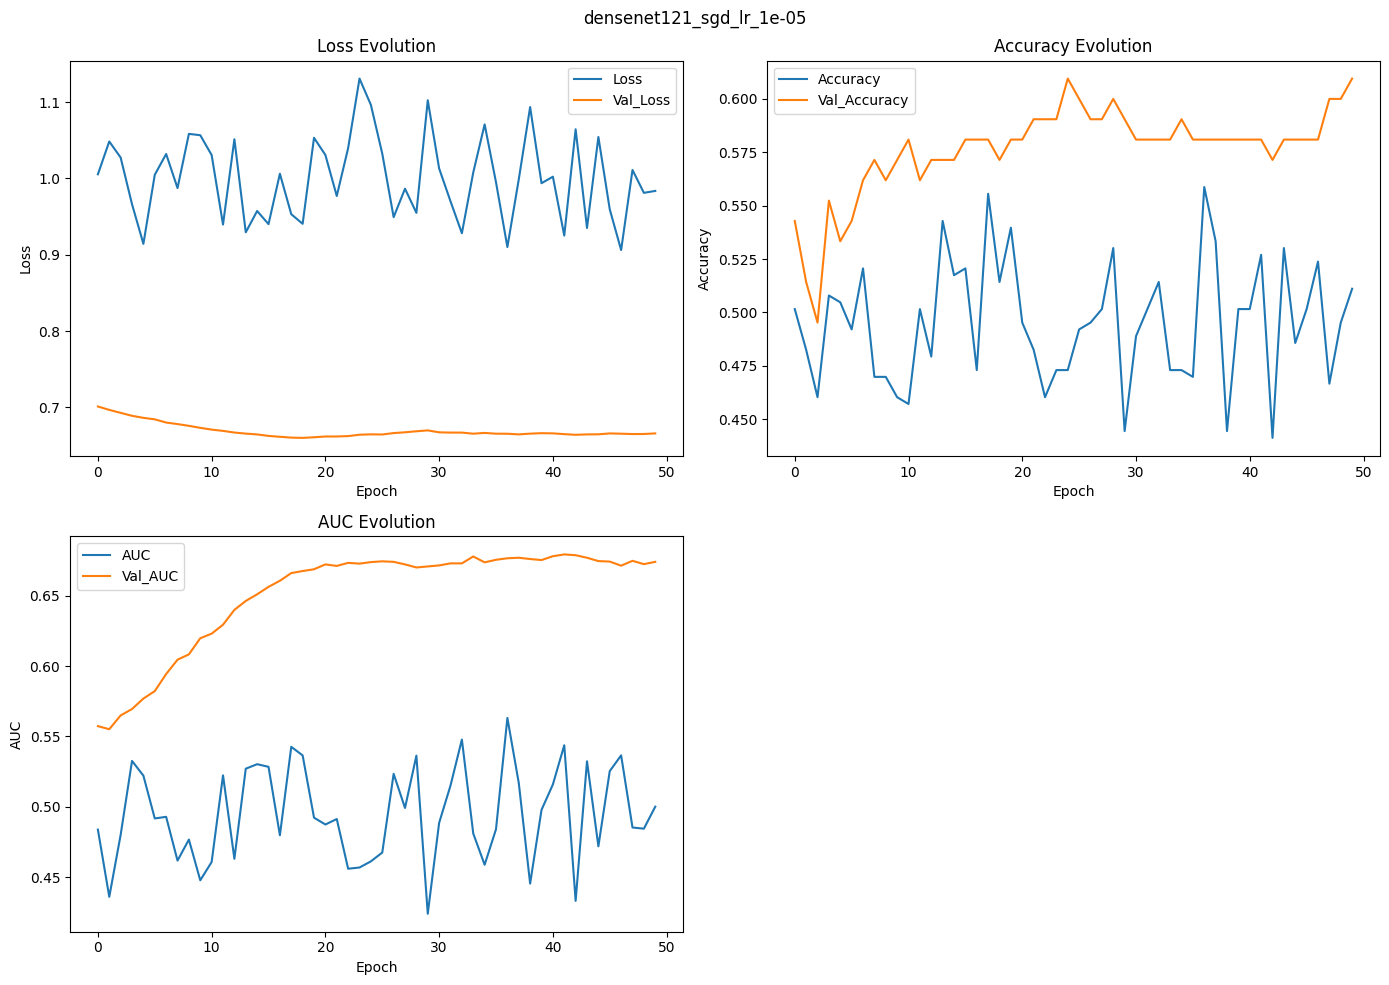

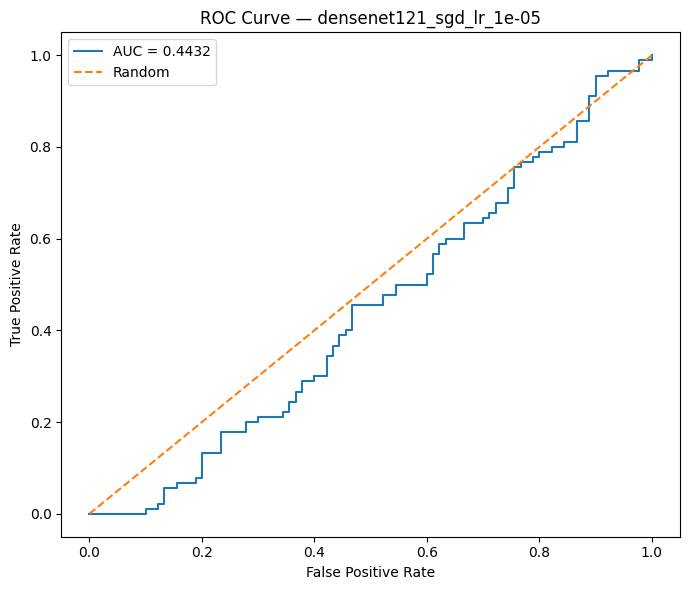

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,69,21
Actual With Disease,77,13


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,sgd,0.00001,0.455556,0.382353,0.144444,0.766667,0.209677,0.44321,69,21,77,13,outputs_densenet121\plots\densenet121_sgd_lr_1...,outputs_densenet121\plots\densenet121_sgd_lr_1...,outputs_densenet121\reports\densenet121_sgd_lr...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.472603,0.766667,0.584746,90.000000
With Disease,0.382353,0.144444,0.209677,90.000000
accuracy,0.455556,0.455556,0.455556,0.455556
macro avg,0.427478,0.455556,0.397212,180.000000
weighted avg,0.427478,0.455556,0.397212,180.000000


Incomplete or missing run, will run: densenet121_sgd_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_sgd_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_sgd_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_sgd_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_sgd_lr_1e-06_confusion_matrix.csv

Running: densenet121_sgd_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.5143 - auc: 0.5190 - loss: 0.9561 - precision: 0.5155 - recall: 0.5253 - val_accuracy: 0.4667 - val_auc: 0.2700 - val_loss: 0.7917 - val_precision: 0.4804 - val_recall: 0.9423
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4698 - auc: 0.5022 - loss: 0.9443 - precision: 0.4702 - recall: 0.4494 - val_accuracy: 0.4381 - val_auc: 0.2583 - val_loss: 0.7892 - val_precision: 0.4639 - val_recall: 0.8654
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4667 - auc: 0.4758 - loss: 0.9828 - p

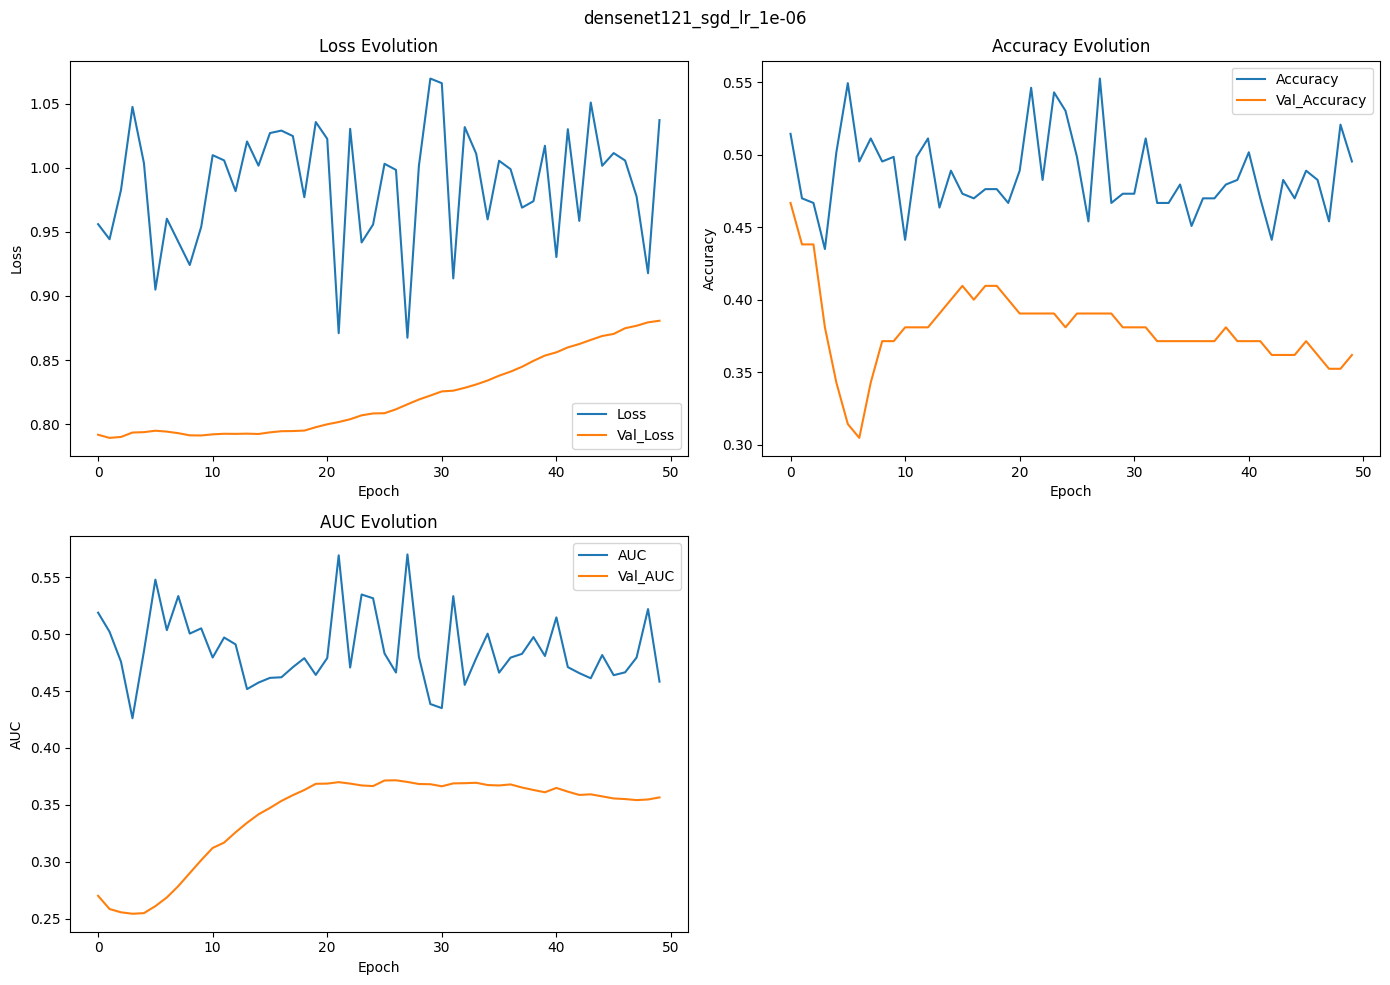

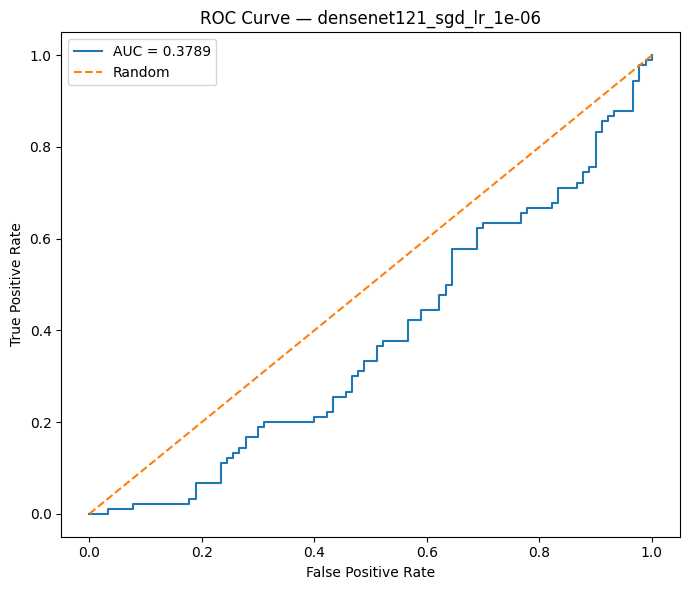

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,30,60
Actual With Disease,38,52


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,sgd,0.000001,0.455556,0.464286,0.577778,0.333333,0.514851,0.378889,30,60,38,52,outputs_densenet121\plots\densenet121_sgd_lr_1...,outputs_densenet121\plots\densenet121_sgd_lr_1...,outputs_densenet121\reports\densenet121_sgd_lr...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.441176,0.333333,0.379747,90.000000
With Disease,0.464286,0.577778,0.514851,90.000000
accuracy,0.455556,0.455556,0.455556,0.455556
macro avg,0.452731,0.455556,0.447299,180.000000
weighted avg,0.452731,0.455556,0.447299,180.000000


Incomplete or missing run, will run: densenet121_rmsprop_lr_0p0001
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_0p0001_history.png
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_0p0001_roc.png
Missing: outputs_densenet121\reports\densenet121_rmsprop_lr_0p0001_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_rmsprop_lr_0p0001_confusion_matrix.csv

Running: densenet121_rmsprop_lr_0p0001
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.5365 - auc: 0.5591 - loss: 0.8467 - precision: 0.5385 - recall: 0.5316 - val_accuracy: 0.4857 - val_auc: 0.3598 - val_loss: 0.7454 - val_precision: 0.4167 - val_recall: 0.0962
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.5238 - auc: 0.5299 - loss: 0.8859 - precision: 0.5233 - recall: 0.5696 - val_accuracy: 0.4667 - val_auc: 0.3877 - val_loss: 0.7311 - val_precision: 0.4091 - val_recall: 0.1731
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5587 - 

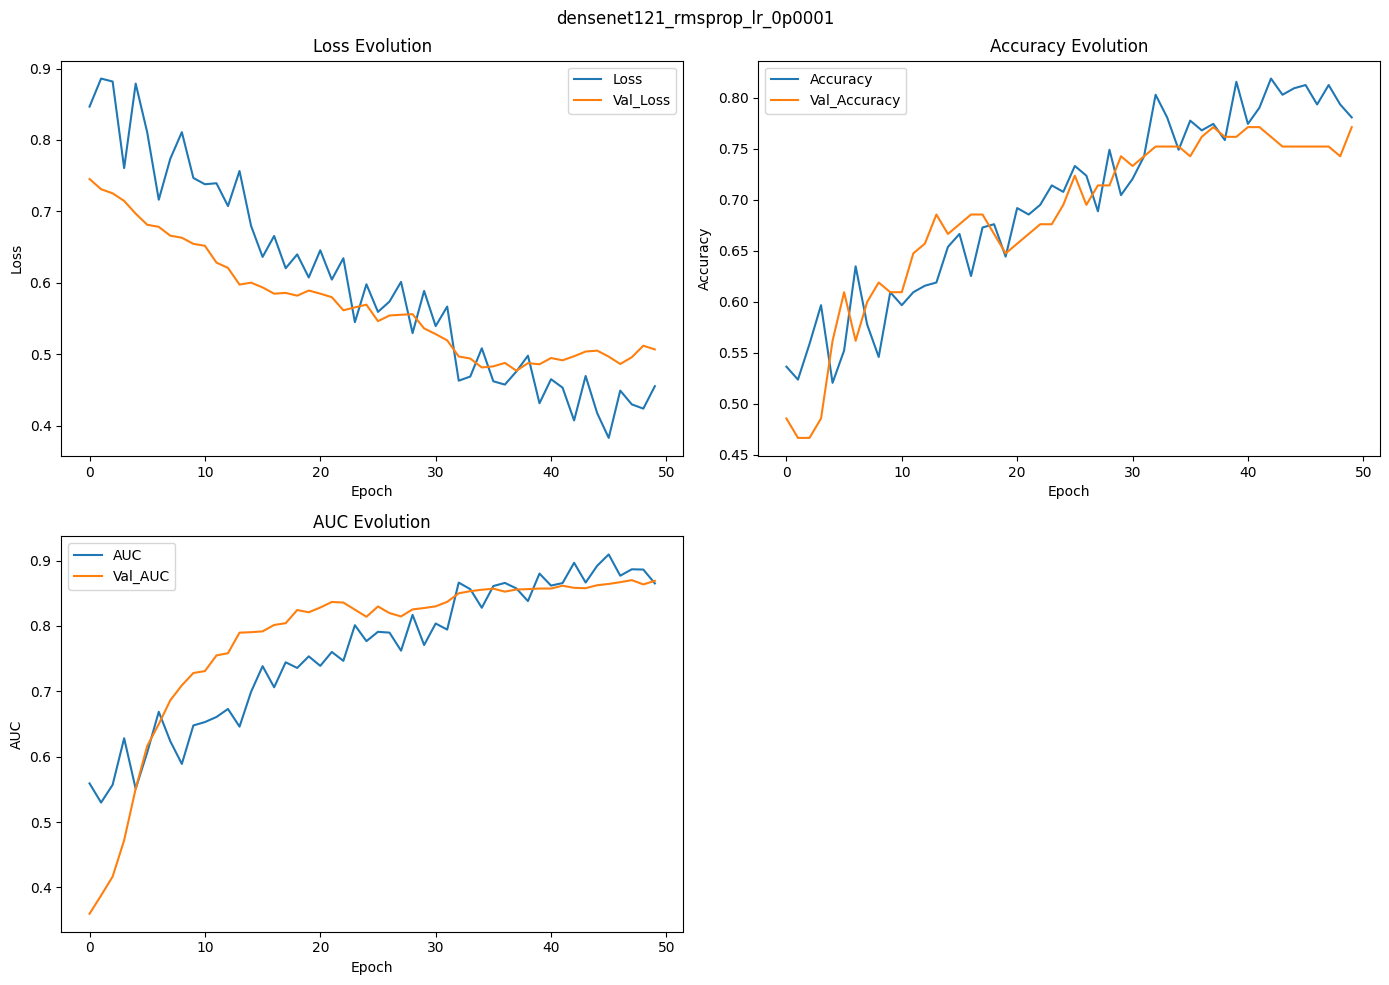

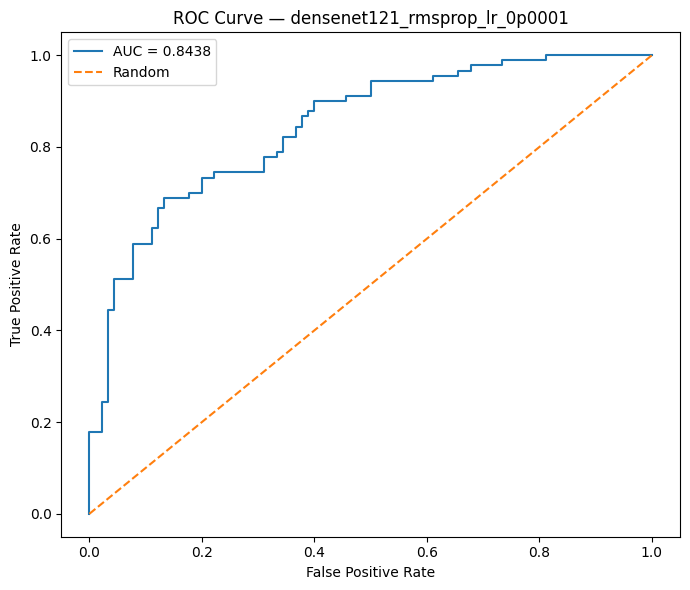

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,79,11
Actual With Disease,34,56


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,rmsprop,0.0001,0.75,0.835821,0.622222,0.877778,0.713376,0.843827,79,11,34,56,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\reports\densenet121_rmspro...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.699115,0.877778,0.778325,90.00
With Disease,0.835821,0.622222,0.713376,90.00
accuracy,0.750000,0.750000,0.750000,0.75
macro avg,0.767468,0.750000,0.745850,180.00
weighted avg,0.767468,0.750000,0.745850,180.00


Incomplete or missing run, will run: densenet121_rmsprop_lr_1e-05
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_1e-05_history.png
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_1e-05_roc.png
Missing: outputs_densenet121\reports\densenet121_rmsprop_lr_1e-05_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_rmsprop_lr_1e-05_confusion_matrix.csv

Running: densenet121_rmsprop_lr_1e-05
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4857 - auc: 0.4923 - loss: 0.9267 - precision: 0.4870 - recall: 0.4747 - val_accuracy: 0.5238 - val_auc: 0.7135 - val_loss: 0.6759 - val_precision: 0.5100 - val_recall: 0.9808
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4857 - auc: 0.4819 - loss: 0.9641 - precision: 0.4877 - recall: 0.5000 - val_accuracy: 0.5143 - val_auc: 0.7273 - val_loss: 0.6775 - val_precision: 0.5050 - val_recall: 0.9808
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.4730 - auc: 0

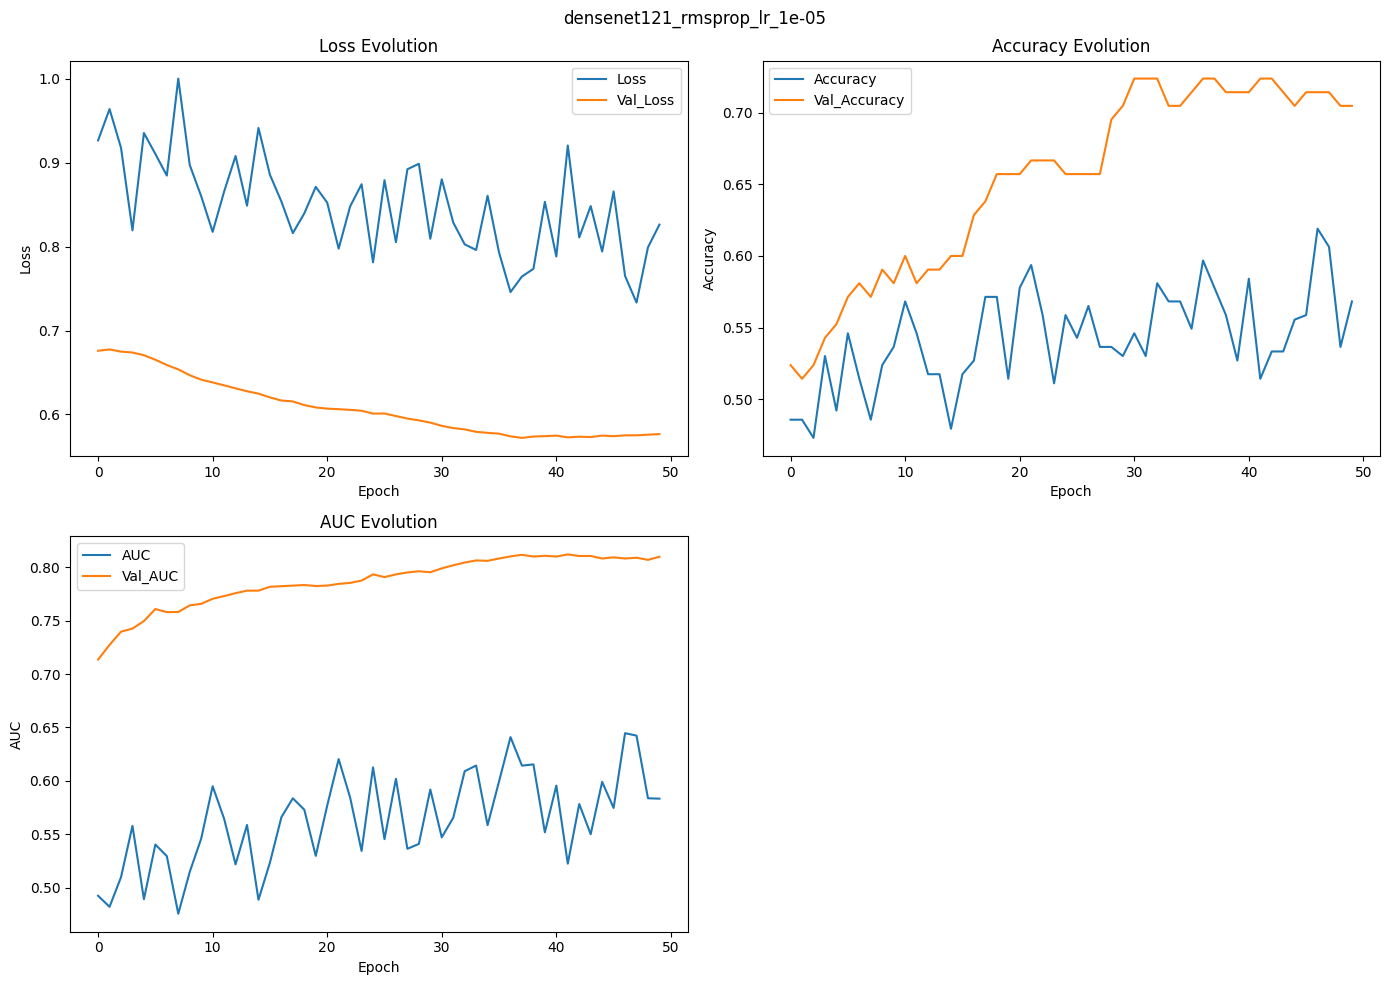

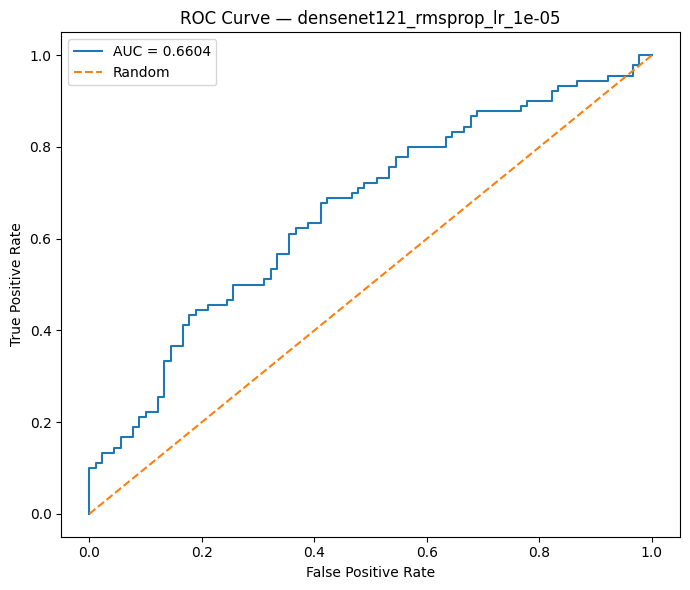

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,60,30
Actual With Disease,42,48


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,rmsprop,0.00001,0.6,0.615385,0.533333,0.666667,0.571429,0.66037,60,30,42,48,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\reports\densenet121_rmspro...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.588235,0.666667,0.625000,90.0
With Disease,0.615385,0.533333,0.571429,90.0
accuracy,0.600000,0.600000,0.600000,0.6
macro avg,0.601810,0.600000,0.598214,180.0
weighted avg,0.601810,0.600000,0.598214,180.0


Incomplete or missing run, will run: densenet121_rmsprop_lr_1e-06
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_1e-06_history.png
Missing: outputs_densenet121\plots\densenet121_rmsprop_lr_1e-06_roc.png
Missing: outputs_densenet121\reports\densenet121_rmsprop_lr_1e-06_classification_report.csv
Missing: outputs_densenet121\confusion_matrices\densenet121_rmsprop_lr_1e-06_confusion_matrix.csv

Running: densenet121_rmsprop_lr_1e-06
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.4730 - auc: 0.4771 - loss: 1.0266 - precision: 0.4744 - recall: 0.4684 - val_accuracy: 0.4952 - val_auc: 0.4135 - val_loss: 0.8167 - val_precision: 0.4952 - val_recall: 1.0000
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5175 - auc: 0.5296 - loss: 0.9081 - precision: 0.5185 - recall: 0.5316 - val_accuracy: 0.5048 - val_auc: 0.4031 - val_loss: 0.7910 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 3s/step - accuracy: 0.5587 - auc: 0

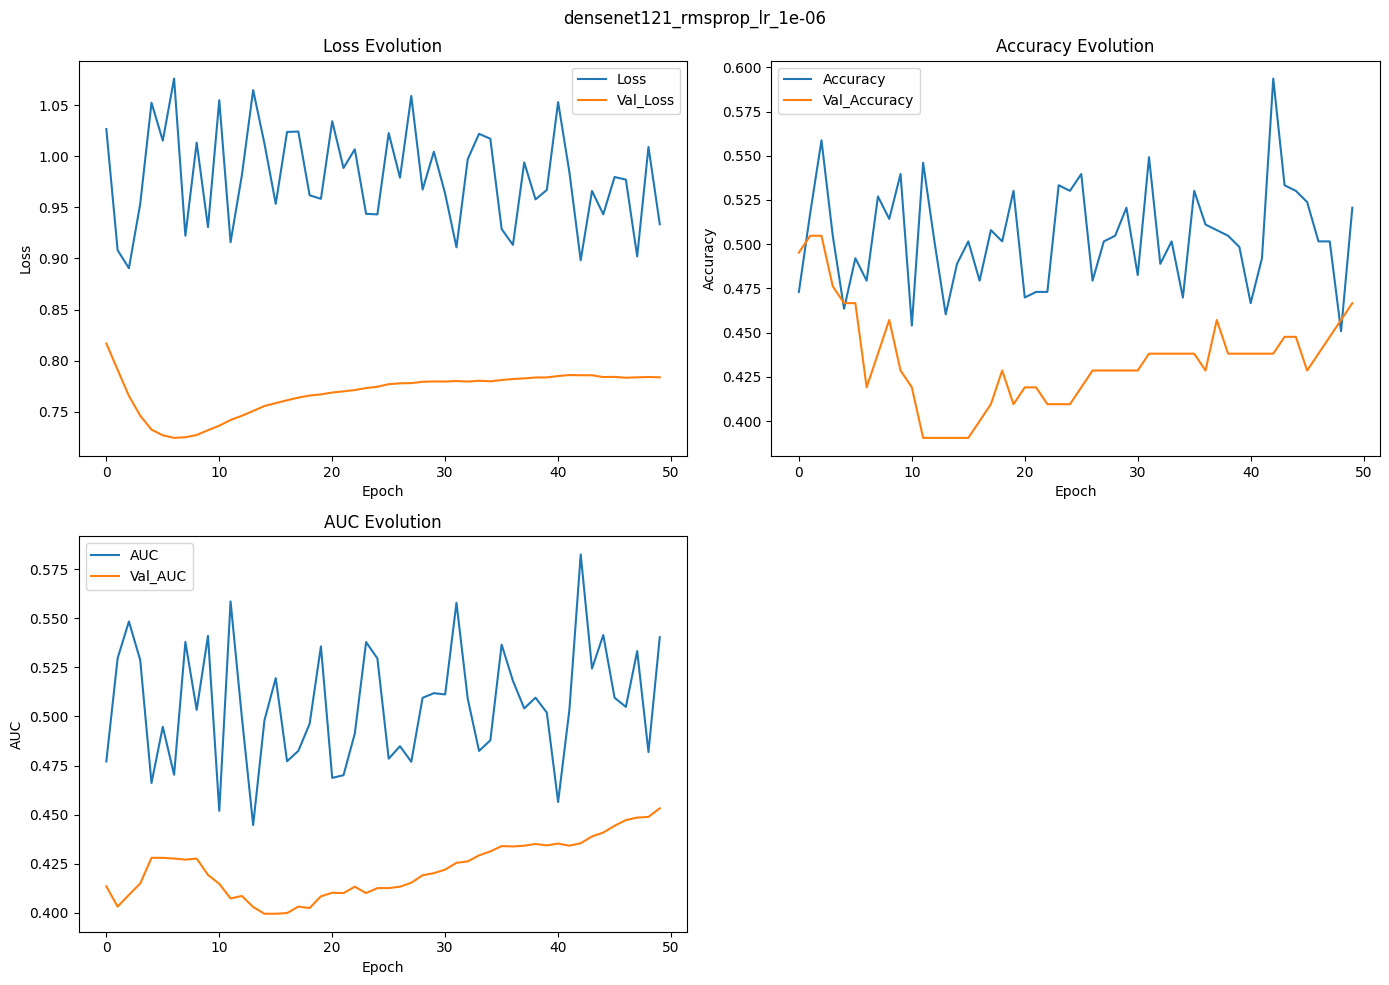

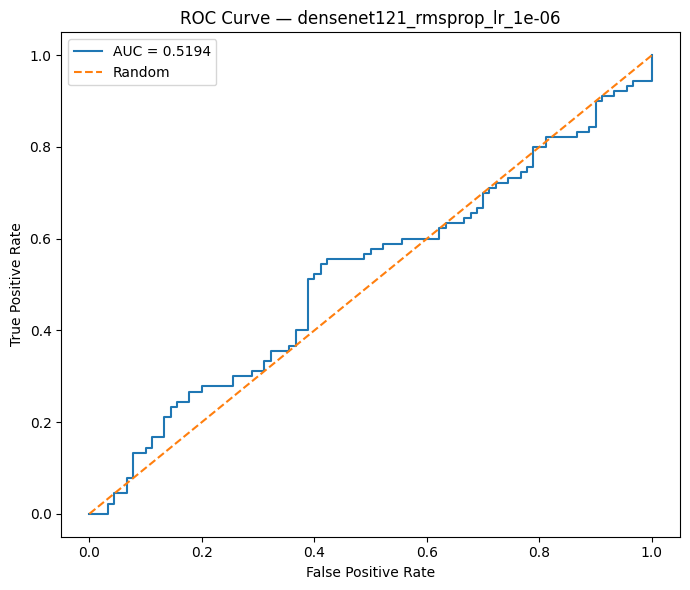

Confusion matrix using With Disease as positive class:


,Predicted Without Disease,Predicted With Disease
Actual Without Disease,33,57
Actual With Disease,33,57


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,rmsprop,0.000001,0.5,0.5,0.633333,0.366667,0.558824,0.519383,33,57,33,57,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\reports\densenet121_rmspro...,outputs_densenet121\confusion_matrices\densene...


,precision,recall,f1-score,support
Without Disease,0.5,0.366667,0.423077,90.0
With Disease,0.5,0.633333,0.558824,90.0
accuracy,0.5,0.500000,0.500000,0.5
macro avg,0.5,0.500000,0.490950,180.0
weighted avg,0.5,0.500000,0.490950,180.0


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,densenet121,adam,0.000100,0.711111,0.702128,0.733333,0.688889,0.717391,0.800123,62,28,24,66,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...
1,densenet121,adam,0.000010,0.572222,0.546763,0.844444,0.300000,0.663755,0.694074,27,63,14,76,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...
2,densenet121,adam,0.000001,0.466667,0.440000,0.244444,0.688889,0.314286,0.503580,62,28,68,22,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\plots\densenet121_adam_lr_...,outputs_densenet121\reports\densenet121_adam_l...,outputs_densenet121\confusion_matrices\densene...
3,densenet121,adagrad,0.000100,0.566667,0.545455,0.800000,0.333333,0.648649,0.572840,30,60,18,72,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...
4,densenet121,adagrad,0.000010,0.438889,0.450450,0.555556,0.322222,0.497512,0.404568,29,61,40,50,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...
5,densenet121,adagrad,0.000001,0.555556,0.535211,0.844444,0.266667,0.655172,0.583580,24,66,14,76,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\plots\densenet121_adagrad_...,outputs_densenet121\reports\densenet121_adagra...,outputs_densenet121\confusion_matrices\densene...
6,densenet121,adamax,0.000100,0.616667,0.714286,0.388889,0.844444,0.503597,0.738148,76,14,55,35,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...
7,densenet121,adamax,0.000010,0.505556,0.504950,0.566667,0.444444,0.534031,0.543704,40,50,39,51,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...
8,densenet121,adamax,0.000001,0.516667,0.533333,0.266667,0.766667,0.355556,0.514938,69,21,66,24,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\plots\densenet121_adamax_l...,outputs_densenet121\reports\densenet121_adamax...,outputs_densenet121\confusion_matrices\densene...
9,densenet121,adadelta,0.000100,0.472222,0.481203,0.711111,0.233333,0.573991,0.454444,21,69,26,64,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\plots\densenet121_adadelta...,outputs_densenet121\reports\densenet121_adadel...,outputs_densenet121\confusion_matrices\densene...


Saved combined new results to: outputs_summaries\all_new_results_summary.csv


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
0,resnet50,adam,0.000100,0.572222,0.559633,0.677778,0.466667,0.613065,0.580864,42,48,29,61,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\plots\resnet50_adam_lr_0p0001...,outputs_resnet50\reports\resnet50_adam_lr_0p00...,outputs_resnet50\confusion_matrices\resnet50_a...
1,resnet50,adam,0.000010,0.505556,0.506494,0.433333,0.577778,0.467066,0.547407,52,38,51,39,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\plots\resnet50_adam_lr_1e-05_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...
2,resnet50,adam,0.000001,0.516667,0.510949,0.777778,0.255556,0.616740,0.465309,23,67,20,70,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\plots\resnet50_adam_lr_1e-06_...,outputs_resnet50\reports\resnet50_adam_lr_1e-0...,outputs_resnet50\confusion_matrices\resnet50_a...
3,resnet50,adagrad,0.000100,0.444444,0.361111,0.144444,0.744444,0.206349,0.453704,67,23,77,13,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\plots\resnet50_adagrad_lr_0p0...,outputs_resnet50\reports\resnet50_adagrad_lr_0...,outputs_resnet50\confusion_matrices\resnet50_a...
4,resnet50,adagrad,0.000010,0.483333,0.483871,0.500000,0.466667,0.491803,0.487160,42,48,45,45,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...
5,resnet50,adagrad,0.000001,0.555556,0.534722,0.855556,0.255556,0.658120,0.623951,23,67,13,77,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\plots\resnet50_adagrad_lr_1e-...,outputs_resnet50\reports\resnet50_adagrad_lr_1...,outputs_resnet50\confusion_matrices\resnet50_a...
6,resnet50,adamax,0.000100,0.500000,0.500000,0.255556,0.744444,0.338235,0.544198,67,23,67,23,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\plots\resnet50_adamax_lr_0p00...,outputs_resnet50\reports\resnet50_adamax_lr_0p...,outputs_resnet50\confusion_matrices\resnet50_a...
7,resnet50,adamax,0.000010,0.550000,0.539823,0.677778,0.422222,0.600985,0.549383,38,52,29,61,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...
8,resnet50,adamax,0.000001,0.533333,0.578947,0.244444,0.822222,0.343750,0.567778,74,16,68,22,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\plots\resnet50_adamax_lr_1e-0...,outputs_resnet50\reports\resnet50_adamax_lr_1e...,outputs_resnet50\confusion_matrices\resnet50_a...
9,resnet50,adadelta,0.000100,0.455556,0.463636,0.566667,0.344444,0.510000,0.413951,31,59,39,51,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\plots\resnet50_adadelta_lr_0p...,outputs_resnet50\reports\resnet50_adadelta_lr_...,outputs_resnet50\confusion_matrices\resnet50_a...


In [11]:
all_results = []

def get_run_name(model_name, optimizer_name, lr):
    return f"{model_name}_{optimizer_name}_lr_{lr:g}".replace(".", "p")


def run_outputs_exist(model_name, optimizer_name, lr):
    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)
    run_name = get_run_name(model_name, optimizer_name, lr)

    expected_files = [
        plots_dir / f"{run_name}_history.png",
        plots_dir / f"{run_name}_roc.png",
        reports_dir / f"{run_name}_classification_report.csv",
        confusion_dir / f"{run_name}_confusion_matrix.csv",
    ]

    missing_files = [file for file in expected_files if not file.exists()]

    if missing_files:
        print(f"Incomplete or missing run, will run: {run_name}")
        for file in missing_files:
            print(f"Missing: {file}")
        return False

    return True


for model_name in MODELS_TO_RUN:
    model_results = []

    output_dir, plots_dir, reports_dir, confusion_dir = get_output_dirs(model_name)

    for optimizer_name in OPTIMIZERS:
        for lr in LEARNING_RATES:
            run_name = get_run_name(model_name, optimizer_name, lr)

            if run_outputs_exist(model_name, optimizer_name, lr):
                print(f"Skipping completed run: {run_name}")
                continue

            result = run_experiment(model_name, optimizer_name, lr)
            model_results.append(result)
            all_results.append(result)

            partial_results_df = pd.DataFrame(model_results)
            partial_results_df.to_csv(
                output_dir / f"{model_name}_partial_results_summary.csv",
                index=False,
            )

    if model_results:
        model_results_df = pd.DataFrame(model_results)
        model_results_df.to_csv(
            output_dir / f"{model_name}_new_results_summary.csv",
            index=False,
        )
        display(model_results_df)

all_results_df = pd.DataFrame(all_results)

if not all_results_df.empty:
    combined_path = SUMMARY_DIR / "all_new_results_summary.csv"
    all_results_df.to_csv(combined_path, index=False)
    print(f"Saved combined new results to: {combined_path}")
    display(all_results_df)
else:
    print("No new runs were performed. All expected output files already exist.")


## Best Run Summary

This summary uses only the runs performed in the current session. If all runs were skipped because output files already exist, no new summary table will be displayed here.


In [12]:
if "all_results_df" in globals() and not all_results_df.empty:
    best_by_auc = all_results_df.sort_values("auc", ascending=False).head(1)
    best_by_accuracy = all_results_df.sort_values("accuracy", ascending=False).head(1)

    print("Best new run by AUC:")
    display(best_by_auc)

    print("Best new run by Accuracy:")
    display(best_by_accuracy)
else:
    print("No new results in this session. Check the model-specific output folders for existing completed runs.")


Best new run by AUC:


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
33,densenet121,rmsprop,0.0001,0.75,0.835821,0.622222,0.877778,0.713376,0.843827,79,11,34,56,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\reports\densenet121_rmspro...,outputs_densenet121\confusion_matrices\densene...


Best new run by Accuracy:


,model,optimizer,learning_rate,accuracy,precision,recall,specificity,f1_score,auc,tn,fp,fn,tp,history_plot,roc_plot,classification_report,confusion_matrix
33,densenet121,rmsprop,0.0001,0.75,0.835821,0.622222,0.877778,0.713376,0.843827,79,11,34,56,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\plots\densenet121_rmsprop_...,outputs_densenet121\reports\densenet121_rmspro...,outputs_densenet121\confusion_matrices\densene...
